## Condition Configuration

Run this notebook after the rephrasing section in `gen_proposals.ipynb`.

- `CONDITION`: condition name whose rephrased proposal files should be analyzed.
- `REUSE_CACHED_PROPOSAL_EMBEDDINGS`: load proposal embeddings if they already exist.
- `REUSE_CACHED_MAIN_IDEA_EMBEDDINGS`: load main-idea embeddings if they already exist.
- `REUSE_CACHED_LITERATURE_EMBEDDINGS`: load literature embeddings if they already exist.


In [101]:
CONDITION = 'minimal'
REUSE_CACHED_PROPOSAL_EMBEDDINGS = True
REUSE_CACHED_MAIN_IDEA_EMBEDDINGS = True
REUSE_CACHED_LITERATURE_EMBEDDINGS = True


# Compare AI vs Human Research Proposals — Style-Controlled (Rephrased)

This notebook mirrors `compare_proposals_baseline.ipynb` but uses proposals rephrased by `gemini-2.0-flash` into a standardized neutral academic style, removing stylistic fingerprints before analysis.

**Data sources:**
- `data/ai-proposals/rephrased/ai_proposals_rephrased_*.csv`
- `data/human-proposals/rephrased/human_proposals_rephrased_y*.json`

All analyses (diversity, novelty, thematic, style baseline) are identical to the baseline notebook.

# Setup and Imports

In [102]:
import sys
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP and embeddings
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from scipy.spatial.distance import cdist
from tqdm import tqdm

# Statistics
from scipy import stats
from scipy.stats import mannwhitneyu
import itertools

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate.resolve()
    raise RuntimeError('Could not find project root containing src/ and data/.')


PROJECT_ROOT = find_project_root()

print('✓ Imports successful')
print(f'✓ Working directory: {os.getcwd()}')
print(f'✓ Project root: {PROJECT_ROOT}')
print(f'✓ PyTorch version: {torch.__version__}')
print(f'✓ CUDA available: {torch.cuda.is_available()}')

# Visualization: 2D Embedding Space with UMAP
try:
    import umap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn'])
    import umap

condition = 'rephrased/minimal'
AI_PROPOSALS_PATH = PROJECT_ROOT / 'data' / 'ai-proposals' / condition
HUMAN_PROPOSALS_PATH = PROJECT_ROOT / 'data' / 'human-proposals' / condition
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures' / condition
TABLES_DIR = RESULTS_DIR / 'tables' / condition
PREPARED_DIR = PROJECT_ROOT / 'data' / 'prepared' / condition
PREPARED_ALL_PROPOSALS_PATH = PREPARED_DIR / 'all_proposals.json'
PREPARED_ALL_PROPOSALS_CSV = PREPARED_DIR / 'all_proposals.csv'
PREPARED_LITERATURE_CORPUS_PATH = PREPARED_DIR / 'literature_corpus_prepared.json'
PROPOSAL_EMBEDDINGS_FILE = PROJECT_ROOT / 'data' / 'embeddings' / condition / 'proposal_embeddings_human_ai_rephrased.pkl'
ABSTRACT_EMBEDDINGS_FILE = PROJECT_ROOT / 'data' / 'embeddings' / condition / 'proposal_embeddings_section1_only.pkl'
MAIN_IDEA_EMBEDDINGS_FILE = PROJECT_ROOT / 'data' / 'embeddings' / condition / 'proposal_embeddings_main_idea_only.pkl'
LITERATURE_EMBEDDINGS_FILE = PROJECT_ROOT / 'data' / 'embeddings' / 'literature' / 'relevant_literature_embeddings.pkl'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PREPARED_DIR.mkdir(parents=True, exist_ok=True)
PROPOSAL_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)
ABSTRACT_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)
LITERATURE_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)
MAIN_IDEA_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)


✓ Imports successful
✓ Working directory: /Users/eveyhuang/Documents/NICO/human-AI-proposal/baseline(minimal)-rephrased
✓ Project root: /Users/eveyhuang/Documents/NICO/human-AI-proposal
✓ PyTorch version: 2.9.1
✓ CUDA available: False


## Helper Functions

In [145]:
# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-5': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#3CB371',  # Dark orange
}

In [104]:
def retrieve_embeddings(path_to_embeddings):
    with open(path_to_embeddings, 'rb') as f:
        embeddings_data = pickle.load(f)
    return embeddings_data

In [105]:
def cliffs_delta(group1, group2):
    """
    Calculate Cliff's Delta effect size.

    Interpretation:
    - |δ| < 0.147: negligible
    - |δ| < 0.33: small
    - |δ| < 0.474: medium
    - |δ| ≥ 0.474: large
    """
    x = np.asarray(group1)
    y = np.asarray(group2)
    n1, n2 = len(x), len(y)

    dominance = 0
    for xi in x:
        dominance += np.sum(xi > y)
        dominance -= np.sum(xi < y)

    return dominance / (n1 * n2)


def interpret_cliffs_delta(delta):
    """Interpret Cliff's Delta magnitude."""
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "negligible"
    if abs_delta < 0.33:
        return "small"
    if abs_delta < 0.474:
        return "medium"
    return "large"


def permutation_test(group1, group2, n_permutations=10000, random_state=42):
    """
    Permutation test for difference in means (group1 - group2).
    Returns p-value, observed difference, and null distribution.
    """
    rng = np.random.default_rng(random_state)

    group1 = np.asarray(group1)
    group2 = np.asarray(group2)
    obs_diff = np.mean(group1) - np.mean(group2)

    combined = np.concatenate([group1, group2])
    n1 = len(group1)

    perm_diffs = np.empty(n_permutations, dtype=float)
    for i in range(n_permutations):
        perm = rng.permutation(combined)
        perm_diffs[i] = np.mean(perm[:n1]) - np.mean(perm[n1:])

    p_value = (np.sum(np.abs(perm_diffs) >= abs(obs_diff)) + 1) / (n_permutations + 1)
    return p_value, obs_diff, perm_diffs


def bootstrap_mean_diff_ci(group1, group2, n_boot=5000, random_state=42, alpha=0.05):
    """Bootstrap CI for mean(group1) - mean(group2)."""
    rng = np.random.default_rng(random_state)
    g1 = np.asarray(group1)
    g2 = np.asarray(group2)

    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        b1 = rng.choice(g1, size=len(g1), replace=True)
        b2 = rng.choice(g2, size=len(g2), replace=True)
        boots[i] = np.mean(b1) - np.mean(b2)

    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return lo, hi, boots


def run_group_comparison(group1, group2, n_permutations=10000, n_boot=5000, random_state=42):
    """Unified comparison with MW, Cliff's delta, permutation p, and bootstrap CI."""
    u_stat, p_value_mw = mannwhitneyu(group1, group2, alternative='two-sided')
    delta = cliffs_delta(group1, group2)
    delta_interp = interpret_cliffs_delta(delta)
    p_value_perm, obs_diff, _ = permutation_test(
        group1, group2, n_permutations=n_permutations, random_state=random_state
    )
    ci_low, ci_high, _ = bootstrap_mean_diff_ci(
        group1, group2, n_boot=n_boot, random_state=random_state
    )

    return {
        'u_stat': u_stat,
        'p_value_mw': p_value_mw,
        'delta': delta,
        'delta_interp': delta_interp,
        'p_value_perm': p_value_perm,
        'obs_diff_mean': obs_diff,
        'obs_diff_median': np.median(group1) - np.median(group2),
        'ci_low': ci_low,
        'ci_high': ci_high,
    }


def apply_multiple_testing(results_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm'):
    """Apply multiple-testing correction to selected p-value columns."""
    from statsmodels.stats.multitest import multipletests

    out = results_df.copy()
    for col in p_cols:
        if col in out.columns:
            _, p_adj, _, _ = multipletests(out[col].values, method=method)
            out[f'{col}_adj_{method}'] = p_adj
    return out


def proposal_mean_pairwise_distances(embeddings):
    """Per-proposal diversity proxy: mean cosine distance to all other proposals in same group."""
    dist_matrix = cosine_distances(embeddings)
    np.fill_diagonal(dist_matrix, np.nan)
    return np.nanmean(dist_matrix, axis=1)


print("✓ Helper functions defined")
print("  - Added proposal-level pairwise diversity metric (mean distance-to-others)")
print("  - Added bootstrap 95% CI for mean differences")
print("  - Added Holm multiple-testing adjustment helper")


✓ Helper functions defined
  - Added proposal-level pairwise diversity metric (mean distance-to-others)
  - Added bootstrap 95% CI for mean differences
  - Added Holm multiple-testing adjustment helper


In [106]:

# --- Added helper utilities for proposal diversity/novelty patch ---
def build_group_indices(proposal_meta):
    groups = {}
    groups['Human'] = proposal_meta.index[proposal_meta['group_binary'] == 'Human'].to_numpy()
    model_names = sorted(proposal_meta.loc[proposal_meta['group_binary']=='AI', 'group_model'].dropna().unique().tolist())
    for m in model_names:
        groups[m] = proposal_meta.index[proposal_meta['group_model'] == m].to_numpy()
    groups['All AI'] = proposal_meta.index[proposal_meta['group_binary'] == 'AI'].to_numpy()
    return groups


def get_group_submatrix(D, idx):
    return D[np.ix_(idx, idx)]


def sort_distance_rows(D):
    idx = np.argsort(D, axis=1)
    dist = np.take_along_axis(D, idx, axis=1)
    return dist, idx


def safe_percentile(arr, q):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    return float(np.percentile(arr, q))


def proposal_mean_pairwise_from_submatrix(Dg):
    Dg = np.asarray(Dg, dtype=float).copy()
    np.fill_diagonal(Dg, np.nan)
    return np.nanmean(Dg, axis=1)


def proposal_min_pairwise_from_submatrix(Dg):
    Dg = np.asarray(Dg, dtype=float).copy()
    np.fill_diagonal(Dg, np.inf)
    return np.min(Dg, axis=1)


def proposal_mean_knn_from_submatrix(Dg, k=5):
    Dg = np.asarray(Dg, dtype=float).copy()
    np.fill_diagonal(Dg, np.inf)
    k_eff = max(1, min(k, Dg.shape[1]-1))
    part = np.partition(Dg, kth=k_eff-1, axis=1)[:, :k_eff]
    return np.mean(part, axis=1)


def proposal_centroid_distances(Xg, leave_one_out=False):
    Xg = np.asarray(Xg, dtype=float)
    if len(Xg) == 0:
        return np.array([])
    if not leave_one_out:
        c = Xg.mean(axis=0, keepdims=True)
        return cosine_distances(Xg, c).ravel()
    n = Xg.shape[0]
    if n <= 1:
        return np.zeros(n)
    d = np.zeros(n, dtype=float)
    sum_x = Xg.sum(axis=0)
    for i in range(n):
        c_loo = ((sum_x - Xg[i]) / (n - 1)).reshape(1, -1)
        d[i] = cosine_distances(Xg[i].reshape(1, -1), c_loo)[0, 0]
    return d


def proposal_global_centroid_distances(X_all, idx_group):
    X_all = np.asarray(X_all, dtype=float)
    c = X_all.mean(axis=0, keepdims=True)
    return cosine_distances(X_all[idx_group], c).ravel()


def proposal_medoid_distances(Dg):
    medoid_idx = group_medoid_index(Dg)
    return np.asarray(Dg)[:, medoid_idx]


def group_remote_clique(Dg):
    Dg = np.asarray(Dg, dtype=float)
    return float(Dg.mean())


def group_chamfer(Dg):
    Dg = np.asarray(Dg, dtype=float).copy()
    np.fill_diagonal(Dg, np.inf)
    return float(np.min(Dg, axis=1).mean())


def group_mst_dispersion(Dg):
    from scipy.sparse.csgraph import minimum_spanning_tree
    Dg = np.asarray(Dg, dtype=float)
    if Dg.shape[0] <= 1:
        return 0.0
    mst = minimum_spanning_tree(Dg)
    return float(mst.sum() / max(1, Dg.shape[0]-1))


def group_span_percentile(Xg, q=90):
    d = proposal_centroid_distances(Xg, leave_one_out=False)
    return safe_percentile(d, q)


def group_medoid_index(Dg):
    Dg = np.asarray(Dg, dtype=float)
    return int(np.argmin(Dg.sum(axis=0)))


def group_sparseness(Dg):
    medoid_idx = group_medoid_index(Dg)
    return float(np.asarray(Dg, dtype=float)[:, medoid_idx].mean())


def group_grid_entropy(coords_2d, idx_group, bins=5, normalize=True):
    pts = np.asarray(coords_2d)[idx_group]
    if len(pts) == 0:
        return np.nan
    H, _, _ = np.histogram2d(pts[:,0], pts[:,1], bins=bins)
    p = H.ravel().astype(float)
    if p.sum() == 0:
        return 0.0
    p = p / p.sum()
    p = p[p > 0]
    ent = -np.sum(p * np.log(p))
    if normalize:
        max_ent = np.log(bins * bins)
        return float(ent / max_ent) if max_ent > 0 else 0.0
    return float(ent)


def compute_element_novel_percentiles(D_pl, q_list=[0,1,5,10]):
    out = {}
    out['element_novel_0'] = np.min(D_pl, axis=1)
    for q in q_list:
        if q == 0:
            continue
        out[f'element_novel_{q}'] = np.percentile(D_pl, q, axis=1)
    return out


def compute_mean_knn_novelty(D_pl_sorted_dist, ks=[5,10,20,50]):
    out = {}
    n_lit = D_pl_sorted_dist.shape[1]
    for k in ks:
        k_eff = min(k, n_lit)
        out[f'mean_knn_{k}'] = D_pl_sorted_dist[:, :k_eff].mean(axis=1)
    return out


def compute_local_density_normalized_novelty(mean_knn_10, proposal_top10_lit_idx, lit_mean_knn_10):
    lit_local = lit_mean_knn_10[proposal_top10_lit_idx].mean(axis=1)
    novelty_ratio = mean_knn_10 / np.where(lit_local == 0, np.nan, lit_local)
    novelty_z = (mean_knn_10 - lit_local) / np.where(np.nanstd(lit_local) == 0, np.nan, np.nanstd(lit_local))
    return novelty_ratio, novelty_z, lit_local


def bootstrap_group_metric(X_or_D, metric_fn, n_boot=5000, random_state=42, metric_type='distance'):
    rng = np.random.default_rng(random_state)
    X_or_D = np.asarray(X_or_D)
    n = X_or_D.shape[0]
    vals = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if metric_type == 'distance':
            sample = X_or_D[np.ix_(idx, idx)]
        else:
            sample = X_or_D[idx]
        vals[b] = metric_fn(sample)
    return {
        'boot_mean': float(np.mean(vals)),
        'ci_low': float(np.percentile(vals, 2.5)),
        'ci_high': float(np.percentile(vals, 97.5)),
        'boot_values': vals,
    }


def permutation_test_group_metric(X_prop, labels, idx_a, idx_b, metric_fn, n_perm=10000, random_state=42, use_distance_submat=False):
    rng = np.random.default_rng(random_state)
    X_prop = np.asarray(X_prop)
    idx_a = np.asarray(idx_a)
    idx_b = np.asarray(idx_b)
    idx = np.concatenate([idx_a, idx_b])
    n_a = len(idx_a)
    if use_distance_submat:
        D = X_prop
        obs = metric_fn(D[np.ix_(idx_a, idx_a)]) - metric_fn(D[np.ix_(idx_b, idx_b)])
    else:
        obs = metric_fn(X_prop[idx_a]) - metric_fn(X_prop[idx_b])
    perm = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        shuf = rng.permutation(idx)
        a = shuf[:n_a]
        b = shuf[n_a:]
        if use_distance_submat:
            perm[i] = metric_fn(D[np.ix_(a, a)]) - metric_fn(D[np.ix_(b, b)])
        else:
            perm[i] = metric_fn(X_prop[a]) - metric_fn(X_prop[b])
    p = (np.sum(np.abs(perm) >= abs(obs)) + 1) / (n_perm + 1)
    return {'obs_diff': float(obs), 'perm_p_value': float(p)}


def flag_top_percentile(values, pct=90, strict=True):
    values = np.asarray(values, dtype=float)
    thr = np.percentile(values[np.isfinite(values)], pct)
    if strict:
        return values > thr, float(thr)
    return values >= thr, float(thr)


def fisher_group_prevalence_tests(flag_series, group_series, reference_group='Human'):
    from scipy.stats import fisher_exact
    rows = []
    flags = np.asarray(flag_series).astype(bool)
    groups = np.asarray(group_series).astype(str)
    ref_mask = groups == reference_group
    ref_pos = int(flags[ref_mask].sum())
    ref_neg = int(ref_mask.sum() - ref_pos)
    for g in sorted(set(groups)):
        if g == reference_group:
            continue
        m = groups == g
        pos = int(flags[m].sum())
        neg = int(m.sum() - pos)
        table = np.array([[pos, neg], [ref_pos, ref_neg]])
        try:
            odds, p = fisher_exact(table)
        except Exception:
            odds, p = np.nan, np.nan
        rows.append({
            'group': g,
            'reference_group': reference_group,
            'n_group': int(m.sum()),
            'n_reference': int(ref_mask.sum()),
            'flag_rate_group': pos / max(1, int(m.sum())),
            'flag_rate_reference': ref_pos / max(1, int(ref_mask.sum())),
            'odds_ratio': odds,
            'p_value': p,
            'count_group_flag': pos,
            'count_ref_flag': ref_pos,
        })
    return pd.DataFrame(rows)


## Load Prepared Proposal Data

Run `prepare_data_for_analysis.ipynb` first when raw proposal files change. This notebook expects the prepared proposal artifact and full-proposal embeddings produced there.

In [107]:
# Load prepared proposal records and expose the same ai_df/human_df variables used below.
prepared_path = PREPARED_ALL_PROPOSALS_PATH if PREPARED_ALL_PROPOSALS_PATH.exists() else TABLES_DIR / 'all_proposals.json'
if not prepared_path.exists():
    raise FileNotFoundError(
        f'Prepared proposals not found at {prepared_path}. Run prepare_data_for_analysis.ipynb first.'
    )

with open(prepared_path) as f:
    prepared_proposals = json.load(f)

ai_rows = []
human_rows = []
for rec in prepared_proposals:
    rephrased = rec.get('rephrased', {}) or {}
    row = {
        'title': rec.get('title'),
        'proposal_title': rec.get('title'),
        'model': rec.get('model'),
        'cohort': rec.get('cohort'),
        'source_file': rec.get('source_file'),
        'standardized_text': rephrased.get('standardized_text', ''),
        'abstract_text': rephrased.get('abstract_text', ''),
        'main_idea': rephrased.get('main_idea', ''),
        'group': 'AI' if rec.get('is_ai') else 'Human',
    }
    if rec.get('is_ai'):
        ai_rows.append(row)
    else:
        human_rows.append(row)

ai_df = pd.DataFrame(ai_rows)
human_df = pd.DataFrame(human_rows)

print(f'Loaded prepared proposals from: {prepared_path}')
print(f'  AI proposals: {len(ai_df)}')
print(f'  Human proposals: {len(human_df)}')
print(f"  AI models: {ai_df['model'].value_counts().to_dict()}")

Loaded prepared proposals from: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/all_proposals.json
  AI proposals: 69
  Human proposals: 23
  AI models: {'gpt-5.2': 23, 'gemini-3-pro-preview': 23, 'claude-opus-4-5': 23}


## Load Prepared NCEMS Reviews

Load human + AI NCEMS review data (`ncems_criteria_all_reviews.csv`) and aggregate proposal-level ranking/funding fields for embedding-space visualizations.

In [108]:

# Load prepared NCEMS all-reviews table (human + AI)
NCEMS_ALL_REVIEWS_PATH = PROJECT_ROOT / 'data' / 'prepared' / condition / 'ncems_criteria_all_reviews.csv'
if not NCEMS_ALL_REVIEWS_PATH.exists():
    raise FileNotFoundError(f'NCEMS all-reviews CSV not found: {NCEMS_ALL_REVIEWS_PATH}')

ncems_all_reviews_df = pd.read_csv(NCEMS_ALL_REVIEWS_PATH)

# Harmonize key fields for robust proposal-level merge
ncems_all_reviews_df['title_norm'] = (
    ncems_all_reviews_df['title'].astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9 ]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
author = ncems_all_reviews_df['author'].astype(str).str.lower()
ncems_all_reviews_df['group_binary'] = np.where(author.str.startswith('human'), 'Human', 'AI')
ncems_all_reviews_df['group_model'] = np.where(ncems_all_reviews_df['group_binary'] == 'Human', 'Human', ncems_all_reviews_df['author'])

for c in ['ranking', 'ranking_AI_reviews', 'funding']:
    if c in ncems_all_reviews_df.columns:
        ncems_all_reviews_df[c] = pd.to_numeric(ncems_all_reviews_df[c], errors='coerce')

def _first_nonnull(series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

review_rankings_df = (
    ncems_all_reviews_df
    .groupby(['title_norm', 'group_binary', 'group_model'], as_index=False)
    .agg({
        'ranking': _first_nonnull,
        'ranking_AI_reviews': _first_nonnull,
        'funding': _first_nonnull,
        'proposal_uid': _first_nonnull,
        'cohort': _first_nonnull,
    })
)

print(f'Loaded NCEMS reviews: {NCEMS_ALL_REVIEWS_PATH}')
print(f'  rows: {len(ncems_all_reviews_df):,}')
print(f'  unique proposals in reviews: {ncems_all_reviews_df["proposal_uid"].nunique():,}')
print(f'  proposal-level aggregated rows: {len(review_rankings_df):,}')


Loaded NCEMS reviews: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/ncems_criteria_all_reviews.csv
  rows: 361
  unique proposals in reviews: 92
  proposal-level aggregated rows: 95


## Prepare Proposal Texts

Combine all sections of proposals into full text for embedding.

In [109]:
import re

# Section headers produced by rephrase_proposals.py template
_SECTION_HEADERS = [
    "SCIENTIFIC BACKGROUND AND RESEARCH QUESTION",
    "METHODOLOGY AND ANALYTICAL APPROACH",
    "DATA SOURCES AND SYNTHESIS PLAN",
    "FEASIBILITY AND TIMELINE",
    "OPEN SCIENCE AND TEAM COMPOSITION",
]

def strip_section_headers(text: str) -> str:
    """Remove section heading lines, keeping only prose content."""
    for header in _SECTION_HEADERS:
        text = re.sub(rf'^\s*{re.escape(header)}\s*$', '', text, flags=re.MULTILINE | re.IGNORECASE)
    return re.sub(r'\n{3,}', '\n\n', text).strip()

# Both AI and human proposals now share a unified "standardized_text" field
# produced by rephrase_proposals.py — strip section headers to keep only prose.
ai_df["full_text"] = ai_df["standardized_text"].fillna("").astype(str).apply(strip_section_headers)
human_df["full_text"] = human_df["standardized_text"].fillna("").astype(str).apply(strip_section_headers)

# Add group labels
ai_df["group"] = "AI"
human_df["group"] = "Human"

print(f"✓ Using standardized_text (headers stripped) as full_text for all proposals")
print(f"  AI avg length: {ai_df['full_text'].str.len().mean():.0f} characters")
print(f"  Human avg length: {human_df['full_text'].str.len().mean():.0f} characters")

✓ Using standardized_text (headers stripped) as full_text for all proposals
  AI avg length: 1807 characters
  Human avg length: 1803 characters


## Load Prepared Full-Proposal Embeddings

Full rephrased proposal embeddings are prepared in `prepare_data_for_analysis.ipynb`. This notebook only computes them as a fallback when the cache is missing or stale.

In [110]:
# Embedding model is loaded lazily only if a required cache is missing.
model_name = 'michiyasunaga/BioLinkBERT-large'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = None
embedding_model = None


def ensure_embedding_model_loaded():
    global tokenizer, embedding_model
    if tokenizer is not None and embedding_model is not None:
        return tokenizer, embedding_model
    print(f'Loading BioLinkBERT model: {model_name}')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    embedding_model = AutoModel.from_pretrained(model_name).to(device)
    embedding_model.eval()
    print(f'Model loaded on: {device}')
    return tokenizer, embedding_model

In [111]:
def get_embeddings(texts, batch_size=8):
    """Generate BioLinkBERT [CLS] embeddings for texts."""
    ensure_embedding_model_loaded()
    all_embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc='Embedding texts'):
            batch = ['' if pd.isna(t) else str(t) for t in texts[i:i + batch_size]]
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt',
            ).to(device)
            outputs = embedding_model(**encoded)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

print('Embedding function ready; model will load only if a cache must be generated.')

Embedding function ready; model will load only if a cache must be generated.


In [112]:
# Load full rephrased proposal embeddings (or generate a fallback cache).
embeddings_file = PROPOSAL_EMBEDDINGS_FILE
rephrased_embeddings_were_generated = False

if embeddings_file.exists():
    print(f'Loading prepared full-proposal embeddings from: {embeddings_file}')
    embeddings_data = retrieve_embeddings(str(embeddings_file))
    ai_embeddings = np.asarray(embeddings_data['ai_embeddings'])
    human_embeddings = np.asarray(embeddings_data['human_embeddings'])
    ai_metadata = embeddings_data.get('ai_metadata', ai_df[['model', 'title', 'group']].to_dict('records'))
    human_metadata = embeddings_data.get('human_metadata', human_df[['proposal_title', 'group', 'source_file']].to_dict('records'))
else:
    print('No prepared full-proposal embedding cache found - generating fallback now.')
    ai_embeddings = get_embeddings(ai_df['full_text'].tolist())
    human_embeddings = get_embeddings(human_df['full_text'].tolist())
    ai_metadata = ai_df[['model', 'title', 'group']].to_dict('records')
    human_metadata = human_df[['proposal_title', 'group', 'source_file']].to_dict('records')
    embeddings_data = {
        'ai_embeddings': ai_embeddings,
        'human_embeddings': human_embeddings,
        'ai_metadata': ai_metadata,
        'human_metadata': human_metadata,
        'model_name': model_name,
        'text_field': 'rephrased_full_text',
        'timestamp': datetime.now().isoformat(),
    }
    with open(embeddings_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    rephrased_embeddings_were_generated = True
    print(f'Saved fallback embeddings to: {embeddings_file}')

print(f'  AI embeddings: {ai_embeddings.shape}')
print(f'  Human embeddings: {human_embeddings.shape}')

Loading prepared full-proposal embeddings from: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/rephrased/minimal/proposal_embeddings_human_ai_rephrased.pkl
  AI embeddings: (69, 1024)
  Human embeddings: (23, 1024)


In [113]:
# Save: proposal metadata (title + group)
import pandas as pd; from pathlib import Path
out_dir = TABLES_DIR; out_dir.mkdir(parents=True, exist_ok=True)
rows = ([{'title': r.get('proposal_title', r.get('title','')), 'group': 'Human'} for r in human_metadata]
      + [{'title': r.get('title', r.get('proposal_title','')), 'group': r.get('model','AI')} for r in ai_metadata])
pd.DataFrame(rows).to_csv(out_dir/'proposal_metadata.csv', index=False)
print(f"Saved proposal_metadata.csv  ({len(rows)} rows)")


Saved proposal_metadata.csv  (92 rows)


## Shared Distance-Matrix Precomputation

This block computes and caches the reusable proposal-space and literature-space distance objects used throughout Part I and Part II. All later sections should reuse these objects rather than recomputing distances.

In [114]:

# Canonical proposal metadata in embedding order
human_titles = [str(r.get('proposal_title', r.get('title', ''))) for r in human_metadata]
ai_titles = [str(r.get('title', r.get('proposal_title', ''))) for r in ai_metadata]
ai_models_ordered = [str(r.get('model', 'AI')) for r in ai_metadata]

proposal_meta = pd.DataFrame({
    'title': human_titles + ai_titles,
    'group_model': ['Human'] * len(human_titles) + ai_models_ordered,
    'group_binary': ['Human'] * len(human_titles) + ['AI'] * len(ai_titles),
    'is_ai': [False] * len(human_titles) + [True] * len(ai_titles),
    'source_file': [r.get('source_file', None) for r in human_metadata] + [r.get('source_file', None) for r in ai_metadata],
})
proposal_meta['proposal_uid'] = [f'P_{i:03d}' for i in range(len(proposal_meta))]
proposal_meta['title_norm'] = (
    proposal_meta['title'].astype(str).str.strip().str.lower()
    .str.replace(r'[^a-z0-9 ]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Merge proposal-level review ranking/funding fields
if 'review_rankings_df' in globals():
    proposal_meta = proposal_meta.merge(
        review_rankings_df[['title_norm', 'group_binary', 'group_model', 'ranking', 'ranking_AI_reviews', 'funding']].copy(),
        on=['title_norm', 'group_binary', 'group_model'],
        how='left',
    )
else:
    proposal_meta['ranking'] = np.nan
    proposal_meta['ranking_AI_reviews'] = np.nan
    proposal_meta['funding'] = np.nan

# Unified rank field: Human uses ranking, AI uses ranking_AI_reviews
proposal_meta['viz_rank'] = np.where(
    proposal_meta['group_binary'].eq('Human'),
    proposal_meta['ranking'],
    proposal_meta['ranking_AI_reviews'],
)
proposal_meta['viz_rank'] = pd.to_numeric(proposal_meta['viz_rank'], errors='coerce')

# Discard size variance: use constant marker size for all proposals.
# Highlight top-ranked proposals via black outline instead.
MARKER_SIZE_CONST = 145.0
proposal_meta['viz_marker_size'] = MARKER_SIZE_CONST
proposal_meta['is_top5_ranked'] = False
for _grp in proposal_meta['group_model'].unique():
    _mask = proposal_meta['group_model'] == _grp
    _ranks = proposal_meta.loc[_mask, 'viz_rank']
    if _ranks.notna().any():
        _top5_idx = _ranks.dropna().nsmallest(5).index
        proposal_meta.loc[_top5_idx, 'is_top5_ranked'] = True

# Human color shading by funding status
proposal_meta['human_color_shade'] = np.where(
    proposal_meta['funding'].fillna(0).astype(float).eq(1.0),
    '#8B0000',  # dark red for funded
    '#F08080',  # lighter coral for non-funded/unknown
)

# X_prop in exact row order of proposal_meta
X_prop = np.vstack([human_embeddings, ai_embeddings]).astype(np.float32)

# L2 normalize once
X_prop = X_prop / np.clip(np.linalg.norm(X_prop, axis=1, keepdims=True), 1e-12, None)

GROUPS = build_group_indices(proposal_meta)
ai_models = sorted(proposal_meta.loc[proposal_meta['group_binary'] == 'AI', 'group_model'].unique().tolist())

# proposal-proposal cosine distance
S_pp = X_prop @ X_prop.T
D_pp = 1.0 - S_pp
np.fill_diagonal(D_pp, 0.0)

D_pp_infdiag = D_pp.copy()
np.fill_diagonal(D_pp_infdiag, np.inf)

# deterministic 2D reference
from sklearn.decomposition import PCA
pca_2d = PCA(n_components=2, random_state=42).fit_transform(X_prop)

group_cache = {}
for g, idx in GROUPS.items():
    Dg = D_pp[np.ix_(idx, idx)]
    Xg = X_prop[idx]
    group_cache[g] = {'idx': idx, 'D': Dg, 'X': Xg, 'n': len(idx)}

cache_dir = TABLES_DIR / 'cached'
cache_dir.mkdir(parents=True, exist_ok=True)
np.save(cache_dir / 'proposal_distance_matrix.npy', D_pp)
np.save(cache_dir / 'proposal_pca2d.npy', pca_2d)
proposal_meta.to_csv(cache_dir / 'proposal_meta.csv', index=False)

review_cov = proposal_meta['viz_rank'].notna().mean() * 100
top5_cov = proposal_meta['is_top5_ranked'].mean() * 100
fund_cov = proposal_meta.loc[proposal_meta['group_binary']=='Human', 'funding'].notna().mean() * 100
print('Saved shared proposal caches to:', cache_dir)
print('X_prop shape:', X_prop.shape)
print('D_pp shape:', D_pp.shape)
print('Groups:', {k: len(v) for k, v in GROUPS.items()})
print(f'Review ranking coverage (all proposals): {review_cov:.1f}%')
print(f'Top-5 outlined proposals: {top5_cov:.1f}% of all proposals')
print(f'Human funding coverage: {fund_cov:.1f}%')


Saved shared proposal caches to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/cached
X_prop shape: (92, 1024)
D_pp shape: (92, 92)
Groups: {'Human': 23, 'claude-opus-4-5': 23, 'gemini-3-pro-preview': 23, 'gpt-5.2': 23, 'All AI': 69}
Review ranking coverage (all proposals): 96.7%
Top-5 outlined proposals: 21.7% of all proposals
Human funding coverage: 87.0%


# PART I: DIVERSITY

## Analysis 1.1: Within-Group Pairwise Diversity (Remote-Clique + proposal-level mean pairwise distance)

This section reports exact group-level Remote-Clique and proposal-level mean pairwise distance for inferential tests.

In [115]:

print('='*85)
print('ANALYSIS 1.1: WITHIN-GROUP PAIRWISE DIVERSITY')
print('='*85)

summary_rows = []
proposal_rows = []

# Backward-compatible containers used by existing plotting cells
human_idx = GROUPS['Human']
ai_idx = GROUPS['All AI']
human_pairwise = D_pp[np.ix_(human_idx, human_idx)][np.triu_indices(len(human_idx), k=1)]
ai_pairwise = D_pp[np.ix_(ai_idx, ai_idx)][np.triu_indices(len(ai_idx), k=1)]
model_pairwise = {}
model_embeddings_dict = {}

for g, gc in group_cache.items():
    idx = gc['idx']
    Dg = gc['D']
    n = gc['n']
    tri = Dg[np.triu_indices(n, k=1)] if n > 1 else np.array([])
    mpd = proposal_mean_pairwise_from_submatrix(Dg) if n > 1 else np.zeros(n)
    remote = group_remote_clique(Dg)

    if g in ai_models:
        model_pairwise[g] = tri
        model_embeddings_dict[g] = X_prop[idx]

    summary_rows.append({
        'group': g,
        'n': n,
        'remote_clique': remote,
        'upper_tri_mean': float(np.mean(tri)) if len(tri) else np.nan,
        'upper_tri_median': float(np.median(tri)) if len(tri) else np.nan,
        'upper_tri_sd': float(np.std(tri)) if len(tri) else np.nan,
        'proposal_mean_pairwise_mean': float(np.mean(mpd)) if len(mpd) else np.nan,
        'proposal_mean_pairwise_median': float(np.median(mpd)) if len(mpd) else np.nan,
        'proposal_mean_pairwise_sd': float(np.std(mpd)) if len(mpd) else np.nan,
        'proposal_mean_pairwise_iqr': float(np.percentile(mpd, 75) - np.percentile(mpd, 25)) if len(mpd) else np.nan,
    })

    for pos, pid in enumerate(idx):
        proposal_rows.append({
            'proposal_uid': proposal_meta.loc[pid, 'proposal_uid'],
            'title': proposal_meta.loc[pid, 'title'],
            'group_model': proposal_meta.loc[pid, 'group_model'],
            'group_binary': proposal_meta.loc[pid, 'group_binary'],
            'mean_pairwise_dist': float(mpd[pos]) if len(mpd) else np.nan,
        })

pairwise_group_summary_df = pd.DataFrame(summary_rows)
pairwise_proposal_df = pd.DataFrame(proposal_rows)

# backward-compatible variables
human_pairwise_proposal_means = pairwise_proposal_df.loc[pairwise_proposal_df['group_binary']=='Human', 'mean_pairwise_dist'].to_numpy()
ai_pairwise_proposal_means = pairwise_proposal_df.loc[pairwise_proposal_df['group_binary']=='AI', 'mean_pairwise_dist'].to_numpy()
model_pairwise_proposal_means = {
    m: pairwise_proposal_df.loc[pairwise_proposal_df['group_model']==m, 'mean_pairwise_dist'].to_numpy()
    for m in ai_models
}

print(pairwise_group_summary_df[['group', 'n', 'remote_clique', 'proposal_mean_pairwise_mean']].to_string(index=False))

# Inference: AI vs Human on proposal-level mean pairwise distance
tests = []
human_vals = pairwise_proposal_df.loc[pairwise_proposal_df['group_binary']=='Human', 'mean_pairwise_dist'].to_numpy()
for g in ['All AI'] + ai_models:
    g_vals = pairwise_proposal_df.loc[
        (pairwise_proposal_df['group_binary']=='AI') if g=='All AI' else (pairwise_proposal_df['group_model']==g),
        'mean_pairwise_dist'
    ].to_numpy()
    if len(g_vals) == 0:
        continue
    r = run_group_comparison(g_vals, human_vals, n_permutations=10000, n_boot=5000, random_state=42)
    r.update({'comparison': f'{g} vs Human', 'group1': g, 'group2': 'Human', 'n_group1': len(g_vals), 'n_group2': len(human_vals)})
    tests.append(r)

pairwise_tests_df = pd.DataFrame(tests)
if len(pairwise_tests_df):
    pairwise_tests_df = apply_multiple_testing(pairwise_tests_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')

pairwise_group_summary_df.to_csv(TABLES_DIR / 'diversity_remote_clique_group_summary.csv', index=False)
pairwise_proposal_df.to_csv(TABLES_DIR / 'diversity_pairwise_proposal_level.csv', index=False)
pairwise_tests_df.to_csv(TABLES_DIR / 'diversity_pairwise_tests.csv', index=False)

print('\nSaved diversity_remote_clique_group_summary.csv')
print('Saved diversity_pairwise_proposal_level.csv')
print('Saved diversity_pairwise_tests.csv')


ANALYSIS 1.1: WITHIN-GROUP PAIRWISE DIVERSITY
               group  n  remote_clique  proposal_mean_pairwise_mean
               Human 23       0.423660                     0.442918
     claude-opus-4-5 23       0.032243                     0.033708
gemini-3-pro-preview 23       0.143916                     0.150458
             gpt-5.2 23       0.301108                     0.314795
              All AI 69       0.179945                     0.182591

Saved diversity_remote_clique_group_summary.csv
Saved diversity_pairwise_proposal_level.csv
Saved diversity_pairwise_tests.csv


In [116]:

# Keep a compact stats summary for existing visualization cells
comparison_df = pairwise_tests_df.copy()
comparison_results = comparison_df.to_dict('records') if len(comparison_df) else []
print('Pairwise proposal-level inference ready (variable: pairwise_tests_df).')


Pairwise proposal-level inference ready (variable: pairwise_tests_df).


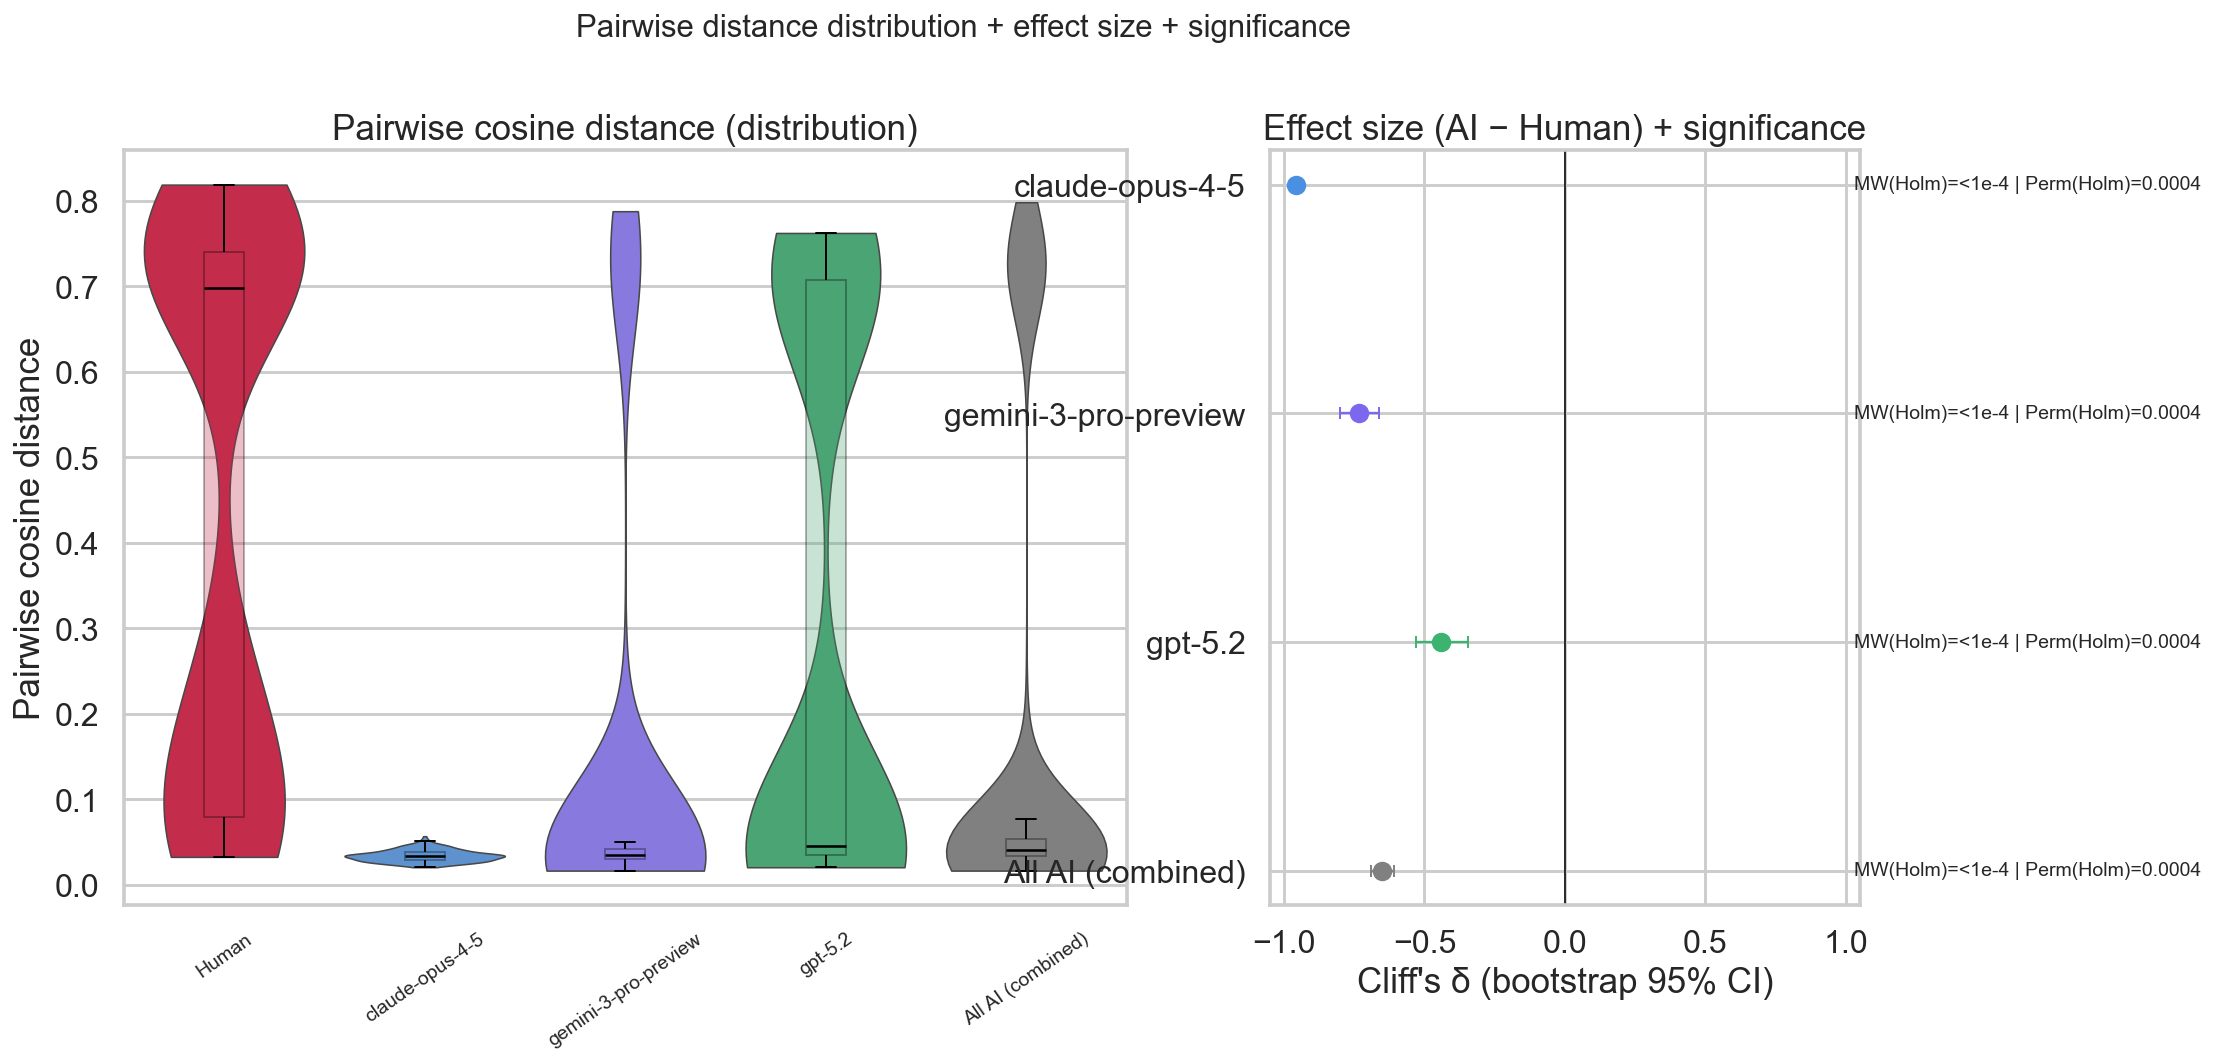

In [117]:
# visualization (PAIRWISE distances + effect size/significance), using your predefined `colors`
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def bootstrap_cliffs_delta_ci(group1, group2, n_boot=2000, random_state=42, alpha=0.05):
    rng = np.random.default_rng(random_state)
    g1 = np.asarray(group1, dtype=float)
    g2 = np.asarray(group2, dtype=float)

    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        b1 = rng.choice(g1, size=len(g1), replace=True)
        b2 = rng.choice(g2, size=len(g2), replace=True)
        boots[i] = cliffs_delta(b1, b2)  # reuse your existing function

    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return lo, hi


# ---- Build long df for PAIRWISE distances (matches your summary table) ----
plot_specs = [("Human", human_pairwise)]

for m in ai_models:
    if len(model_pairwise.get(m, [])) > 0:
        plot_specs.append((m, model_pairwise[m]))

plot_specs.append(("All AI (combined)", ai_pairwise))

dist_df = pd.concat(
    [pd.DataFrame({"group": g, "pairwise_distance": np.asarray(v, dtype=float)}) for g, v in plot_specs],
    ignore_index=True,
)

group_order = [g for g, _ in plot_specs]

palette = {g: colors.get(g, "#808080") for g in group_order}
palette["All AI (combined)"] = palette.get("All AI (combined)", "#808080")


# ---- Recompute stats on PAIRWISE distances (so right panel matches left panel’s metric) ----
comparison_specs = [("All AI (combined)", ai_pairwise)] + [
    (m, model_pairwise[m]) for m in ai_models if len(model_pairwise.get(m, [])) > 0
]

comparison_results = []
for group_name, vals in comparison_specs:
    res = run_group_comparison(vals, human_pairwise, n_permutations=10000, n_boot=5000, random_state=42)
    res["group"] = group_name
    comparison_results.append(res)

eff_df = pd.DataFrame(comparison_results)
eff_df = apply_multiple_testing(eff_df, p_cols=("p_value_mw", "p_value_perm"), method="holm")

# bootstrap CI for δ (PAIRWISE; group vs Human)
delta_ci_low, delta_ci_high = [], []
for g in eff_df["group"].tolist():
    gvals = ai_pairwise if g == "All AI (combined)" else model_pairwise[g]
    lo, hi = bootstrap_cliffs_delta_ci(gvals, human_pairwise, n_boot=2000, random_state=42)
    delta_ci_low.append(lo)
    delta_ci_high.append(hi)

eff_df["delta_ci_low"] = delta_ci_low
eff_df["delta_ci_high"] = delta_ci_high

eff_order = [g for g in group_order if g not in ("Human",)]
eff_df["group"] = pd.Categorical(eff_df["group"], categories=eff_order, ordered=True)
eff_df = eff_df.sort_values("group")


def fmt_p(p):
    if pd.isna(p):
        return "NA"
    if p < 1e-4:
        return "<1e-4"
    return f"{p:.4f}"


# ---- Plot: left = pairwise distribution, right = δ + CI + Holm p-values ----
sns.set_theme(style="whitegrid", context="talk")

fig = plt.figure(figsize=(16, 7), dpi=140)
gs = fig.add_gridspec(1, 2, width_ratios=[1.7, 1.0], wspace=0.18)
axL = fig.add_subplot(gs[0, 0])
axR = fig.add_subplot(gs[0, 1])

# Left panel: PAIRWISE distance distributions
sns.violinplot(
    data=dist_df,
    x="group",
    y="pairwise_distance",
    order=group_order,
    hue="group",
    hue_order=group_order,
    palette=palette,
    inner=None,
    cut=0,
    linewidth=0.8,
    dodge=False,
    ax=axL,
)
sns.boxplot(
    data=dist_df,
    x="group",
    y="pairwise_distance",
    order=group_order,
    hue="group",
    hue_order=group_order,
    palette=palette,
    width=0.20,
    showfliers=False,
    dodge=False,
    boxprops=dict(alpha=0.30, edgecolor="black", linewidth=1.0),
    medianprops=dict(color="black", linewidth=1.3),
    whiskerprops=dict(color="black", linewidth=1.0),
    capprops=dict(color="black", linewidth=1.0),
    ax=axL,
)

if axL.get_legend() is not None:
    axL.get_legend().remove()

axL.set_title("Pairwise cosine distance (distribution)")
axL.set_xlabel("")
axL.set_ylabel("Pairwise cosine distance")
axL.tick_params(axis="x", rotation=35, labelsize=10)

# Right panel: Cliff’s δ with bootstrap CI + Holm-adjusted p-values (PAIRWISE)
axR.axvline(0, color="black", linewidth=1.0, alpha=0.8)

ypos = np.arange(len(eff_df))
axR.set_yticks(ypos)
axR.set_yticklabels(eff_df["group"].astype(str))
axR.invert_yaxis()

for i, row in enumerate(eff_df.itertuples(index=False)):
    g = str(row.group)
    c = palette.get(g, "#808080")

    axR.errorbar(
        row.delta,
        i,
        xerr=np.array([[row.delta - row.delta_ci_low], [row.delta_ci_high - row.delta]]),
        fmt="o",
        color=c,
        ecolor=c,
        elinewidth=1.2,
        capsize=3,
    )

    txt = (
        f"MW(Holm)={fmt_p(getattr(row, 'p_value_mw_adj_holm', np.nan))} | "
        f"Perm(Holm)={fmt_p(getattr(row, 'p_value_perm_adj_holm', np.nan))}"
    )
    axR.text(1.03, i, txt, va="center", ha="left", fontsize=10, clip_on=False)

axR.set_title("Effect size (AI − Human) + significance")
axR.set_xlabel("Cliff's δ (bootstrap 95% CI)")
axR.set_ylabel("")
axR.set_xlim(-1.05, 1.05)

plt.suptitle("Pairwise distance distribution + effect size + significance", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

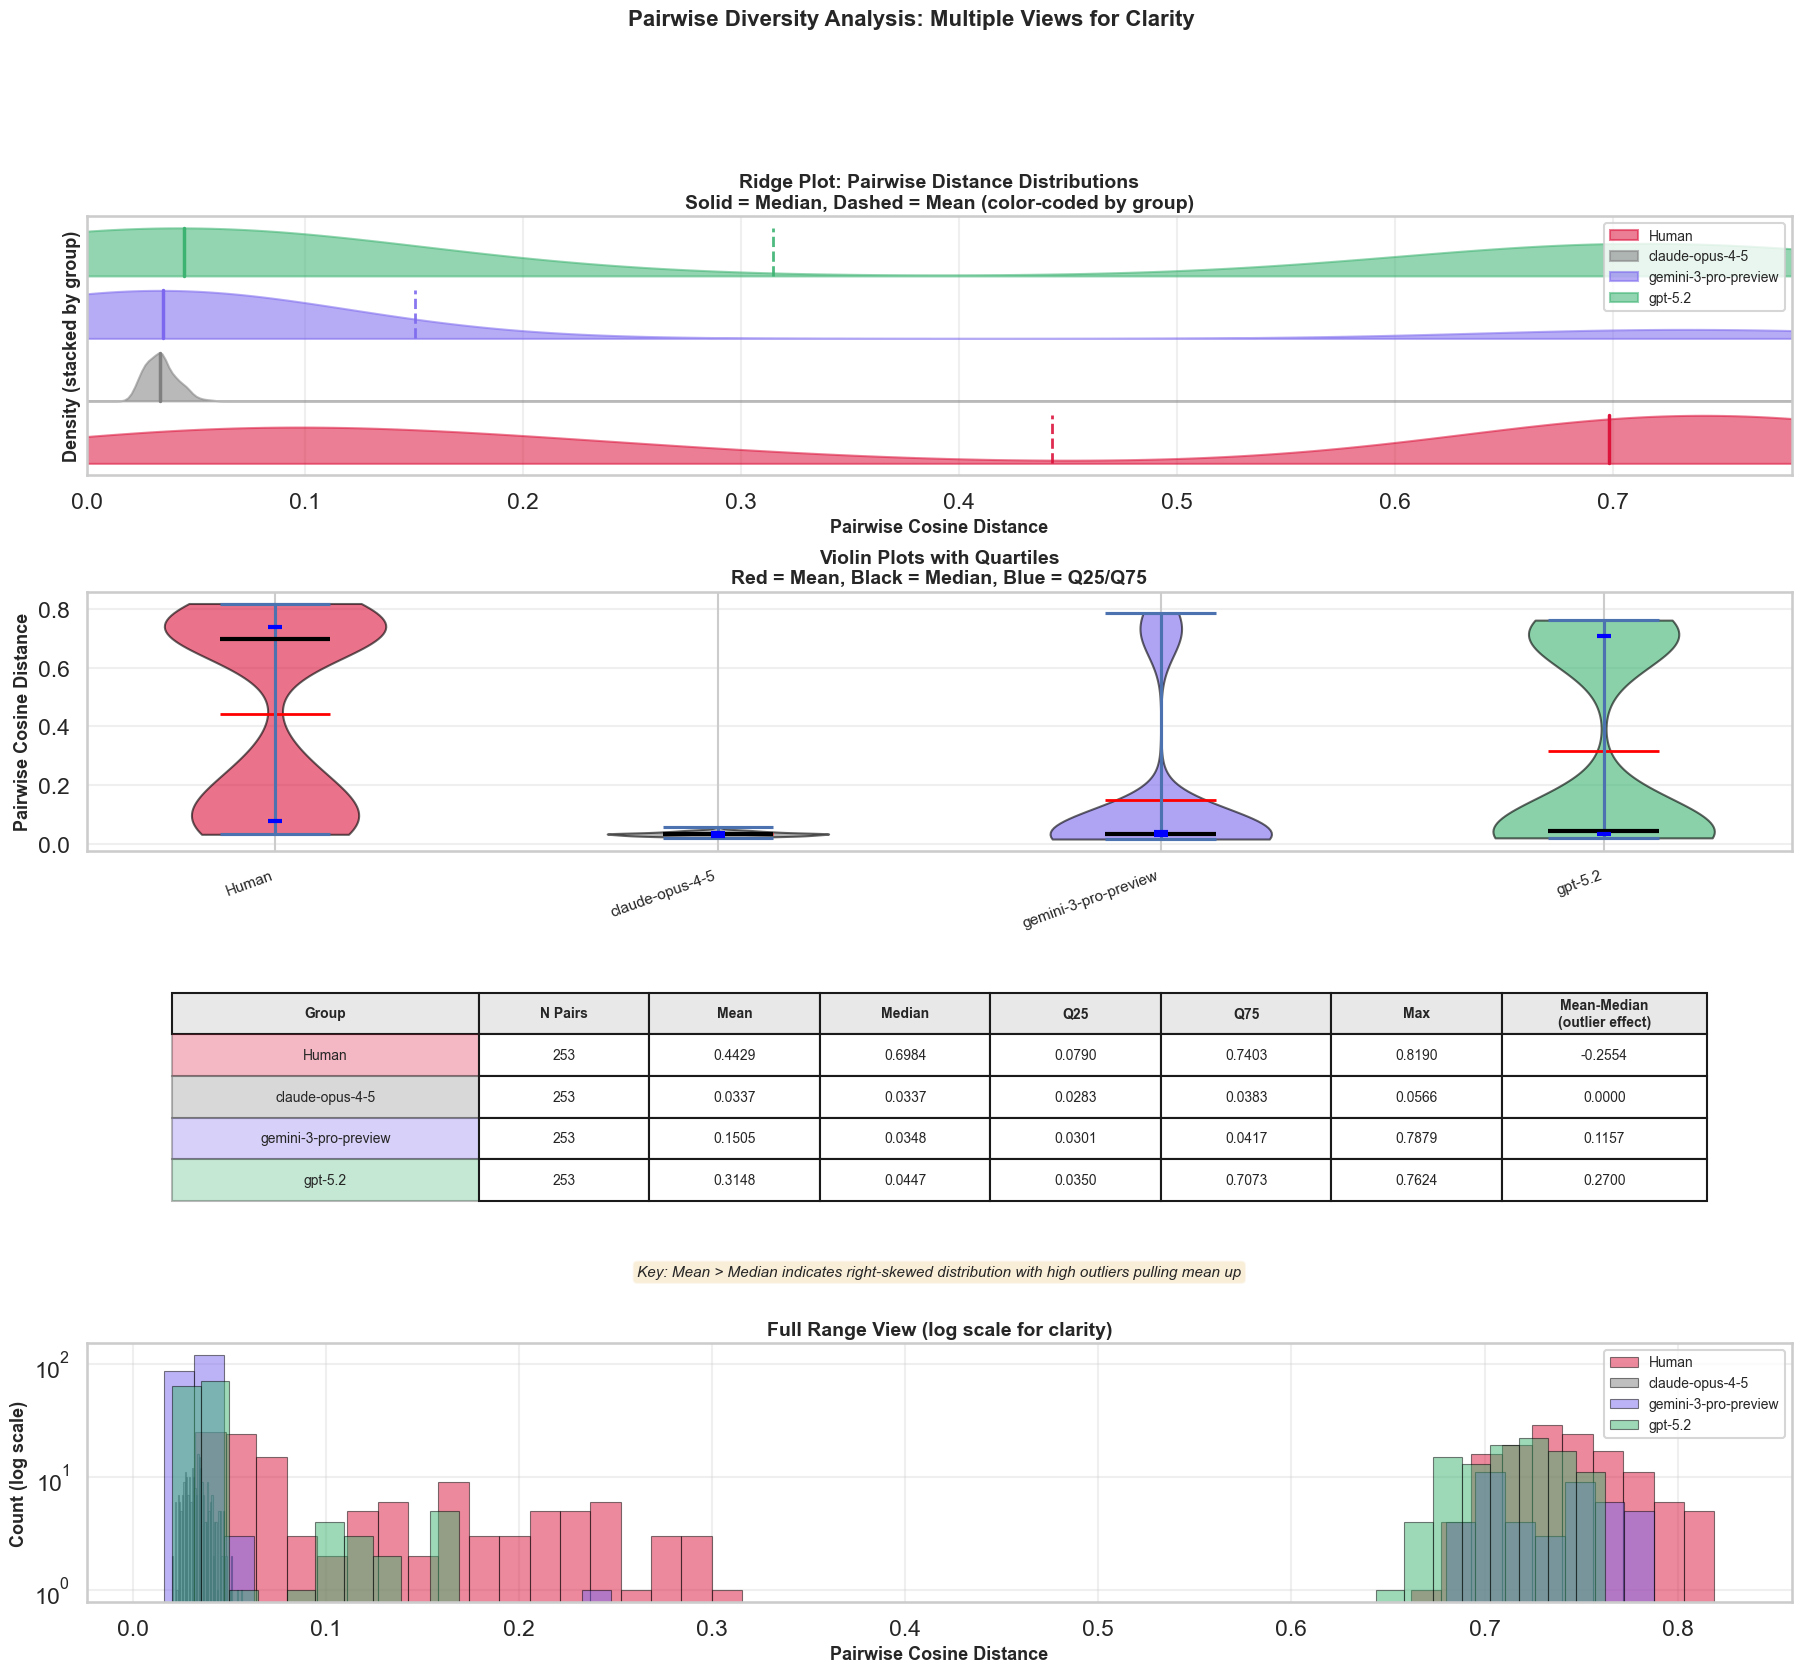

✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/pairwise_diversity_by_model.png


In [118]:
# Visualization: Improved distribution comparison for all groups
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# Layout: 4 rows — ridge plot (full width), violin (full width),
#         summary table (full width), log-scale histogram (full width, new row)
fig = plt.figure(figsize=(22, 18))
gs = fig.add_gridspec(4, 1, hspace=0.45)

# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-6': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#3CB371',  # Dark orange
}

group_order = ['Human'] + [m for m in ai_models if len(model_pairwise[m]) > 0]

# ── PANEL 1 (Row 0, full width): Ridge plot — x-range covers ALL group medians/means
# Determine x-limit: at least 0.2, but extend to fit the furthest median or mean + margin
all_stats = []
for group in group_order:
    d = human_pairwise if group == 'Human' else model_pairwise[group]
    all_stats += [float(np.median(d)), float(np.mean(d))]
x_limit = max(0.2, max(all_stats) * 1.12)   # 12% margin past the furthest stat line

ax1 = fig.add_subplot(gs[0])
RIDGE_HEIGHT = 1.0   # normalized peak height for every group (equal visual weight)
RIDGE_GAP    = 0.3   # gap between ridges
offset = 0

for idx, group in enumerate(group_order):
    data = human_pairwise if group == 'Human' else model_pairwise[group]
    grp_color = colors.get(group, 'gray')

    if len(data) > 1:
        kde = gaussian_kde(data)
        x_range = np.linspace(0, x_limit, 500)
        density = kde(x_range)
        # Normalize so every ridge peaks at RIDGE_HEIGHT (equal visual weight)
        density_norm = density / density.max() * RIDGE_HEIGHT

        ax1.fill_between(x_range, offset + density_norm, offset,
                         color=grp_color, alpha=0.55,
                         edgecolor=grp_color, linewidth=1.5, label=group)

        ridge_top = offset + RIDGE_HEIGHT

        # Median — solid line spanning full ridge height
        median_val = float(np.median(data))
        ax1.plot([median_val, median_val], [offset, ridge_top],
                 color=grp_color, linestyle='-', linewidth=2.5, alpha=1.0, zorder=5)

        # Mean — dashed line spanning full ridge height
        mean_val = float(np.mean(data))
        ax1.plot([mean_val, mean_val], [offset, ridge_top],
                 color=grp_color, linestyle='--', linewidth=2.0, alpha=0.9, zorder=5)

        offset += RIDGE_HEIGHT + RIDGE_GAP

ax1.set_xlabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax1.set_ylabel('Density (stacked by group)', fontsize=13, fontweight='bold')
ax1.set_title('Ridge Plot: Pairwise Distance Distributions\nSolid = Median, Dashed = Mean (color-coded by group)',
              fontsize=14, fontweight='bold')
ax1.set_xlim(0, x_limit)
ax1.set_yticks([])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(alpha=0.3, axis='x')

# ── PANEL 2 (Row 1, full width): Violin plots with quartile annotations
ax3 = fig.add_subplot(gs[1])

box_data = []
for dist, label in [(human_pairwise, 'Human')] + [(model_pairwise[m], m) for m in ai_models if len(model_pairwise[m]) > 0]:
    for val in dist:
        box_data.append({'Distance': val, 'Group': label})

box_df = pd.DataFrame(box_data)
palette_list = [colors.get(g, 'gray') for g in group_order]

# Create violin plot
parts = ax3.violinplot([box_df[box_df['Group']==g]['Distance'].values for g in group_order],
                       positions=range(len(group_order)),
                       showmeans=True, showmedians=True, showextrema=True)

# Color the violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette_list[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

# Enhance median and mean lines
parts['cmedians'].set_edgecolor('black')
parts['cmedians'].set_linewidth(3)
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)

# Add quartile markers
for idx, group in enumerate(group_order):
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    q25, q75 = np.percentile(data, [25, 75])
    ax3.scatter([idx, idx], [q25, q75], color='blue', s=100, zorder=3, marker='_', linewidths=3)

ax3.set_xticks(range(len(group_order)))
ax3.set_xticklabels(group_order, fontsize=11, rotation=20, ha='right')
ax3.set_ylabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax3.set_title('Violin Plots with Quartiles\nRed = Mean, Black = Median, Blue = Q25/Q75', 
              fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3, axis='y')

# ── PANEL 3 (Row 2, full width): Statistical summary table
ax4 = fig.add_subplot(gs[2])
ax4.axis('off')

# Create summary statistics
summary_data = []
for group in group_order:
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    summary_data.append([
        group,
        f"{len(data)}",
        f"{data.mean():.4f}",
        f"{np.median(data):.4f}",
        f"{np.percentile(data, 25):.4f}",
        f"{np.percentile(data, 75):.4f}",
        f"{data.max():.4f}",
        f"{data.mean() - np.median(data):.4f}"
    ])

# Create table
table = ax4.table(cellText=summary_data,
                 colLabels=['Group', 'N Pairs', 'Mean', 'Median', 'Q25', 'Q75', 'Max', 'Mean-Median\n(outlier effect)'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.18, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color code the header
for i in range(8):
    table[(0, i)].set_facecolor('#E8E8E8')
    table[(0, i)].set_text_props(weight='bold')

# Color code the groups
for i, group in enumerate(group_order):
    table[(i+1, 0)].set_facecolor(colors.get(group, 'gray'))
    table[(i+1, 0)].set_alpha(0.3)

ax4.text(0.5, -0.15, 
         'Key: Mean > Median indicates right-skewed distribution with high outliers pulling mean up',
         ha='center', va='top', transform=ax4.transAxes, fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── PANEL 4 (Row 3, full width): Full-range histogram with log-scale y-axis
ax2 = fig.add_subplot(gs[3])
for group in group_order:
    data = human_pairwise if group == 'Human' else model_pairwise[group]
    ax2.hist(data, bins=50, alpha=0.5, label=group,
             color=colors.get(group, 'gray'), edgecolor='black', linewidth=0.8)

ax2.set_xlabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count (log scale)', fontsize=13, fontweight='bold')
ax2.set_title('Full Range View (log scale for clarity)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle('Pairwise Diversity Analysis: Multiple Views for Clarity', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig(FIGURES_DIR / 'pairwise_diversity_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {FIGURES_DIR / 'pairwise_diversity_by_model.png'}")


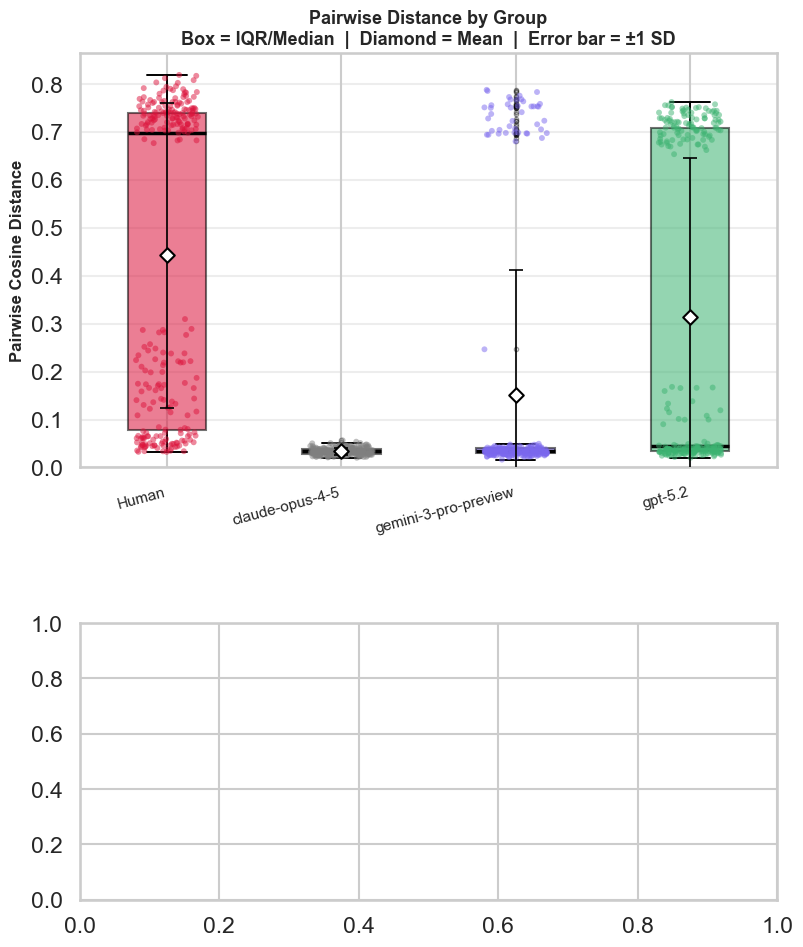

Group                            N     Mean   Median       SD      Min      Max
------------------------------------------------------------------------
Human                          253   0.4429   0.6984   0.3182   0.0324   0.8190
claude-opus-4-5                253   0.0337   0.0337   0.0069   0.0203   0.0566
gemini-3-pro-preview           253   0.1505   0.0348   0.2613   0.0164   0.7879
gpt-5.2                        253   0.3148   0.0447   0.3301   0.0203   0.7624


In [119]:
# Box plot summary + Cliff's delta panel for pairwise distances
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, (ax, ax_delta) = plt.subplots(2, 1, figsize=(9, 11),
                                    gridspec_kw={'height_ratios': [3, 2], 'hspace': 0.45})

box_arrays = []
for group in group_order:
    d = human_pairwise if group == 'Human' else model_pairwise[group]
    box_arrays.append(d)

# Box plot (shows median, IQR, whiskers)
bp = ax.boxplot(box_arrays, positions=range(len(group_order)),
                patch_artist=True, widths=0.45,
                medianprops=dict(color='black', linewidth=2.5),
                whiskerprops=dict(linewidth=1.4),
                capprops=dict(linewidth=1.4),
                flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'))

for patch, group in zip(bp['boxes'], group_order):
    patch.set_facecolor(colors.get(group, 'gray'))
    patch.set_alpha(0.55)
    patch.set_linewidth(1.5)

# Overlay individual points (jittered)
rng = np.random.default_rng(42)
for i, (group, d) in enumerate(zip(group_order, box_arrays)):
    jitter = rng.uniform(-0.18, 0.18, size=len(d))
    ax.scatter(i + jitter, d,
               color=colors.get(group, 'gray'), s=18, alpha=0.5,
               edgecolors='none', zorder=3)

# Mean markers (diamond)
for i, d in enumerate(box_arrays):
    ax.scatter(i, np.mean(d), marker='D', s=55,
               color='white', edgecolors='black', linewidths=1.5, zorder=5)

# SD error bars around the mean
for i, d in enumerate(box_arrays):
    m, s = np.mean(d), np.std(d, ddof=1)
    ax.errorbar(i, m, yerr=s, fmt='none',
                ecolor='black', elinewidth=1.2, capsize=5, capthick=1.2, zorder=4)

ax.set_xticks(range(len(group_order)))
ax.set_xticklabels(group_order, fontsize=11, rotation=15, ha='right')
ax.set_ylabel('Pairwise Cosine Distance', fontsize=12, fontweight='bold')
ax.set_title('Pairwise Distance by Group\nBox = IQR/Median  |  Diamond = Mean  |  Error bar = ±1 SD',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.35)
ax.set_ylim(bottom=0)


plt.savefig(FIGURES_DIR / 'pairwise_diversity_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"{'Group':<28} {'N':>5}  {'Mean':>7}  {'Median':>7}  {'SD':>7}  {'Min':>7}  {'Max':>7}")
print('-' * 72)
for group, d in zip(group_order, box_arrays):
    print(f"{group:<28} {len(d):>5}  {np.mean(d):>7.4f}  {np.median(d):>7.4f}"
          f"  {np.std(d, ddof=1):>7.4f}  {d.min():>7.4f}  {d.max():>7.4f}")

## Analysis 1.2: Centroid Dispersion Metric (mean radius + Span-90)

Compute raw centroid distances, leave-one-out centroid distances, and group Span-90.

### 1.2a Within-group Centroid Dispersion

In [120]:

print('='*85)
print('ANALYSIS 1.2: CENTROID DISPERSION (RAW + LOO + SPAN90)')
print('='*85)

rows = []
group_rows = []

for g, gc in group_cache.items():
    idx = gc['idx']
    Xg = gc['X']
    n = gc['n']
    d_raw = proposal_centroid_distances(Xg, leave_one_out=False)
    d_loo = proposal_centroid_distances(Xg, leave_one_out=True)
    span90 = safe_percentile(d_raw, 90)

    group_rows.append({
        'group': g,
        'n': n,
        'centroid_mean_raw': float(np.mean(d_raw)) if len(d_raw) else np.nan,
        'centroid_median_raw': float(np.median(d_raw)) if len(d_raw) else np.nan,
        'centroid_sd_raw': float(np.std(d_raw)) if len(d_raw) else np.nan,
        'centroid_var_raw': float(np.var(d_raw)) if len(d_raw) else np.nan,
        'centroid_mean_loo': float(np.mean(d_loo)) if len(d_loo) else np.nan,
        'centroid_median_loo': float(np.median(d_loo)) if len(d_loo) else np.nan,
        'centroid_sd_loo': float(np.std(d_loo)) if len(d_loo) else np.nan,
        'span_90': span90,
    })

    for pos, pid in enumerate(idx):
        rows.append({
            'proposal_uid': proposal_meta.loc[pid, 'proposal_uid'],
            'title': proposal_meta.loc[pid, 'title'],
            'group_model': proposal_meta.loc[pid, 'group_model'],
            'group_binary': proposal_meta.loc[pid, 'group_binary'],
            'centroid_dist_raw': float(d_raw[pos]),
            'centroid_dist_loo': float(d_loo[pos]),
        })

centroid_proposal_df = pd.DataFrame(rows)
span90_group_summary_df = pd.DataFrame(group_rows)

# Backward-compatible vars for existing plotting cells
human_centroid_dists = centroid_proposal_df.loc[centroid_proposal_df['group_binary']=='Human', 'centroid_dist_loo'].to_numpy()
ai_centroid_dists = centroid_proposal_df.loc[centroid_proposal_df['group_binary']=='AI', 'centroid_dist_loo'].to_numpy()
model_centroid_dists = {
    m: centroid_proposal_df.loc[centroid_proposal_df['group_model']==m, 'centroid_dist_loo'].to_numpy()
    for m in ai_models
}

# tests on centroid_dist_loo
centroid_tests = []
human_vals = centroid_proposal_df.loc[centroid_proposal_df['group_binary']=='Human', 'centroid_dist_loo'].to_numpy()
for g in ['All AI'] + ai_models:
    g_vals = centroid_proposal_df.loc[
        (centroid_proposal_df['group_binary']=='AI') if g=='All AI' else (centroid_proposal_df['group_model']==g),
        'centroid_dist_loo'
    ].to_numpy()
    if len(g_vals) == 0:
        continue
    r = run_group_comparison(g_vals, human_vals, n_permutations=10000, n_boot=5000, random_state=42)
    r.update({'comparison': f'{g} vs Human', 'group1': g, 'group2': 'Human', 'n_group1': len(g_vals), 'n_group2': len(human_vals)})
    centroid_tests.append(r)

centroid_tests_df = pd.DataFrame(centroid_tests)
if len(centroid_tests_df):
    centroid_tests_df = apply_multiple_testing(centroid_tests_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')

centroid_export_df = centroid_proposal_df.copy()
centroid_export_df['group'] = centroid_export_df['group_model']
centroid_export_df['centroid_dist'] = centroid_export_df['centroid_dist_loo']
centroid_export_df.to_csv(TABLES_DIR / 'centroid_distances.csv', index=False)
span90_group_summary_df.to_csv(TABLES_DIR / 'diversity_span90_group_summary.csv', index=False)
centroid_tests_df.to_csv(TABLES_DIR / 'diversity_centroid_pairwise_tests.csv', index=False)

print(span90_group_summary_df[['group', 'n', 'centroid_mean_loo', 'span_90']].to_string(index=False))
print('\nSaved centroid_distances.csv, diversity_span90_group_summary.csv, diversity_centroid_pairwise_tests.csv')


ANALYSIS 1.2: CENTROID DISPERSION (RAW + LOO + SPAN90)
               group  n  centroid_mean_loo  span_90
               Human 23           0.266497 0.313707
     claude-opus-4-5 23           0.017776 0.021409
gemini-3-pro-preview 23           0.080214 0.027462
             gpt-5.2 23           0.178683 0.467307
              All AI 69           0.096756 0.584115

Saved centroid_distances.csv, diversity_span90_group_summary.csv, diversity_centroid_pairwise_tests.csv


In [121]:
print("="*85)
print("STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)")
print("="*85)
print("Primary estimand: mean difference in centroid distance (AI - Human).")

comparison_specs = [('All AI', ai_centroid_dists)] + [
    (model, model_centroid_dists[model])
    for model in ai_models
    if model in model_centroid_dists
]

centroid_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_centroid_dists, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    centroid_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals are MORE dispersed from center")
    else:
        print(f"  → Human proposals are MORE dispersed from center")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

centroid_df = pd.DataFrame(centroid_results)
centroid_df = apply_multiple_testing(centroid_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
centroid_comparison_results = centroid_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Centroid Dispersion with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in centroid_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive mean-diff/δ = AI more dispersed; Negative = Human more dispersed")


STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)
Primary estimand: mean difference in centroid distance (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 368, p-value: 3.9452e-09
Cliff's Delta:
  δ = -0.7681 (large effect)
  → Human proposals are MORE dispersed from center
Primary mean difference (AI - Human):
  Observed difference: -0.1720
  Bootstrap 95% CI: [-0.2121, -0.1289]
  Permutation p-value: 0.0002

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 0, p-value: 1.7279e-11
Cliff's Delta:
  δ = -1.0000 (large effect)
  → Human proposals are MORE dispersed from center
Primary mea

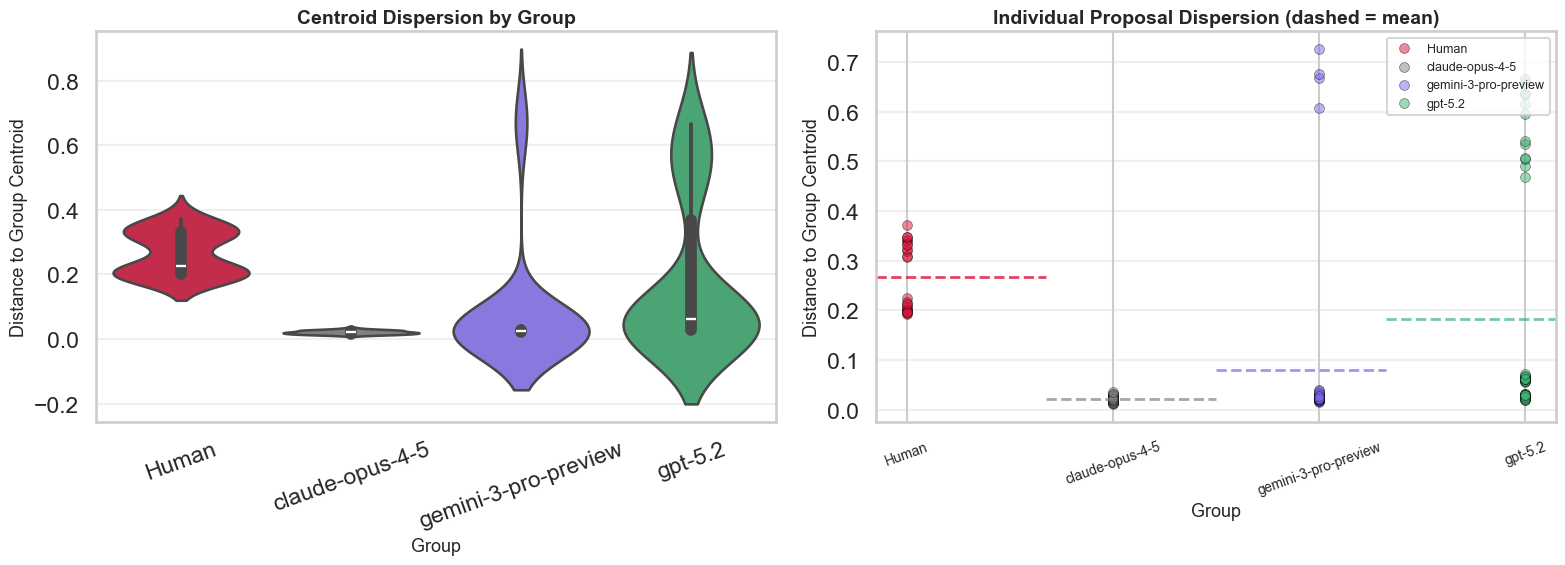

✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/centroid_dispersion_by_model.png


In [122]:
# Visualization: Centroid dispersion for all groups
fig, axes = plt.subplots(1, 2, figsize=(16, 6))



# LEFT PANEL: Violin plots
violin_data = []
for dist, label in [(human_centroid_dists, 'Human')] + [(model_centroid_dists[m], m) for m in ai_models if m in model_centroid_dists]:
    for val in dist:
        violin_data.append({'Distance to Centroid': val, 'Group': label})

violin_df = pd.DataFrame(violin_data)
group_order = ['Human'] + [m for m in ai_models if m in model_centroid_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=violin_df, x='Group', y='Distance to Centroid', ax=axes[0], palette=palette_list, order=group_order)
axes[0].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[0].set_xlabel('Group', fontsize=13)
axes[0].set_title('Centroid Dispersion by Group', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

# RIGHT PANEL: Scatter plot showing individual proposals
offset = 0
x_positions = {}

# Human
x_positions['Human'] = 0
axes[1].scatter([0]*len(human_centroid_dists), human_centroid_dists, 
               alpha=0.5, label='Human', color=colors['Human'], s=50, edgecolors='black', linewidth=0.5)
axes[1].axhline(human_centroid_dists.mean(), xmin=0/len(group_order), xmax=1/len(group_order), 
               color=colors['Human'], linestyle='--', linewidth=2, alpha=0.8)

offset = 1
# Individual AI models
for i, model in enumerate([m for m in ai_models if m in model_centroid_dists]):
    x_positions[model] = offset
    axes[1].scatter([offset]*len(model_centroid_dists[model]), model_centroid_dists[model], 
                   alpha=0.5, label=model, color=colors.get(model, 'gray'), s=50, edgecolors='black', linewidth=0.5)
    axes[1].axhline(model_centroid_dists[model].mean(), 
                   xmin=offset/len(group_order), xmax=(offset+1)/len(group_order),
                   color=colors.get(model, 'gray'), linestyle='--', linewidth=2, alpha=0.7)
    offset += 1

axes[1].set_xticks(range(len(group_order)))
axes[1].set_xticklabels(group_order, rotation=20, fontsize=10)
axes[1].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[1].set_xlabel('Group', fontsize=13)
axes[1].set_title('Individual Proposal Dispersion (dashed = mean)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'centroid_dispersion_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {FIGURES_DIR / 'centroid_dispersion_by_model.png'}")


### 1.2b: Between-Group Centroid Dispersion

Measure **between-group dispersion** from a **single global centroid** built from all Human and AI proposals.

Groups included:
- **Human proposals**
- **Each AI model's proposals**
- **All AI proposals (combined)**

For each proposal, compute cosine distance to the global centroid. Then compare group-level dispersion distributions with inferential tests.


In [123]:

print('='*85)
print('ANALYSIS 1.2b: BETWEEN-GROUP GLOBAL-CENTROID DISPERSION')
print('='*85)

global_centroid = X_prop.mean(axis=0, keepdims=True)
global_centroid_dist = cosine_distances(X_prop, global_centroid).ravel()

between_group_global_centroid_df = proposal_meta[['proposal_uid', 'title', 'group_model', 'group_binary']].copy()
between_group_global_centroid_df['global_centroid_dist'] = global_centroid_dist

sum_rows = []
for g, idx in GROUPS.items():
    vals = global_centroid_dist[idx]
    sum_rows.append({
        'group': g,
        'n': len(vals),
        'mean': float(np.mean(vals)),
        'median': float(np.median(vals)),
        'sd': float(np.std(vals)),
        'var': float(np.var(vals)),
    })
between_group_global_centroid_summary_df = pd.DataFrame(sum_rows)

# pairwise tests all groups
pairwise = []
order = ['Human'] + ai_models + ['All AI']
for i in range(len(order)):
    for j in range(i+1, len(order)):
        g1, g2 = order[i], order[j]
        m1 = (between_group_global_centroid_df['group_binary']=='AI') if g1=='All AI' else (between_group_global_centroid_df['group_model']==g1)
        m2 = (between_group_global_centroid_df['group_binary']=='AI') if g2=='All AI' else (between_group_global_centroid_df['group_model']==g2)
        v1 = between_group_global_centroid_df.loc[m1, 'global_centroid_dist'].to_numpy()
        v2 = between_group_global_centroid_df.loc[m2, 'global_centroid_dist'].to_numpy()
        if len(v1)==0 or len(v2)==0:
            continue
        r = run_group_comparison(v1, v2, n_permutations=10000, n_boot=5000, random_state=42)
        r.update({'group_1': g1, 'group_2': g2, 'n_1': len(v1), 'n_2': len(v2), 'comparison': f'{g1} vs {g2}'})
        pairwise.append(r)

between_group_global_centroid_tests_df = pd.DataFrame(pairwise)
if len(between_group_global_centroid_tests_df):
    between_group_global_centroid_tests_df = apply_multiple_testing(
        between_group_global_centroid_tests_df,
        p_cols=('p_value_mw', 'p_value_perm'),
        method='holm'
    )

between_group_global_centroid_df.to_csv(TABLES_DIR / 'between_group_global_centroid_distances.csv', index=False)
between_group_global_centroid_summary_df.to_csv(TABLES_DIR / 'between_group_global_centroid_group_summary.csv', index=False)
between_group_global_centroid_tests_df.to_csv(TABLES_DIR / 'between_group_global_centroid_pairwise_tests.csv', index=False)

print('Saved between_group_global_centroid_* exports')


ANALYSIS 1.2b: BETWEEN-GROUP GLOBAL-CENTROID DISPERSION
Saved between_group_global_centroid_* exports


VISUALIZATION: 1.2b BETWEEN-GROUP GLOBAL-CENTROID DISPERSION


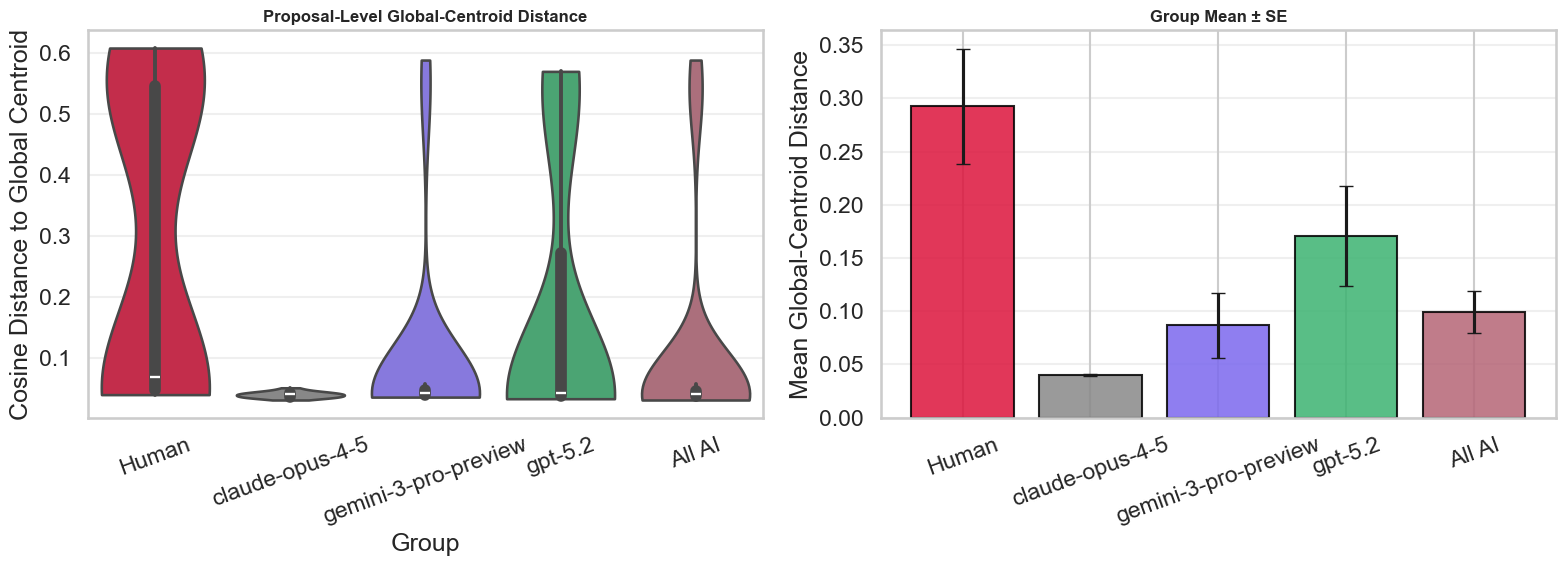

Saved figure: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/between_group_global_centroid_dispersion.png

Pairwise tests involving Human (Holm-adjusted):
group_1              group_2  obs_diff_mean    delta   p_value_mw  p_value_mw_adj_holm  p_value_perm  p_value_perm_adj_holm
  Human               All AI       0.193497 0.724008 2.270076e-07             0.000002      0.000100               0.001000
  Human      claude-opus-4-5       0.252553 0.886578 2.735882e-07             0.000002      0.000100               0.001000
  Human gemini-3-pro-preview       0.205745 0.705104 4.383682e-05             0.000351      0.001300               0.010399
  Human              gpt-5.2       0.122191 0.580340 7.758083e-04             0.005431      0.064294               0.321468


In [124]:

# Visualization + test summary: Analysis 1.2b
print('='*85)
print('VISUALIZATION: 1.2b BETWEEN-GROUP GLOBAL-CENTROID DISPERSION')
print('='*85)

if 'between_group_global_centroid_df' not in globals():
    raise RuntimeError('between_group_global_centroid_df missing. Run Analysis 1.2b cell first.')

plot_df = between_group_global_centroid_df[['group_model', 'group_binary', 'global_centroid_dist']].copy()
plot_df['group_plot'] = plot_df['group_model']
all_ai_df = plot_df.loc[plot_df['group_binary'] == 'AI'].copy()
all_ai_df['group_plot'] = 'All AI'
plot_df = pd.concat([plot_df, all_ai_df], ignore_index=True)

group_order_plot = ['Human'] + [m for m in ai_models if m in set(plot_df['group_plot'])] + ['All AI']
palette = [colors.get(g, '#888888') if g != 'All AI' else '#B56576' for g in group_order_plot]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(
    data=plot_df, x='group_plot', y='global_centroid_dist',
    order=group_order_plot, palette=palette, inner='box', cut=0, ax=axes[0]
)
axes[0].set_title('Proposal-Level Global-Centroid Distance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Cosine Distance to Global Centroid')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

summary_plot = (
    plot_df.groupby('group_plot')['global_centroid_dist']
    .agg(['mean', 'std', 'count'])
    .reindex(group_order_plot)
)
se = summary_plot['std'] / np.sqrt(summary_plot['count'].clip(lower=1))
axes[1].bar(
    np.arange(len(group_order_plot)),
    summary_plot['mean'].values,
    yerr=se.values,
    capsize=5,
    color=palette,
    edgecolor='black',
    alpha=0.85,
)
axes[1].set_xticks(np.arange(len(group_order_plot)))
axes[1].set_xticklabels(group_order_plot, rotation=20)
axes[1].set_title('Group Mean ± SE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Global-Centroid Distance')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
fig_path = FIGURES_DIR / 'between_group_global_centroid_dispersion.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved figure: {fig_path}')

if 'between_group_global_centroid_tests_df' in globals() and len(between_group_global_centroid_tests_df):
    tests = between_group_global_centroid_tests_df.copy()
    mask_h = (tests['group_1'] == 'Human') | (tests['group_2'] == 'Human')
    human_tests = tests.loc[mask_h].copy()
    if len(human_tests):
        print('\nPairwise tests involving Human (Holm-adjusted):')
        cols = [
            'group_1', 'group_2', 'obs_diff_mean', 'delta',
            'p_value_mw', 'p_value_mw_adj_holm', 'p_value_perm', 'p_value_perm_adj_holm'
        ]
        for c in cols:
            if c not in human_tests.columns:
                human_tests[c] = np.nan
        print(human_tests[cols].sort_values('p_value_mw_adj_holm').to_string(index=False))


## Analysis 1.2c: MST Dispersion

In [125]:

print('='*85)
print('ANALYSIS 1.2c: MST DISPERSION')
print('='*85)

rows = []
for g, gc in group_cache.items():
    Dg = gc['D']
    mst_val = group_mst_dispersion(Dg)
    boot = bootstrap_group_metric(Dg, group_mst_dispersion, n_boot=5000, random_state=42, metric_type='distance')
    rows.append({
        'group': g,
        'n': gc['n'],
        'mst_dispersion': mst_val,
        'mst_boot_mean': boot['boot_mean'],
        'mst_boot_ci_low': boot['ci_low'],
        'mst_boot_ci_high': boot['ci_high'],
    })

mst_group_summary_df = pd.DataFrame(rows)

perm_rows = []
for g in ai_models + ['All AI']:
    if g not in GROUPS:
        continue
    pt = permutation_test_group_metric(D_pp, proposal_meta['group_model'].to_numpy(), GROUPS[g], GROUPS['Human'], group_mst_dispersion, n_perm=10000, random_state=42, use_distance_submat=True)
    perm_rows.append({'comparison': f'{g} vs Human', 'group1': g, 'group2': 'Human', **pt})

mst_pairwise_perm_df = pd.DataFrame(perm_rows)
if len(mst_pairwise_perm_df):
    mst_pairwise_perm_df = apply_multiple_testing(mst_pairwise_perm_df, p_cols=('perm_p_value',), method='holm')

mst_group_summary_df.to_csv(TABLES_DIR / 'diversity_mst_group_summary.csv', index=False)
mst_pairwise_perm_df.to_csv(TABLES_DIR / 'diversity_mst_pairwise_permutation.csv', index=False)
print('Saved diversity_mst_group_summary.csv and diversity_mst_pairwise_permutation.csv')


ANALYSIS 1.2c: MST DISPERSION
Saved diversity_mst_group_summary.csv and diversity_mst_pairwise_permutation.csv


VISUALIZATION: 1.2c MST DISPERSION


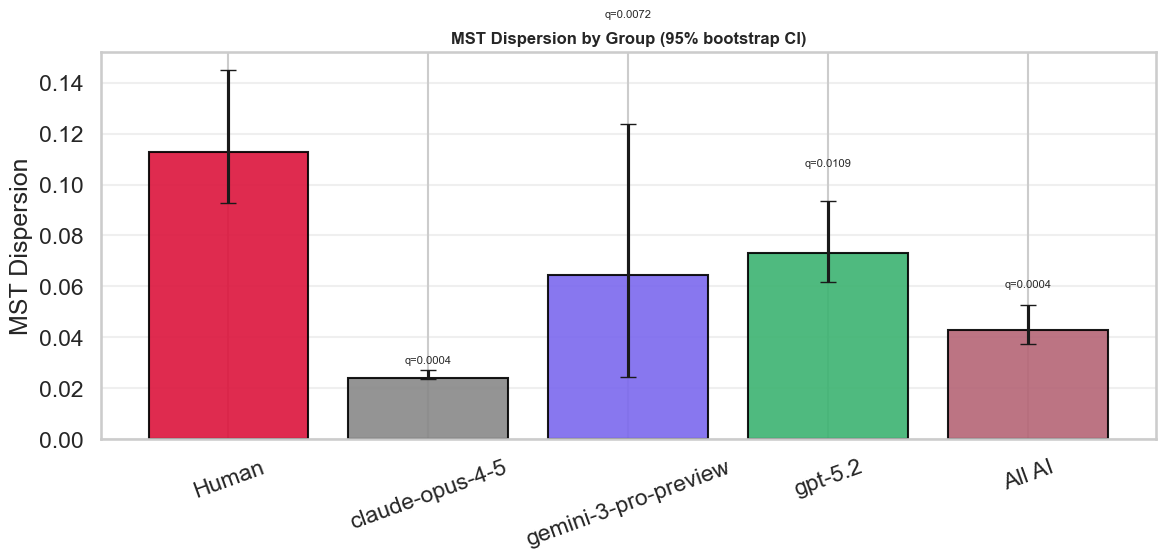

Saved figure: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/diversity_mst_dispersion.png

Permutation tests (MST, Human contrasts):
                   comparison  obs_diff  perm_p_value  perm_p_value_adj_holm
     claude-opus-4-5 vs Human -0.088450      0.000100               0.000400
              All AI vs Human -0.069875      0.000100               0.000400
gemini-3-pro-preview vs Human -0.048239      0.003600               0.007199
             gpt-5.2 vs Human -0.039332      0.010899               0.010899


In [126]:

# Visualization + test summary: Analysis 1.2c
print('='*85)
print('VISUALIZATION: 1.2c MST DISPERSION')
print('='*85)

if 'mst_group_summary_df' not in globals():
    raise RuntimeError('mst_group_summary_df missing. Run Analysis 1.2c cell first.')

order = ['Human'] + [m for m in ai_models if m in set(mst_group_summary_df['group'])] + ['All AI']
plot_df = mst_group_summary_df.set_index('group').reindex(order).reset_index()
colors_plot = [colors.get(g, '#888888') if g != 'All AI' else '#B56576' for g in plot_df['group']]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

y = plot_df['mst_dispersion'].to_numpy(dtype=float)
lo = plot_df['mst_boot_ci_low'].to_numpy(dtype=float)
hi = plot_df['mst_boot_ci_high'].to_numpy(dtype=float)
yerr = np.vstack([y - lo, hi - y])

bars = ax.bar(
    np.arange(len(plot_df)), y,
    yerr=yerr,
    capsize=6,
    color=colors_plot,
    edgecolor='black',
    alpha=0.9,
)

ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(plot_df['group'].tolist(), rotation=20)
ax.set_ylabel('MST Dispersion')
ax.set_title('MST Dispersion by Group (95% bootstrap CI)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

if 'mst_pairwise_perm_df' in globals() and len(mst_pairwise_perm_df):
    perm = mst_pairwise_perm_df.copy()
    q_col = 'perm_p_value_adj_holm' if 'perm_p_value_adj_holm' in perm.columns else 'perm_p_value'
    for i, g in enumerate(plot_df['group']):
        if g in ('Human',):
            continue
        r = perm.loc[perm['group1'] == g]
        if len(r):
            qv = float(r.iloc[0][q_col])
            txt = f'q={qv:.3g}'
            ax.text(i, y[i] + (hi[i]-lo[i]) + 0.001, txt, ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig_path = FIGURES_DIR / 'diversity_mst_dispersion.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved figure: {fig_path}')

if 'mst_pairwise_perm_df' in globals() and len(mst_pairwise_perm_df):
    disp_cols = ['comparison', 'obs_diff', 'perm_p_value']
    if 'perm_p_value_adj_holm' in mst_pairwise_perm_df.columns:
        disp_cols.append('perm_p_value_adj_holm')
    print('\nPermutation tests (MST, Human contrasts):')
    print(mst_pairwise_perm_df[disp_cols].sort_values(disp_cols[-1]).to_string(index=False))


## Analysis 1.2d: Sparseness (Medoid-Based Dispersion)

In [127]:

print('='*85)
print('ANALYSIS 1.2d: SPARSENESS (MEDOID-BASED)')
print('='*85)

rows = []
sum_rows = []
for g, gc in group_cache.items():
    idx = gc['idx']
    Dg = gc['D']
    md = proposal_medoid_distances(Dg)
    sp = group_sparseness(Dg)
    for pos, pid in enumerate(idx):
        rows.append({
            'proposal_uid': proposal_meta.loc[pid, 'proposal_uid'],
            'title': proposal_meta.loc[pid, 'title'],
            'group_model': proposal_meta.loc[pid, 'group_model'],
            'group_binary': proposal_meta.loc[pid, 'group_binary'],
            'medoid_dist': float(md[pos]),
        })
    sum_rows.append({'group': g, 'n': gc['n'], 'sparseness': sp})

medoid_proposal_df = pd.DataFrame(rows)
sparseness_group_summary_df = pd.DataFrame(sum_rows)

tests = []
human_vals = medoid_proposal_df.loc[medoid_proposal_df['group_binary']=='Human', 'medoid_dist'].to_numpy()
for g in ['All AI'] + ai_models:
    vals = medoid_proposal_df.loc[(medoid_proposal_df['group_binary']=='AI') if g=='All AI' else (medoid_proposal_df['group_model']==g), 'medoid_dist'].to_numpy()
    if len(vals)==0:
        continue
    r = run_group_comparison(vals, human_vals, n_permutations=10000, n_boot=5000, random_state=42)
    r.update({'comparison': f'{g} vs Human', 'group1': g, 'group2': 'Human', 'n_group1': len(vals), 'n_group2': len(human_vals)})
    tests.append(r)

sparseness_tests_df = pd.DataFrame(tests)
if len(sparseness_tests_df):
    sparseness_tests_df = apply_multiple_testing(sparseness_tests_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')

medoid_proposal_df.to_csv(TABLES_DIR / 'diversity_medoid_distances.csv', index=False)
sparseness_group_summary_df.to_csv(TABLES_DIR / 'diversity_sparseness_group_summary.csv', index=False)
sparseness_tests_df.to_csv(TABLES_DIR / 'diversity_sparseness_pairwise_tests.csv', index=False)
print('Saved diversity_medoid_distances.csv, diversity_sparseness_group_summary.csv, diversity_sparseness_pairwise_tests.csv')


ANALYSIS 1.2d: SPARSENESS (MEDOID-BASED)
Saved diversity_medoid_distances.csv, diversity_sparseness_group_summary.csv, diversity_sparseness_pairwise_tests.csv


VISUALIZATION: 1.2d SPARSENESS (MEDOID-BASED)


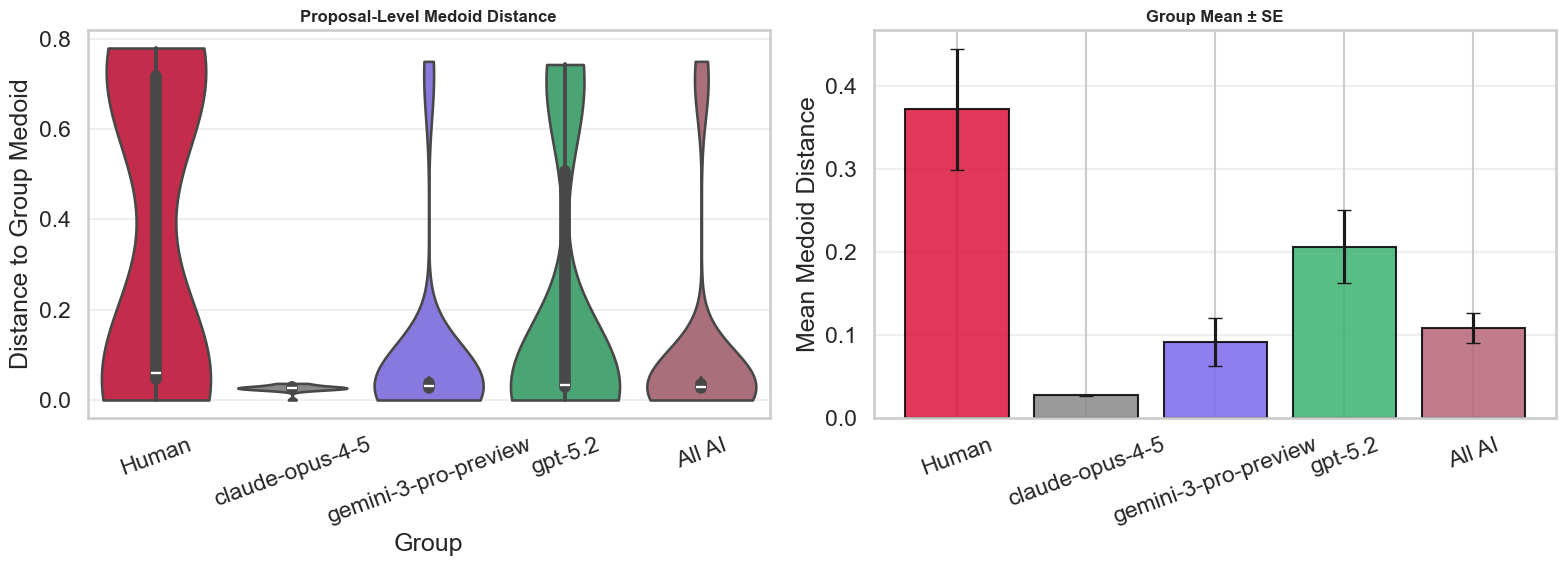

Saved figure: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/diversity_sparseness_medoid.png

Pairwise tests vs Human (Holm-adjusted):
                   comparison  obs_diff_mean     delta   p_value_mw  p_value_mw_adj_holm  p_value_perm  p_value_perm_adj_holm
     claude-opus-4-5 vs Human      -0.345396 -0.914934 7.460656e-10         2.984262e-09      0.000100               0.000400
              All AI vs Human      -0.263994 -0.758034 6.271430e-09         1.881429e-08      0.000100               0.000400
gemini-3-pro-preview vs Human      -0.280960 -0.764650 2.709390e-07         5.418779e-07      0.000100               0.000400
             gpt-5.2 vs Human      -0.165626 -0.594518 6.415470e-05         6.415470e-05      0.040896               0.040896


In [128]:

# Visualization + test summary: Analysis 1.2d
print('='*85)
print('VISUALIZATION: 1.2d SPARSENESS (MEDOID-BASED)')
print('='*85)

if 'medoid_proposal_df' not in globals():
    raise RuntimeError('medoid_proposal_df missing. Run Analysis 1.2d cell first.')

plot_df = medoid_proposal_df[['group_model', 'group_binary', 'medoid_dist']].copy()
plot_df['group_plot'] = plot_df['group_model']
all_ai_df = plot_df.loc[plot_df['group_binary'] == 'AI'].copy()
all_ai_df['group_plot'] = 'All AI'
plot_df = pd.concat([plot_df, all_ai_df], ignore_index=True)

group_order_plot = ['Human'] + [m for m in ai_models if m in set(plot_df['group_plot'])] + ['All AI']
palette = [colors.get(g, '#888888') if g != 'All AI' else '#B56576' for g in group_order_plot]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(
    data=plot_df, x='group_plot', y='medoid_dist',
    order=group_order_plot, palette=palette, inner='box', cut=0, ax=axes[0]
)
axes[0].set_title('Proposal-Level Medoid Distance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Distance to Group Medoid')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

summary_plot = (
    plot_df.groupby('group_plot')['medoid_dist']
    .agg(['mean', 'std', 'count'])
    .reindex(group_order_plot)
)
se = summary_plot['std'] / np.sqrt(summary_plot['count'].clip(lower=1))
axes[1].bar(
    np.arange(len(group_order_plot)),
    summary_plot['mean'].values,
    yerr=se.values,
    capsize=5,
    color=palette,
    edgecolor='black',
    alpha=0.85,
)
axes[1].set_xticks(np.arange(len(group_order_plot)))
axes[1].set_xticklabels(group_order_plot, rotation=20)
axes[1].set_title('Group Mean ± SE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Medoid Distance')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
fig_path = FIGURES_DIR / 'diversity_sparseness_medoid.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved figure: {fig_path}')

if 'sparseness_tests_df' in globals() and len(sparseness_tests_df):
    cols = [
        'comparison', 'obs_diff_mean', 'delta',
        'p_value_mw', 'p_value_mw_adj_holm', 'p_value_perm', 'p_value_perm_adj_holm'
    ]
    for c in cols:
        if c not in sparseness_tests_df.columns:
            sparseness_tests_df[c] = np.nan
    print('\nPairwise tests vs Human (Holm-adjusted):')
    print(sparseness_tests_df[cols].sort_values('p_value_mw_adj_holm').to_string(index=False))


## Analysis 1.3: Nearest-Neighbor Isolation and Outlier Detection (Chamfer / NN)

Compute global 1-NN isolation, pooled outlier flags, and exact within-group Chamfer summaries.

In [129]:

print('='*85)
print('ANALYSIS 1.3: GLOBAL NN ISOLATION + CHAMFER')
print('='*85)

n_human = int((proposal_meta['group_binary'] == 'Human').sum())
n_ai = int((proposal_meta['group_binary'] == 'AI').sum())
labels = proposal_meta['group_model'].to_numpy()
ai_models_local = sorted(proposal_meta.loc[proposal_meta['group_binary']=='AI', 'group_model'].unique().tolist())

all_distances = D_pp_infdiag.copy()
nn_idx = np.argmin(all_distances, axis=1)
nn_dist = np.min(all_distances, axis=1)

nn_distances = nn_dist
nn_dist_global = nn_dist
nn_indices = nn_idx
nn_labels = labels[nn_idx]

outliers, nn_outlier_threshold = flag_top_percentile(nn_distances, pct=90, strict=True)
threshold = nn_outlier_threshold  # backward compatibility

# global mean-5NN for unified output/backward compatibility (no separate section)
k5 = min(5, D_pp.shape[0]-1)
mean_knn_dist = np.partition(D_pp_infdiag, kth=k5-1, axis=1)[:, :k5].mean(axis=1)
outliers_mean_knn, mean5nn_threshold = flag_top_percentile(mean_knn_dist, pct=90, strict=True)

human_nn_dists = nn_distances[proposal_meta['group_binary'].to_numpy() == 'Human']
ai_nn_dists = nn_distances[proposal_meta['group_binary'].to_numpy() == 'AI']
model_nn_dists = {m: nn_distances[labels == m] for m in ai_models_local}

# proposal-level table
nn_proposal_df = proposal_meta[['proposal_uid', 'title', 'group_model', 'group_binary']].copy()
nn_proposal_df['nn_dist_global'] = nn_distances
nn_proposal_df['nn_neighbor_proposal_uid'] = proposal_meta.loc[nn_indices, 'proposal_uid'].to_numpy()
nn_proposal_df['nn_neighbor_group_model'] = proposal_meta.loc[nn_indices, 'group_model'].to_numpy()
nn_proposal_df['is_nn_outlier'] = outliers.astype(bool)

# chamfer summary
chamfer_rows = []
for g, gc in group_cache.items():
    chamfer_rows.append({'group': g, 'n': gc['n'], 'chamfer': group_chamfer(gc['D'])})
chamfer_group_summary_df = pd.DataFrame(chamfer_rows)

# tests on proposal-level nn_dist_global
tests = []
human_vals = nn_proposal_df.loc[nn_proposal_df['group_binary']=='Human', 'nn_dist_global'].to_numpy()
for g in ['All AI'] + ai_models_local:
    vals = nn_proposal_df.loc[(nn_proposal_df['group_binary']=='AI') if g=='All AI' else (nn_proposal_df['group_model']==g), 'nn_dist_global'].to_numpy()
    if len(vals)==0:
        continue
    r = run_group_comparison(vals, human_vals, n_permutations=10000, n_boot=5000, random_state=42)
    r.update({'comparison': f'{g} vs Human', 'group1': g, 'group2': 'Human', 'n_group1': len(vals), 'n_group2': len(human_vals)})
    tests.append(r)

nn_tests_df = pd.DataFrame(tests)
if len(nn_tests_df):
    nn_tests_df = apply_multiple_testing(nn_tests_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')

# source composition
rows = []
for g in ['Human'] + ai_models_local + ['All AI']:
    mask = (nn_proposal_df['group_binary']=='AI').to_numpy() if g=='All AI' else (labels==g)
    if mask.sum()==0:
        continue
    neigh = nn_proposal_df.loc[mask, 'nn_neighbor_group_model'].to_numpy()
    rows.append({
        'group': g,
        'n': int(mask.sum()),
        'nn_from_human': int(np.sum(neigh == 'Human')),
        'nn_from_same_group': int(np.sum(neigh == g)) if g != 'All AI' else int(np.sum(neigh != 'Human')),
        'nn_from_other_ai': int(np.sum((neigh != 'Human') & (neigh != g))) if g not in ['Human','All AI'] else np.nan,
    })
nn_source_composition_df = pd.DataFrame(rows)

# legacy export with threshold column
nn_export_df = nn_proposal_df.rename(columns={'group_model': 'group', 'nn_dist_global': 'nn_dist', 'is_nn_outlier': 'is_outlier'})
nn_export_df['threshold'] = nn_outlier_threshold
nn_export_df.to_csv(TABLES_DIR / 'nn_distances.csv', index=False)

# mean-5NN export
mean5_df = proposal_meta[['proposal_uid', 'title', 'group_model', 'group_binary']].copy()
mean5_df['mean_5nn_dist_global'] = mean_knn_dist
mean5_df['is_mean5nn_outlier'] = outliers_mean_knn.astype(bool)
mean5_df['threshold_mean5nn'] = mean5nn_threshold
mean5_df.to_csv(TABLES_DIR / 'mean_knn_distances_k5.csv', index=False)

chamfer_group_summary_df.to_csv(TABLES_DIR / 'diversity_chamfer_group_summary.csv', index=False)
nn_source_composition_df.to_csv(TABLES_DIR / 'nearest_neighbor_source_composition.csv', index=False)
nn_tests_df.to_csv(TABLES_DIR / 'diversity_nn_pairwise_tests.csv', index=False)

print('Saved nn_distances.csv, mean_knn_distances_k5.csv, diversity_chamfer_group_summary.csv, nearest_neighbor_source_composition.csv, diversity_nn_pairwise_tests.csv')


ANALYSIS 1.3: GLOBAL NN ISOLATION + CHAMFER
Saved nn_distances.csv, mean_knn_distances_k5.csv, diversity_chamfer_group_summary.csv, nearest_neighbor_source_composition.csv, diversity_nn_pairwise_tests.csv


In [130]:
import numpy as np
import pandas as pd

print("\n" + "="*85)
print("UNADJUSTED NN OUTLIERS: TITLES + AUTHOR")
print("="*85)

required = ['outliers', 'threshold', 'n_human']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"⚠️ Missing variables: {missing}")
    print("Run the unadjusted NN + outlier detection cells first.")
else:
    outlier_indices = np.where(outliers)[0]
    n_total = int(len(outliers))
    n_ai = int(n_total - n_human)

    # NN distances (unadjusted)
    nn_d = np.asarray(nn_distances) if 'nn_distances' in globals() else None

    # Prefer metadata saved alongside embeddings (aligned with embedding order)
    use_meta = ('ai_metadata' in globals()) and ('human_metadata' in globals())
    if use_meta:
        if len(human_metadata) != n_human or len(ai_metadata) != n_ai:
            print("⚠️ Metadata lengths do not match embedding counts; falling back to df lookup.")
            use_meta = False

    rows = []
    for idx in outlier_indices:
        if idx < n_human:
            who = 'Human'
            model = 'Human'
            if use_meta:
                rec = human_metadata[idx]
                title = rec.get('proposal_title', rec.get('title', ''))
            else:
                title = human_df.iloc[idx].get('proposal_title', human_df.iloc[idx].get('title', '')) if 'human_df' in globals() else ''
        else:
            ai_idx = int(idx - n_human)
            who = 'AI'
            if use_meta:
                rec = ai_metadata[ai_idx]
                model = str(rec.get('model', 'AI'))
                title = str(rec.get('title', ''))
            else:
                model = str(ai_df.iloc[ai_idx].get('model', 'AI')) if 'ai_df' in globals() else 'AI'
                title = str(ai_df.iloc[ai_idx].get('title', '')) if 'ai_df' in globals() else ''

        rows.append({
            'global_index': int(idx),
            'who': who,
            'model': model,
            'nn_distance': float(nn_d[idx]) if nn_d is not None else np.nan,
            'title': title
        })

    out_df = pd.DataFrame(rows).sort_values('nn_distance', ascending=False)

    print(f"Outlier threshold (90th percentile): {threshold:.4f}")
    print(f"Total outliers: {len(out_df)} / {n_total} ({len(out_df)/n_total*100:.1f}%)")
    print("Outliers by source (model):")
    print(out_df['model'].value_counts().to_string())

    with pd.option_context('display.max_colwidth', 140):
        display(out_df.reset_index(drop=True))



UNADJUSTED NN OUTLIERS: TITLES + AUTHOR
Outlier threshold (90th percentile): 0.0984
Total outliers: 10 / 92 (10.9%)
Outliers by source (model):
model
Human                   7
gpt-5.2                 2
gemini-3-pro-preview    1


,global_index,who,model,nn_distance,title
0,10,Human,Human,0.213483,Searching the crosslinking mass spectrometry universe for new protein-protein interactions
1,2,Human,Human,0.208652,MaiTool - LLM-powered bioinformatics tools for microbiome analysis
2,62,AI,gemini-3-pro-preview,0.185394,Synthesizing the Emergent Assembly of Bacterial Microcompartments
3,22,Human,Human,0.143340,Discovery and functional analysis of bacterial organelles through mining and refinement of omics data
4,11,Human,Human,0.129598,Intelligent metadata compilation to enhance the reusability and discoverability of mass spectrometry-based proteomics data
5,12,Human,Human,0.126132,Emergent Order Parameters of Allostery: An AI Framework for Predicting and Engineering Protein Regulation
6,16,Human,Human,0.122488,Integrative Multi-Omics Synthesis to Identify Shared Molecular Mechanisms of Mammalian Hibernation
7,27,AI,gpt-5.2,0.112855,"A Unified Synthesis of Protein Complex Stoichiometry and Assembly Pathways from Structural, Proteomic, and Ribosome Profiling Data"
8,19,Human,Human,0.101988,A Unified Framework for Analyses of Proteome Turnover Dynamics
9,35,AI,gpt-5.2,0.099729,"Emergent Properties of Membrane Microdomains: Integrating Lipidomics, Proteomics, and Super-Resolution Imaging of Raft-Like Assemblies"


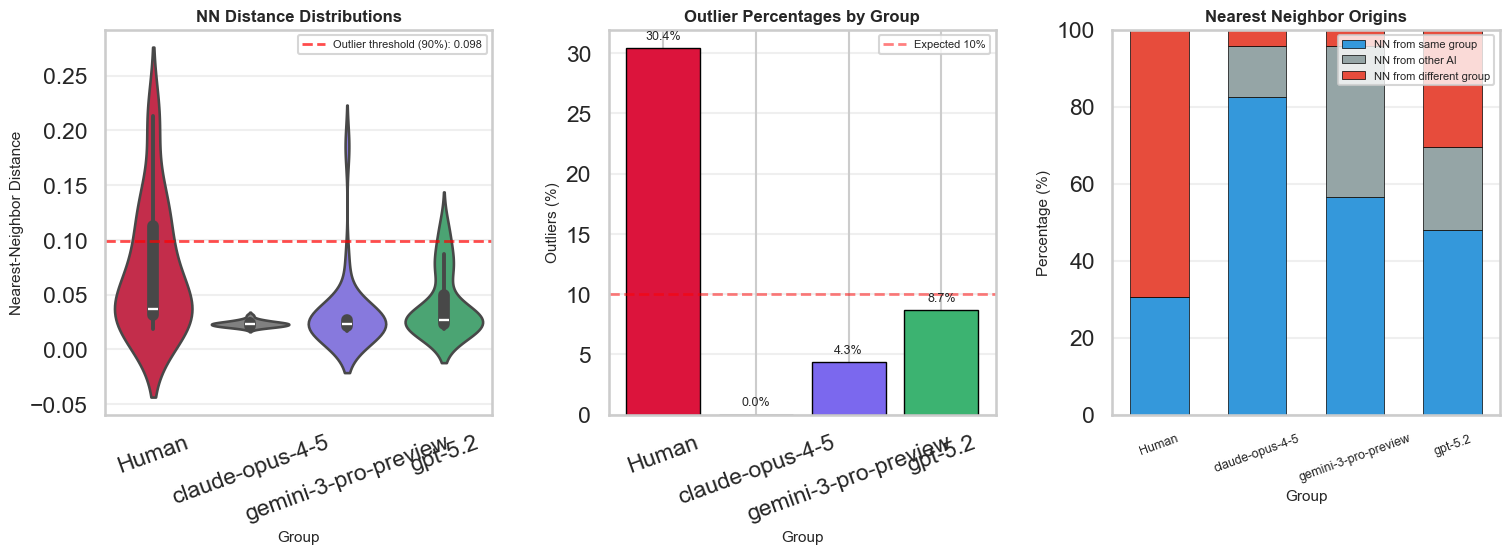

✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/nearest_neighbor_by_model.png


In [131]:
# Visualization: Nearest-neighbor analysis by group (self-contained)
# This cell rebuilds required summary variables from nn_proposal_df/proposal_meta
# so it does not depend on legacy intermediate variable names.

if 'nn_proposal_df' not in globals():
    raise RuntimeError('nn_proposal_df is missing. Run Analysis 1.3 NN cell first.')
if 'proposal_meta' not in globals():
    raise RuntimeError('proposal_meta is missing. Run shared precompute cells first.')

# Canonical group ordering for plotting
ai_models_plot = sorted(proposal_meta.loc[proposal_meta['group_binary']=='AI', 'group_model'].dropna().unique().tolist())
group_order = ['Human'] + [m for m in ai_models_plot if m in set(nn_proposal_df['group_model'])]

# Robust threshold fallback
if 'nn_outlier_threshold' in globals():
    threshold_plot = float(nn_outlier_threshold)
elif 'threshold' in globals():
    threshold_plot = float(threshold)
else:
    threshold_plot = float(np.percentile(nn_proposal_df['nn_dist_global'].to_numpy(), 90))

# Recompute all variables this visualization needs
nn_work = nn_proposal_df.copy()
nn_work['is_nn_outlier'] = nn_work['is_nn_outlier'].astype(bool)

n_human = int((proposal_meta['group_binary'] == 'Human').sum())
human_outliers = int(nn_work.loc[nn_work['group_binary']=='Human', 'is_nn_outlier'].sum())

model_outliers = {
    m: int(nn_work.loc[nn_work['group_model']==m, 'is_nn_outlier'].sum())
    for m in ai_models_plot
}

human_nn_same_group = int((nn_work.loc[nn_work['group_binary']=='Human', 'nn_neighbor_group_model'] == 'Human').sum())
human_nn_diff_group = int((nn_work['group_binary']=='Human').sum() - human_nn_same_group)

model_nn_analysis = {}
for model in ai_models_plot:
    dfm = nn_work.loc[nn_work['group_model'] == model]
    total = int(len(dfm))
    if total == 0:
        continue
    from_human = int((dfm['nn_neighbor_group_model'] == 'Human').sum())
    from_same_model = int((dfm['nn_neighbor_group_model'] == model).sum())
    from_other_ai = int(total - from_human - from_same_model)
    model_nn_analysis[model] = {
        'from_human': from_human,
        'from_same_model': from_same_model,
        'from_other_ai': from_other_ai,
        'total': total,
    }

# NN distributions used in panel 1
human_nn_dists = nn_work.loc[nn_work['group_binary']=='Human', 'nn_dist_global'].to_numpy()
model_nn_dists = {
    m: nn_work.loc[nn_work['group_model']==m, 'nn_dist_global'].to_numpy()
    for m in ai_models_plot
}

fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# 1. NN distance distributions by group
ax1 = fig.add_subplot(gs[0, 0])
nn_data = []
for dist, label in [(human_nn_dists, 'Human')] + [(model_nn_dists[m], m) for m in ai_models_plot if m in model_nn_dists]:
    for val in dist:
        nn_data.append({'NN Distance': val, 'Group': label})

nn_df = pd.DataFrame(nn_data)
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list, order=group_order)
ax1.axhline(threshold_plot, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold_plot:.3f}')
ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
ax1.set_xlabel('Group', fontsize=11)
ax1.set_title('NN Distance Distributions', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# 2. Outlier counts by group
ax2 = fig.add_subplot(gs[0, 1])
outlier_data = []
outlier_data.append({'Group': 'Human', 'Outliers': human_outliers, 'Total': n_human, 'Percentage': human_outliers/max(n_human,1)*100})

for model in ai_models_plot:
    if model in model_outliers:
        n_model = int((proposal_meta['group_model'] == model).sum())
        outlier_data.append({
            'Group': model,
            'Outliers': model_outliers[model],
            'Total': n_model,
            'Percentage': model_outliers[model]/max(n_model,1)*100,
        })

outlier_df = pd.DataFrame(outlier_data)
bars = ax2.bar(
    outlier_df['Group'],
    outlier_df['Percentage'],
    color=[colors.get(g, 'gray') for g in outlier_df['Group']],
    edgecolor='black',
    linewidth=1,
)
ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
ax2.set_ylabel('Outliers (%)', fontsize=11)
ax2.set_xlabel('Group', fontsize=11)
ax2.set_title('Outlier Percentages by Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=20)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

for bar, pct in zip(bars, outlier_df['Percentage']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# 3. NN Group Analysis - Stacked bar chart
ax3 = fig.add_subplot(gs[0, 2])

groups = ['Human'] + [m for m in ai_models_plot if m in model_nn_analysis]
nn_from_human_pcts = [human_nn_diff_group/max(n_human,1)*100]   # For human, NN from AI
nn_from_same_pcts = [human_nn_same_group/max(n_human,1)*100]     # For human, NN from human
nn_from_other_ai_pcts = [0]

for model in [m for m in ai_models_plot if m in model_nn_analysis]:
    data = model_nn_analysis[model]
    nn_from_human_pcts.append(data['from_human']/max(data['total'],1)*100)
    nn_from_same_pcts.append(data['from_same_model']/max(data['total'],1)*100)
    nn_from_other_ai_pcts.append(data['from_other_ai']/max(data['total'],1)*100)

x_pos = np.arange(len(groups))
width = 0.6

ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax3.set_ylabel('Percentage (%)', fontsize=11)
ax3.set_xlabel('Group', fontsize=11)
ax3.set_title('Nearest Neighbor Origins', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(groups, rotation=20, fontsize=9)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(alpha=0.3, axis='y')
ax3.set_ylim([0, 100])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nearest_neighbor_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Figure saved to: {FIGURES_DIR / "nearest_neighbor_by_model.png"}')

## 1.4 Visualize proposals in Embedding Space V

Visualize all proposals in 2D space using UMAP dimensionality reduction to see:
- **Clustering patterns**: How proposals group together
- **Outliers**: Unique proposals far from others (highlighted in magenta)
- **Group separation**: How Human vs AI proposals distribute in semantic space
- **Model characteristics**: Whether different AI models produce distinctly clustered proposals

**Color coding**: Human proposals in bright red for easy identification, AI models in muted colors. A complementary t-SNE view follows in the next cell.



VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE (REVIEW-AWARE)

Reducing embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


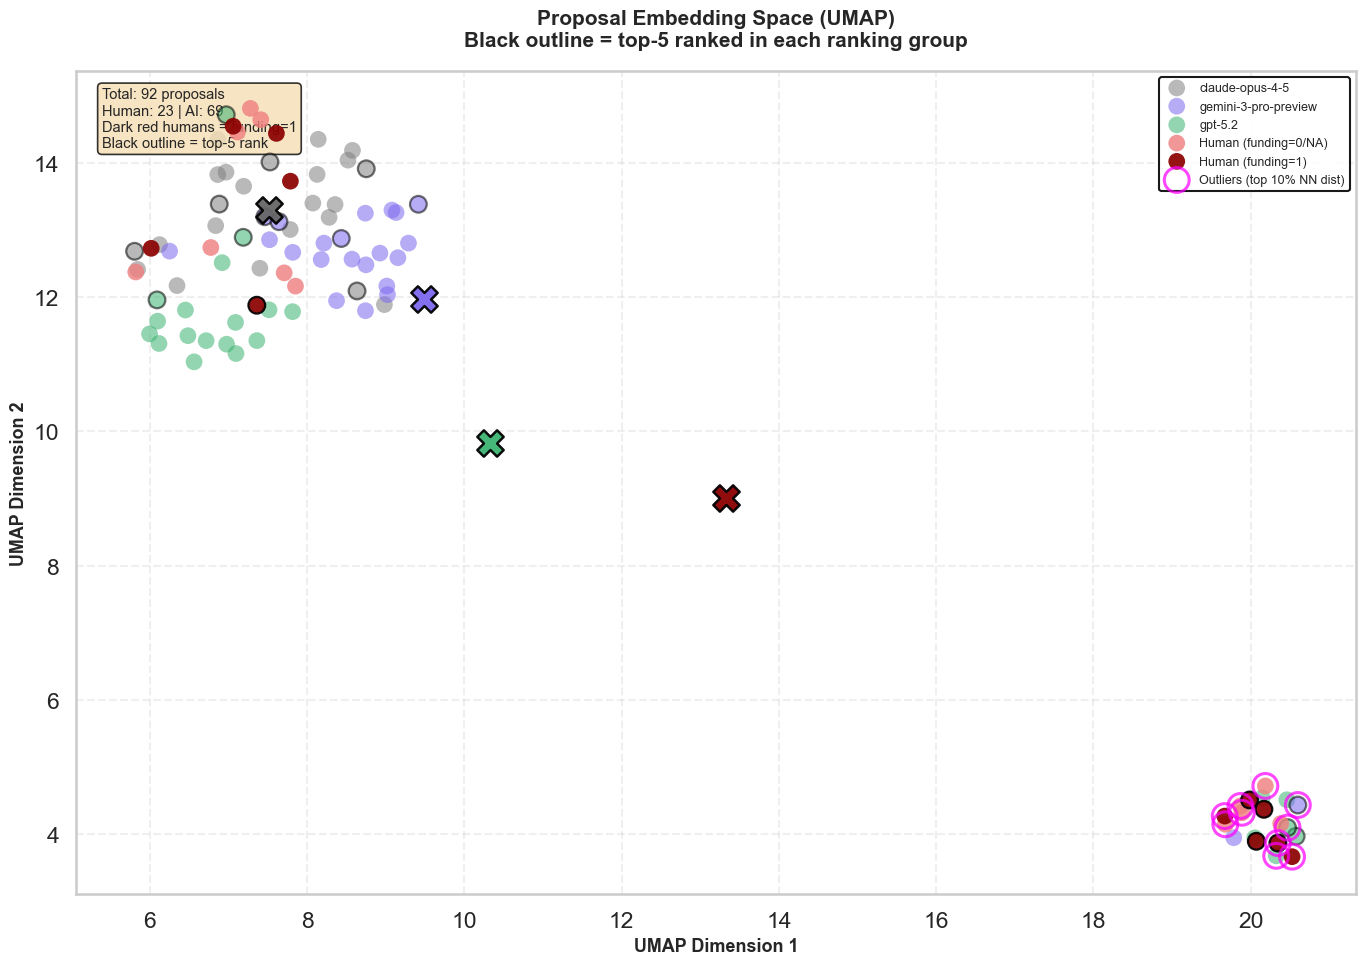


✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/embedding_space_umap_2d.png
✓ Human color shade now uses funding (1=dark red)
✓ Marker size is constant; top-5 ranked proposals get black outline


In [132]:

print("\n" + "="*85)
print("VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE (REVIEW-AWARE)")
print("="*85)

print("\nReducing embeddings to 2D using UMAP...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d = reducer.fit_transform(X_prop)
labels_umap = proposal_meta['group_model'].to_numpy()
funding = pd.to_numeric(proposal_meta['funding'], errors='coerce').to_numpy()
marker_sizes = proposal_meta['viz_marker_size'].to_numpy()
top5_mask = proposal_meta['is_top5_ranked'].fillna(False).to_numpy(dtype=bool)

human_mask = proposal_meta['group_binary'].eq('Human').to_numpy()
ai_mask = ~human_mask
ai_models_local = sorted(proposal_meta.loc[proposal_meta['group_binary']=='AI', 'group_model'].unique().tolist())

print(f"✓ UMAP completed: {len(embeddings_2d)} proposals reduced to 2D")

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

def _scatter_with_top5_outline(mask, color, label, alpha=0.6, zorder=3):
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return
    m_other = mask & (~top5_mask)
    m_top = mask & top5_mask
    if m_other.any():
        pts = embeddings_2d[m_other]
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=color, label=label,
            s=marker_sizes[m_other], alpha=alpha,
            edgecolors='none', linewidth=0, zorder=zorder,
        )
    if m_top.any():
        pts = embeddings_2d[m_top]
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=color, label=(label if not m_other.any() else None),
            s=marker_sizes[m_top], alpha=alpha,
            edgecolors='black', linewidth=1.6, zorder=zorder + 0.1,
        )

# AI proposals by model
for model in ai_models_local:
    model_mask = labels_umap == model
    _scatter_with_top5_outline(model_mask, colors.get(model, '#808080'), model, alpha=0.55, zorder=3)

# Human proposals with funding-dependent shade
human_funded = human_mask & np.isfinite(funding) & (funding == 1)
human_nonfunded = human_mask & (~human_funded)

_scatter_with_top5_outline(human_nonfunded, '#F08080', 'Human (funding=0/NA)', alpha=0.82, zorder=10)
_scatter_with_top5_outline(human_funded, '#8B0000', 'Human (funding=1)', alpha=0.92, zorder=11)

# Highlight outliers with rings
outlier_indices = np.where(outliers)[0]
outlier_coords = embeddings_2d[outlier_indices]
ax.scatter(
    outlier_coords[:, 0], outlier_coords[:, 1],
    s=np.maximum(marker_sizes[outlier_indices] + 160, 320),
    facecolors='none',
    edgecolors='magenta',
    linewidth=2.2,
    alpha=0.72,
    label='Outliers (top 10% NN dist)',
    zorder=13,
)

# Group centroids
for g in ['Human'] + ai_models_local:
    mask = labels_umap == g
    if mask.any():
        c2d = embeddings_2d[mask].mean(axis=0)
        ax.scatter(
            c2d[0], c2d[1],
            c=colors.get(g, '#666666') if g != 'Human' else '#8B0000',
            s=360,
            marker='X',
            edgecolors='black',
            linewidth=1.8,
            alpha=0.95,
            zorder=15,
        )

ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax.set_title('Proposal Embedding Space (UMAP)\nBlack outline = top-5 ranked in each ranking group', fontsize=15, fontweight='bold', pad=18)
ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')
ax.grid(True, alpha=0.3, linestyle='--')

textstr = (
    f"Total: {len(embeddings_2d)} proposals\n"
    f"Human: {int(human_mask.sum())} | AI: {int(ai_mask.sum())}\n"
    f"Dark red humans = funding=1\n"
    f"Black outline = top-5 rank"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.2)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10.5, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'embedding_space_umap_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to: {FIGURES_DIR / 'embedding_space_umap_2d.png'}")
print("✓ Human color shade now uses funding (1=dark red)")
print("✓ Marker size is constant; top-5 ranked proposals get black outline")
print("="*85)



ALTERNATIVE VIEW: t-SNE Projection (metadata-aligned, review-aware)

Reducing embeddings to 2D using t-SNE...
(This may take a minute...)


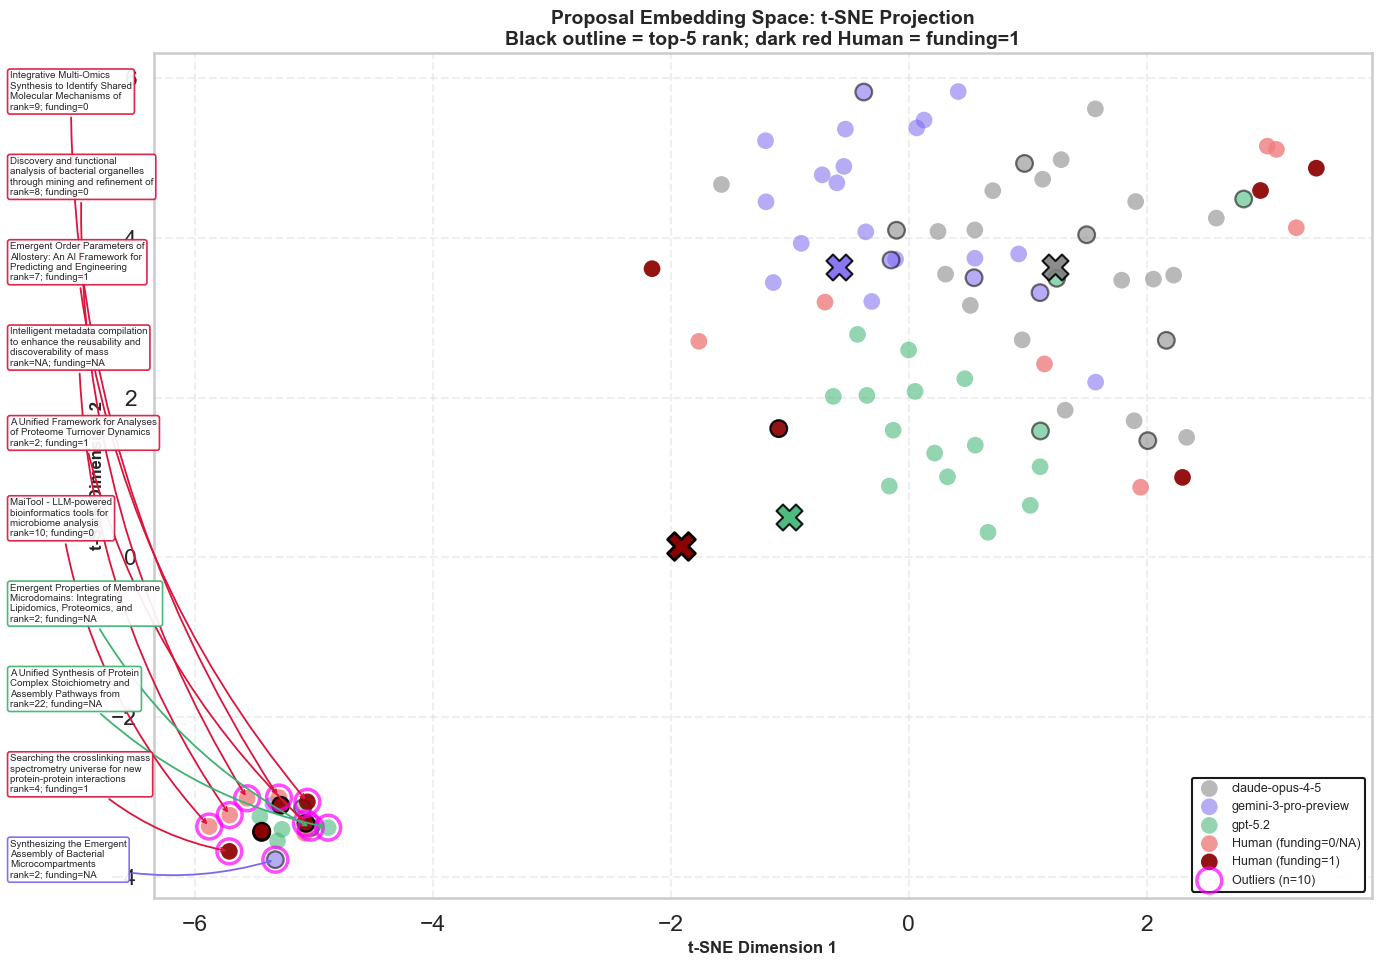


✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/embedding_space_tsne.png
✓ Outlier labels now include title + rank + funding status


In [133]:
# Alternative visualization: t-SNE (complementary to UMAP)
from sklearn.manifold import TSNE

print("\n" + "="*85)
print("ALTERNATIVE VIEW: t-SNE Projection (metadata-aligned, review-aware)")
print("="*85)

# Build labels aligned to embedding order (same approach as UMAP cell)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

n_human_tsne = len(human_embeddings)
labels_tsne = np.array((['Human'] * n_human_tsne) + ai_model_labels)
ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

# Review-aware metadata (already aligned to proposal embedding order via proposal_meta)
if 'proposal_meta' not in globals():
    raise RuntimeError('proposal_meta missing. Run shared precompute cell first.')

labels_prop = proposal_meta['group_model'].to_numpy()
funding = pd.to_numeric(proposal_meta['funding'], errors='coerce').to_numpy()
rank_vals = pd.to_numeric(proposal_meta['viz_rank'], errors='coerce').to_numpy()
top5_mask = proposal_meta['is_top5_ranked'].fillna(False).to_numpy(dtype=bool)
marker_sizes = proposal_meta['viz_marker_size'].to_numpy()

# Apply t-SNE dimensionality reduction
print("\nReducing embeddings to 2D using t-SNE...")
print("(This may take a minute...)")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    metric='cosine',
    random_state=42,
    n_iter=1000,
    verbose=0
)

all_embeddings_tsne = np.asarray(X_prop) if 'X_prop' in globals() else np.vstack([human_embeddings, ai_embeddings])
embeddings_2d_tsne = tsne.fit_transform(all_embeddings_tsne)

if len(embeddings_2d_tsne) != len(proposal_meta):
    raise RuntimeError(f'Count mismatch between t-SNE points ({len(embeddings_2d_tsne)}) and proposal_meta ({len(proposal_meta)}).')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))


def _scatter_with_top5_outline(mask, color, label, alpha=0.6, zorder=3):
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return
    m_other = mask & (~top5_mask)
    m_top = mask & top5_mask
    if m_other.any():
        pts = embeddings_2d_tsne[m_other]
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=color,
            label=label,
            s=marker_sizes[m_other],
            alpha=alpha,
            edgecolors='none',
            linewidth=0,
            zorder=zorder,
        )
    if m_top.any():
        pts = embeddings_2d_tsne[m_top]
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=color,
            label=(label if not m_other.any() else None),
            s=marker_sizes[m_top],
            alpha=alpha,
            edgecolors='black',
            linewidth=1.6,
            zorder=zorder + 0.1,
        )

# AI proposals by model
for model in ai_models_local:
    mask = labels_prop == model
    _scatter_with_top5_outline(mask, colors.get(model, '#808080'), model, alpha=0.55, zorder=3)

# Human proposals by funding shade
human_mask = proposal_meta['group_binary'].eq('Human').to_numpy()
human_funded = human_mask & np.isfinite(funding) & (funding == 1)
human_nonfunded = human_mask & (~human_funded)

_scatter_with_top5_outline(human_nonfunded, '#F08080', 'Human (funding=0/NA)', alpha=0.82, zorder=10)
_scatter_with_top5_outline(human_funded, '#8B0000', 'Human (funding=1)', alpha=0.92, zorder=11)

# Highlight the same outliers (computed from NN distances)
outlier_indices = np.where(outliers)[0]
outlier_coords_plot = embeddings_2d_tsne[outlier_indices]
ax.scatter(outlier_coords_plot[:, 0], outlier_coords_plot[:, 1],
           s=np.maximum(marker_sizes[outlier_indices] + 160, 320),
           facecolors='none',
           edgecolors='magenta',
           linewidth=2.5,
           alpha=0.7,
           label=f'Outliers (n={len(outlier_indices)})',
           zorder=12)

# Build a title lookup aligned to the embedding order (human first, then AI)
all_titles_tsne = []
for r in (human_metadata if 'human_metadata' in globals() else []):
    all_titles_tsne.append(r.get('proposal_title', r.get('title', '')))
for r in (ai_metadata if 'ai_metadata' in globals() else []):
    all_titles_tsne.append(r.get('title', r.get('proposal_title', '')))

# ── Stacked, non-overlapping labels with arrows ───────────────────────────────
# Collect (x, y, title, group, rank, funding) for each outlier, sorted by y (top→bottom)
outlier_info = sorted(
    [(
        embeddings_2d_tsne[idx][0],
        embeddings_2d_tsne[idx][1],
        all_titles_tsne[idx] if idx < len(all_titles_tsne) else '',
        labels_tsne[idx],
        rank_vals[idx] if idx < len(rank_vals) else np.nan,
        funding[idx] if idx < len(funding) else np.nan,
    )
    for idx in outlier_indices],
    key=lambda p: -p[1]
)

# Place label column just past the RIGHT edge of all data
x_data_max = embeddings_2d_tsne[:, 0].max()
x_data_min = embeddings_2d_tsne[:, 0].min()
x_label_col = x_data_min - (x_data_max - x_data_min) * 0.18

# Spread labels evenly across full vertical range
y_data_max = embeddings_2d_tsne[:, 1].max()
y_data_min = embeddings_2d_tsne[:, 1].min()
n_out = len(outlier_info)
y_label_positions = [
    y_data_max - i * (y_data_max - y_data_min) / max(n_out - 1, 1)
    for i in range(n_out)
]


def wrap_title(title, max_chars=32):
    words = title.split()
    lines, line = [], []
    for w in words:
        line.append(w)
        if len(' '.join(line)) > max_chars:
            lines.append(' '.join(line[:-1]))
            line = [w]
    if line:
        lines.append(' '.join(line))
    return '\n'.join(lines[:3])


def format_meta(rank, funding_value):
    if np.isfinite(rank):
        rank_txt = f'rank={int(rank)}'
    else:
        rank_txt = 'rank=NA'

    if np.isfinite(funding_value):
        funding_txt = f'funding={int(funding_value)}'
    else:
        funding_txt = 'funding=NA'

    return f'{rank_txt}; {funding_txt}'

for (px, py, title, grp, rank, funding_value), y_lab in zip(outlier_info, y_label_positions):
    grp_color = colors.get(grp, '#808080')
    label_txt = f"{wrap_title(title)}\n{format_meta(rank, funding_value)}"
    ax.annotate(
        label_txt,
        xy=(px, py),
        xytext=(x_label_col, y_lab),
        fontsize=7,
        verticalalignment='center',
        zorder=20,
        arrowprops=dict(
            arrowstyle='->',
            color=grp_color,
            lw=1.3,
            connectionstyle='arc3,rad=0.15',
        ),
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor=grp_color,
            linewidth=1.2,
            alpha=0.92,
        ),
    )

# Centroids
mask_h = labels_prop == 'Human'
if mask_h.any():
    centroid_h = embeddings_2d_tsne[mask_h].mean(axis=0)
    ax.scatter(centroid_h[0], centroid_h[1],
               c='#8B0000',
               s=400,
               marker='X',
               edgecolors='black',
               linewidth=2,
               alpha=1.0,
               zorder=15)

for model in ai_models_local:
    mask = labels_prop == model
    if mask.any():
        c2d = embeddings_2d_tsne[mask].mean(axis=0)
        ax.scatter(c2d[0], c2d[1],
                   c=colors.get(model, '#808080'),
                   s=350,
                   marker='X',
                   edgecolors='black',
                   linewidth=1.5,
                   alpha=0.9,
                   zorder=14)

ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposal Embedding Space: t-SNE Projection\nBlack outline = top-5 rank; dark red Human = funding=1',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')

plt.tight_layout()
out_path = FIGURES_DIR / 'embedding_space_tsne.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to: {out_path}")
print("✓ Outlier labels now include title + rank + funding status")
print("="*85)


## Analysis 1.5: Grid Entropy of Proposal Occupancy

In [134]:

print('='*85)
print('ANALYSIS 1.5: GRID ENTROPY OF PROPOSAL OCCUPANCY')
print('='*85)

rows = []
for g, idx in GROUPS.items():
    ent_raw = group_grid_entropy(pca_2d, idx, bins=5, normalize=False)
    ent_norm = group_grid_entropy(pca_2d, idx, bins=5, normalize=True)
    rows.append({
        'group': g,
        'n': len(idx),
        'grid_entropy': ent_raw,
        'grid_entropy_normalized': ent_norm,
        'bins': 5,
        'projection_method': 'PCA-2D',
    })

entropy_group_summary_df = pd.DataFrame(rows)
entropy_group_summary_df.to_csv(TABLES_DIR / 'diversity_entropy_group_summary.csv', index=False)
print(entropy_group_summary_df.to_string(index=False))
print('Saved diversity_entropy_group_summary.csv')


ANALYSIS 1.5: GRID ENTROPY OF PROPOSAL OCCUPANCY
               group  n  grid_entropy  grid_entropy_normalized  bins projection_method
               Human 23      1.334082                 0.414456     5            PCA-2D
     claude-opus-4-5 23      2.412210                 0.749395     5            PCA-2D
gemini-3-pro-preview 23      0.730167                 0.226839     5            PCA-2D
             gpt-5.2 23      0.920833                 0.286073     5            PCA-2D
              All AI 69      1.068576                 0.331972     5            PCA-2D
Saved diversity_entropy_group_summary.csv


VISUALIZATION: 1.5 GRID ENTROPY OF PROPOSAL OCCUPANCY


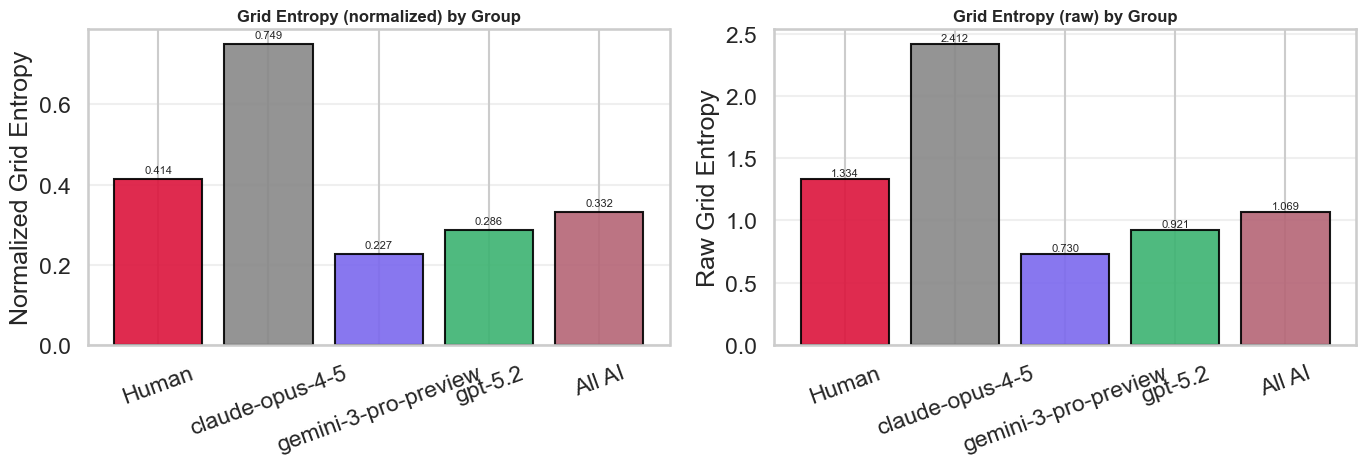

Saved figure: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/diversity_entropy_group_summary.png

Permutation tests (normalized entropy, vs Human):
                   comparison  obs_diff  perm_p_value  perm_p_value_adj_holm
     claude-opus-4-5 vs Human  0.334939      0.002100               0.008399
gemini-3-pro-preview vs Human -0.187617      0.094391               0.283172
             gpt-5.2 vs Human -0.128383      0.228877               0.457754
              All AI vs Human -0.082484      0.473353               0.473353
Saved diversity_entropy_pairwise_permutation.csv


In [135]:

# Visualization + permutation-test summary: Analysis 1.5
print('='*85)
print('VISUALIZATION: 1.5 GRID ENTROPY OF PROPOSAL OCCUPANCY')
print('='*85)

if 'entropy_group_summary_df' not in globals():
    raise RuntimeError('entropy_group_summary_df missing. Run Analysis 1.5 entropy cell first.')

order = ['Human'] + [m for m in ai_models if m in set(entropy_group_summary_df['group'])] + ['All AI']
plot_df = entropy_group_summary_df.set_index('group').reindex(order).reset_index()
palette = [colors.get(g, '#888888') if g != 'All AI' else '#B56576' for g in plot_df['group']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    np.arange(len(plot_df)),
    plot_df['grid_entropy_normalized'].to_numpy(dtype=float),
    color=palette,
    edgecolor='black',
    alpha=0.9,
)
axes[0].set_xticks(np.arange(len(plot_df)))
axes[0].set_xticklabels(plot_df['group'].tolist(), rotation=20)
axes[0].set_ylabel('Normalized Grid Entropy')
axes[0].set_title('Grid Entropy (normalized) by Group', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i,v in enumerate(plot_df['grid_entropy_normalized'].to_numpy(dtype=float)):
    if np.isfinite(v):
        axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

axes[1].bar(
    np.arange(len(plot_df)),
    plot_df['grid_entropy'].to_numpy(dtype=float),
    color=palette,
    edgecolor='black',
    alpha=0.9,
)
axes[1].set_xticks(np.arange(len(plot_df)))
axes[1].set_xticklabels(plot_df['group'].tolist(), rotation=20)
axes[1].set_ylabel('Raw Grid Entropy')
axes[1].set_title('Grid Entropy (raw) by Group', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i,v in enumerate(plot_df['grid_entropy'].to_numpy(dtype=float)):
    if np.isfinite(v):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig_path = FIGURES_DIR / 'diversity_entropy_group_summary.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved figure: {fig_path}')

# Permutation tests: group-level entropy contrasts vs Human

def _entropy_norm_metric(coords_subset):
    return group_grid_entropy(coords_subset, np.arange(len(coords_subset)), bins=5, normalize=True)

rows = []
for g in ai_models + ['All AI']:
    if g not in GROUPS:
        continue
    pt = permutation_test_group_metric(
        pca_2d,
        proposal_meta['group_model'].to_numpy(),
        GROUPS[g],
        GROUPS['Human'],
        _entropy_norm_metric,
        n_perm=10000,
        random_state=42,
        use_distance_submat=False,
    )
    rows.append({
        'comparison': f'{g} vs Human',
        'group1': g,
        'group2': 'Human',
        **pt,
    })

entropy_pairwise_perm_df = pd.DataFrame(rows)
if len(entropy_pairwise_perm_df):
    entropy_pairwise_perm_df = apply_multiple_testing(entropy_pairwise_perm_df, p_cols=('perm_p_value',), method='holm')
entropy_pairwise_perm_df.to_csv(TABLES_DIR / 'diversity_entropy_pairwise_permutation.csv', index=False)

if len(entropy_pairwise_perm_df):
    print('\nPermutation tests (normalized entropy, vs Human):')
    disp_cols = ['comparison', 'obs_diff', 'perm_p_value']
    if 'perm_p_value_adj_holm' in entropy_pairwise_perm_df.columns:
        disp_cols.append('perm_p_value_adj_holm')
    print(entropy_pairwise_perm_df[disp_cols].sort_values(disp_cols[-1]).to_string(index=False))
print('Saved diversity_entropy_pairwise_permutation.csv')


# PART II: NOVELTY

Can AI create more novel proposals than teams of human scientists?

We'll compare how far proposals are from existing literature (PubMed corpus).

## Step 1: Load Prepared Literature Corpus

In [38]:
import json

# Load prepared literature corpus (generated in prepare_data_for_analysis.ipynb)
print('='*85)
print('LOADING PREPARED LITERATURE CORPUS')
print('='*85)

literature_corpus_path = PREPARED_LITERATURE_CORPUS_PATH
if not literature_corpus_path.exists():
    raise FileNotFoundError(
        f'Prepared literature corpus not found at {literature_corpus_path}. '
        'Run prepare_data_for_analysis.ipynb first.'
    )

with open(literature_corpus_path, 'r') as f:
    corpus_data = json.load(f)

articles = corpus_data.get('articles', [])
print(f'\n✓ Loaded {len(articles)} PubMed articles')
print(f'  Search queries: {len(corpus_data.get("search_queries", []))}')
print(f'  Source file: {literature_corpus_path}')

corpus_texts = []
for article in articles:
    title = article.get('title', '')
    abstract = article.get('abstract', '')
    text = f'Title: {title}\n\nAbstract: {abstract}'
    corpus_texts.append(text)

print(f'\n✓ Prepared {len(corpus_texts)} literature texts')
print(f'  Average length: {np.mean([len(t) for t in corpus_texts]):.0f} characters')
print('='*85)


LOADING PREPARED LITERATURE CORPUS

✓ Loaded 39538 PubMed articles
  Search queries: 1
  Source file: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/literature_corpus_prepared.json

✓ Prepared 39538 literature texts
  Average length: 1584 characters


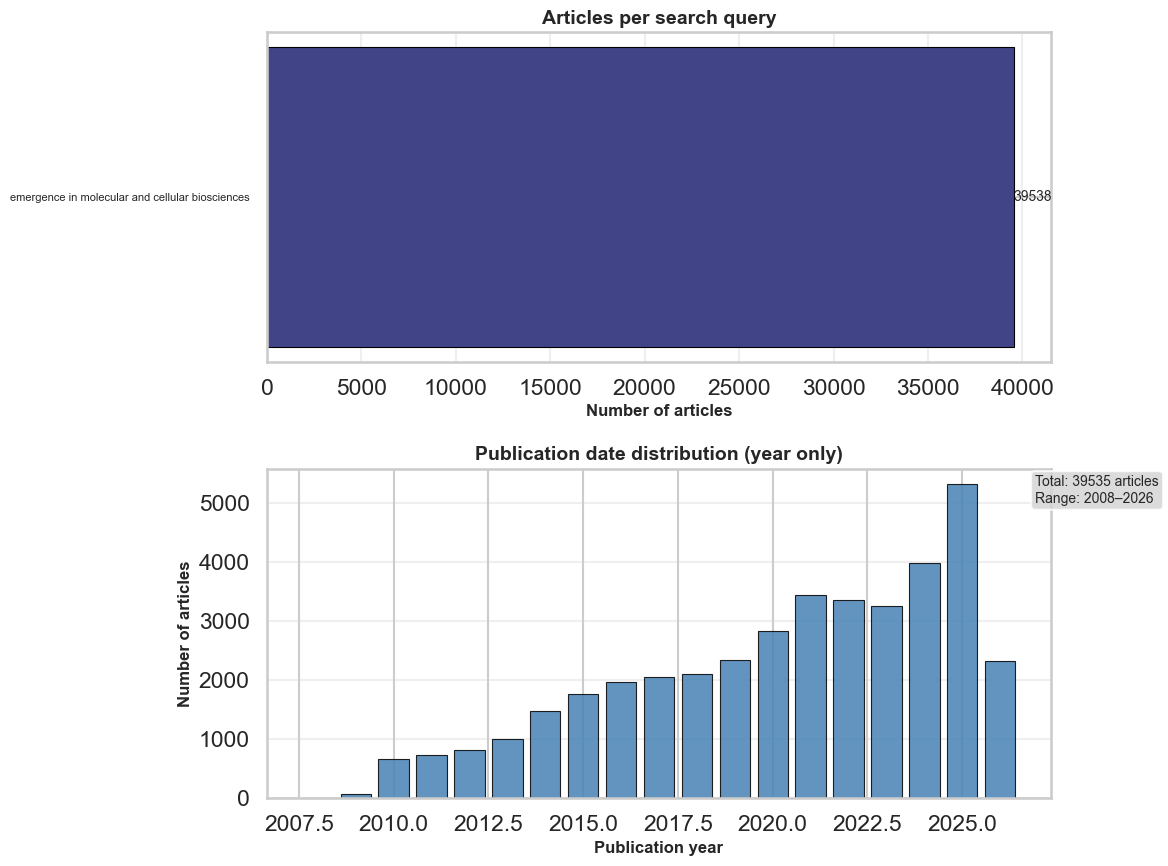

✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/literature_corpus_overview.png

SEARCH TERMS (QUERIES) USED PER CATEGORY

• emergence in molecular and cellular biosciences (n=39538 articles):
  (("emergent properties" OR emergence) AND ("molecular biosciences" OR "cellular biosciences" OR "molecular biology" OR "cell biology"))


In [39]:
# Visualize literature corpus: articles per query + publication year distribution
import re

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# --- Panel 1: Articles per search query ---
ax1 = axes[0]
queries = corpus_data['search_queries']
labels = [q['label'] for q in queries]
counts = [q['new_unique_added'] for q in queries]
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(labels)))
bars = ax1.barh(range(len(labels)), counts, color=colors_bar, edgecolor='black', linewidth=0.8)
ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels, fontsize=8, ha='right')
ax1.set_xlabel('Number of articles', fontsize=12, fontweight='bold')
ax1.set_title('Articles per search query', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
for bar, c in zip(bars, counts):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(c), va='center', fontsize='10')

# --- Panel 2: Publication year distribution ---
ax2 = axes[1]
def parse_year(pub_date):
    if not pub_date or not isinstance(pub_date, str):
        return None
    m = re.match(r'(\d{4})', pub_date.strip())
    return int(m.group(1)) if m else None

years = [parse_year(a.get('publication_date')) for a in articles]
years = [y for y in years if y is not None]
year_counts = pd.Series(years).value_counts().sort_index()

ax2.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.set_xlabel('Publication year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of articles', fontsize=12, fontweight='bold')
ax2.set_title('Publication date distribution (year only)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
if years:
    ax2.text(0.98, 0.98, f'Total: {len(years)} articles\nRange: {min(years)}–{max(years)}', transform=ax2.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'literature_corpus_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to: {FIGURES_DIR / 'literature_corpus_overview.png'}")

# Print search terms (queries) used for each category
print('\n' + '='*85)
print('SEARCH TERMS (QUERIES) USED PER CATEGORY')
print('='*85)
for q in queries:
    print(f"\n• {q['label']} (n={q['new_unique_added']} articles):")
    print(f"  {q['query']}")
print('='*85)

## Step 2: Embed Literature Corpus 

Embed all 350 abstracts using BioLinkBERT-Large (same model used for proposals).

In [40]:
# Embed literature corpus using the same approach (truncated to 512 tokens)
print("="*85)
print("EMBEDDING LITERATURE CORPUS")
print("="*85)
print("Using BioLinkBERT-Large (same as proposals, truncated to 512 tokens)")
print()

# Check if embeddings already exist
literature_embeddings_file = LITERATURE_EMBEDDINGS_FILE

if literature_embeddings_file.exists():
    print(f"✓ Loading cached literature embeddings from {literature_embeddings_file}")
    with open(literature_embeddings_file, 'rb') as f:
        literature_data = pickle.load(f)
        literature_embeddings = literature_data['embeddings']
    print(f"✓ Loaded {len(literature_embeddings)} embeddings")
else:
    print("Embedding literature corpus (this will take a few minutes)...")
    literature_embeddings = get_embeddings(corpus_texts)
    print(f"✓ Literature embeddings shape: {literature_embeddings.shape}")
    
    # Cache for future use
    literature_embeddings_file.parent.mkdir(parents=True, exist_ok=True)
    with open(literature_embeddings_file, 'wb') as f:
        pickle.dump({
            'embeddings': literature_embeddings,
            'model_name': model_name,
            'timestamp': datetime.now().isoformat()
        }, f)
    print(f"✓ Cached embeddings to: {literature_embeddings_file}")

print("="*85)

# Load abstract-only proposal embeddings for all PubMed/literature comparisons.
if ABSTRACT_EMBEDDINGS_FILE.exists():
    print(f"Loading prepared abstract-only proposal embeddings from {ABSTRACT_EMBEDDINGS_FILE}")
    with open(ABSTRACT_EMBEDDINGS_FILE, 'rb') as f:
        abstract_embeddings_data = pickle.load(f)
    ai_literature_embeddings = np.asarray(abstract_embeddings_data['ai_embeddings'])
    human_literature_embeddings = np.asarray(abstract_embeddings_data['human_embeddings'])
else:
    print('No abstract-only proposal embedding cache found - generating fallback now.')
    ai_literature_embeddings = get_embeddings(ai_df['abstract_text'].fillna('').tolist())
    human_literature_embeddings = get_embeddings(human_df['abstract_text'].fillna('').tolist())
    abstract_embeddings_data = {
        'ai_embeddings': ai_literature_embeddings,
        'human_embeddings': human_literature_embeddings,
        'ai_metadata': ai_metadata,
        'human_metadata': human_metadata,
        'model_name': model_name,
        'text_field': 'rephrased_abstract_only',
        'timestamp': datetime.now().isoformat(),
    }
    with open(ABSTRACT_EMBEDDINGS_FILE, 'wb') as f:
        pickle.dump(abstract_embeddings_data, f)

print(f'Abstract-only proposal embeddings for literature comparisons: Human {human_literature_embeddings.shape}, AI {ai_literature_embeddings.shape}')


EMBEDDING LITERATURE CORPUS
Using BioLinkBERT-Large (same as proposals, truncated to 512 tokens)

✓ Loading cached literature embeddings from /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/literature/relevant_literature_embeddings.pkl
✓ Loaded 39538 embeddings
Loading prepared abstract-only proposal embeddings from /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/rephrased/minimal/proposal_embeddings_section1_only.pkl
Abstract-only proposal embeddings for literature comparisons: Human (23, 1024), AI (69, 1024)


## Shared Novelty Precomputation (CAREFUL, computationally expensive)

This block computes reusable proposal-to-literature distance objects and literature local-density baselines used by all later novelty analyses.

In [41]:

# proposal/literature normalized matrices
X_lit = np.asarray(literature_embeddings, dtype=np.float32)
X_lit = X_lit / np.clip(np.linalg.norm(X_lit, axis=1, keepdims=True), 1e-12, None)

S_pl = X_prop @ X_lit.T
D_pl = 1.0 - S_pl

D_pl_sorted_idx = np.argsort(D_pl, axis=1)
D_pl_sorted_dist = np.take_along_axis(D_pl, D_pl_sorted_idx, axis=1)

# literature self-kNN cache to k=50 — load from disk if available, compute once
_lit_knn_cache = cache_dir / 'lit_knn_distances_50.npy'
_lit_n_cache   = cache_dir / 'lit_knn_n.npy'

if (_lit_knn_cache.exists() and _lit_n_cache.exists() and
        int(np.load(_lit_n_cache)) == len(X_lit)):
    lit_knn_distances_50 = np.load(_lit_knn_cache)
    print(f'✓ Loaded lit kNN cache ({len(X_lit)} papers) from {_lit_knn_cache}')
else:
    print(f'Computing lit-lit kNN ({len(X_lit):,} × {len(X_lit):,}) — one-time cost...')
    S_ll = X_lit @ X_lit.T
    D_ll = 1.0 - S_ll
    np.fill_diagonal(D_ll, np.inf)
    ll_sorted = np.sort(D_ll, axis=1)
    lit_knn_distances_50 = ll_sorted[:, :50]
    np.save(_lit_knn_cache, lit_knn_distances_50)
    np.save(_lit_n_cache, np.array([len(X_lit)]))
    print(f'✓ Saved lit kNN cache to {_lit_knn_cache}')

lit_mean_knn_5 = lit_knn_distances_50[:, :5].mean(axis=1)
lit_mean_knn_10 = lit_knn_distances_50[:, :10].mean(axis=1)
lit_mean_knn_20 = lit_knn_distances_50[:, :20].mean(axis=1)
lit_mean_knn_50 = lit_knn_distances_50[:, :50].mean(axis=1)

print('D_pl shape:', D_pl.shape)
print('Computed reusable literature kNN baselines up to k=50')


D_pl shape: (92, 39538)
Computed reusable literature kNN baselines up to k=50


## Step 2.5: Element Novelty Percentiles

Compute proposal-level element novelty percentiles from proposal-to-literature cosine distances.

In [42]:

print('='*85)
print('STEP 2.5: ELEMENT NOVELTY PERCENTILES')
print('='*85)

el = compute_element_novel_percentiles(D_pl, q_list=[0,1,5,10])

element_novelty_df = proposal_meta[['proposal_uid', 'title', 'group_model', 'group_binary']].copy()
for c in ['element_novel_0', 'element_novel_1', 'element_novel_5', 'element_novel_10']:
    element_novelty_df[c] = el[c]

# Tests for each element metric (AI vs Human)
rows = []
for metric in ['element_novel_0', 'element_novel_1', 'element_novel_5', 'element_novel_10']:
    hv = element_novelty_df.loc[element_novelty_df['group_binary']=='Human', metric].to_numpy()
    for g in ai_models:
        gv = element_novelty_df.loc[element_novelty_df['group_model']==g, metric].to_numpy()
        if len(gv) == 0:
            continue
        r = run_group_comparison(gv, hv, n_permutations=10000, n_boot=5000, random_state=42)
        r.update({'metric_name': metric, 'comparison': f'{g} vs Human', 'group1': g, 'group2': 'Human', 'n_group1': len(gv), 'n_group2': len(hv)})
        rows.append(r)

element_novelty_tests_df = pd.DataFrame(rows)
if len(element_novelty_tests_df):
    by_metric = []
    for metric, d in element_novelty_tests_df.groupby('metric_name', sort=False):
        by_metric.append(apply_multiple_testing(d, p_cols=('p_value_mw','p_value_perm'), method='holm'))
    element_novelty_tests_df = pd.concat(by_metric, ignore_index=True)

element_novelty_df.to_csv(TABLES_DIR / 'novelty_element_percentiles.csv', index=False)
element_novelty_tests_df.to_csv(TABLES_DIR / 'novelty_element_percentiles_pairwise_tests.csv', index=False)

print('Saved novelty_element_percentiles.csv and novelty_element_percentiles_pairwise_tests.csv')


STEP 2.5: ELEMENT NOVELTY PERCENTILES
Saved novelty_element_percentiles.csv and novelty_element_percentiles_pairwise_tests.csv


## Step 3: Raw Novelty Scores (Mean k-NN to Literature)

In [91]:

print('='*85)
print('STEP 3: RAW NOVELTY SCORES (MEAN k-NN TO LITERATURE)')
print('='*85)

knn = compute_mean_knn_novelty(D_pl_sorted_dist, ks=[5,10,20,50])
mean_knn_novelty_df = proposal_meta[['proposal_uid', 'title', 'group_model', 'group_binary']].copy()
for c in ['mean_knn_5', 'mean_knn_10', 'mean_knn_20', 'mean_knn_50']:
    mean_knn_novelty_df[c] = knn[c]

# normalized novelty from local literature density around nearest 10 papers
proposal_top10_lit_idx = D_pl_sorted_idx[:, :10]
novelty_ratio, novelty_z, proposal_lit_local_density10 = compute_local_density_normalized_novelty(
    mean_knn_novelty_df['mean_knn_10'].to_numpy(),
    proposal_top10_lit_idx,
    lit_mean_knn_10,
)

novelty_local_density_df = proposal_meta[['proposal_uid', 'title', 'group_model', 'group_binary']].copy()
novelty_local_density_df['mean_knn_10'] = mean_knn_novelty_df['mean_knn_10'].to_numpy()
novelty_local_density_df['lit_local_density_10'] = proposal_lit_local_density10
novelty_local_density_df['novelty_ratio'] = novelty_ratio
novelty_local_density_df['novelty_z'] = novelty_z

# legacy variables used later
all_mean_knn_10 = mean_knn_novelty_df['mean_knn_10'].to_numpy()
human_novelty_scores = mean_knn_novelty_df.loc[mean_knn_novelty_df['group_binary']=='Human', 'mean_knn_10'].to_numpy()
ai_novelty_scores = mean_knn_novelty_df.loc[mean_knn_novelty_df['group_binary']=='AI', 'mean_knn_10'].to_numpy()
model_novelty_scores = {m: mean_knn_novelty_df.loc[mean_knn_novelty_df['group_model']==m, 'mean_knn_10'].to_numpy() for m in ai_models}

# tests for MeanKNN family
rows_knn = []
for metric in ['mean_knn_5', 'mean_knn_10', 'mean_knn_20', 'mean_knn_50']:
    hv = mean_knn_novelty_df.loc[mean_knn_novelty_df['group_binary']=='Human', metric].to_numpy()
    for g in ai_models:
        gv = mean_knn_novelty_df.loc[mean_knn_novelty_df['group_model']==g, metric].to_numpy()
        if len(gv)==0:
            continue
        r = run_group_comparison(gv, hv, n_permutations=10000, n_boot=5000, random_state=42)
        r.update({'metric_name': metric, 'comparison': f'{g} vs Human', 'group1': g, 'group2': 'Human', 'n_group1': len(gv), 'n_group2': len(hv)})
        rows_knn.append(r)

mean_knn_novelty_tests_df = pd.DataFrame(rows_knn)
if len(mean_knn_novelty_tests_df):
    by_metric = []
    for metric, d in mean_knn_novelty_tests_df.groupby('metric_name', sort=False):
        by_metric.append(apply_multiple_testing(d, p_cols=('p_value_mw','p_value_perm'), method='holm'))
    mean_knn_novelty_tests_df = pd.concat(by_metric, ignore_index=True)

# tests for normalized novelty
rows_norm = []
for metric in ['novelty_ratio', 'novelty_z']:
    hv = novelty_local_density_df.loc[novelty_local_density_df['group_binary']=='Human', metric].dropna().to_numpy()
    for g in ai_models:
        gv = novelty_local_density_df.loc[novelty_local_density_df['group_model']==g, metric].dropna().to_numpy()
        if len(gv)==0 or len(hv)==0:
            continue
        r = run_group_comparison(gv, hv, n_permutations=10000, n_boot=5000, random_state=42)
        r.update({'metric_name': metric, 'comparison': f'{g} vs Human', 'group1': g, 'group2': 'Human', 'n_group1': len(gv), 'n_group2': len(hv)})
        rows_norm.append(r)

novelty_local_density_tests_df = pd.DataFrame(rows_norm)
if len(novelty_local_density_tests_df):
    by_metric = []
    for metric, d in novelty_local_density_tests_df.groupby('metric_name', sort=False):
        by_metric.append(apply_multiple_testing(d, p_cols=('p_value_mw','p_value_perm'), method='holm'))
    novelty_local_density_tests_df = pd.concat(by_metric, ignore_index=True)

mean_knn_novelty_df.to_csv(TABLES_DIR / 'novelty_mean_knn_scores.csv', index=False)
mean_knn_novelty_tests_df.to_csv(TABLES_DIR / 'novelty_mean_knn_pairwise_tests.csv', index=False)
novelty_local_density_df.to_csv(TABLES_DIR / 'novelty_local_density_normalized.csv', index=False)
novelty_local_density_tests_df.to_csv(TABLES_DIR / 'novelty_local_density_pairwise_tests.csv', index=False)

print('Saved novelty_mean_knn_scores.csv, novelty_mean_knn_pairwise_tests.csv, novelty_local_density_normalized.csv, novelty_local_density_pairwise_tests.csv')


STEP 3: RAW NOVELTY SCORES (MEAN k-NN TO LITERATURE)
Saved novelty_mean_knn_scores.csv, novelty_mean_knn_pairwise_tests.csv, novelty_local_density_normalized.csv, novelty_local_density_pairwise_tests.csv


## Step 5: Statistical Tests for Novelty Metrics

Combined inferential report for ElementNovel, MeanKNN, and local-density normalized novelty metrics.

In [143]:

print('='*85)
print('STEP 5: COMBINED STATISTICAL TESTS FOR NOVELTY METRICS')
print('='*85)

frames = []
if 'element_novelty_tests_df' in globals() and len(element_novelty_tests_df):
    tmp = element_novelty_tests_df.copy(); tmp['metric_family'] = 'ElementNovel'; frames.append(tmp)
if 'mean_knn_novelty_tests_df' in globals() and len(mean_knn_novelty_tests_df):
    tmp = mean_knn_novelty_tests_df.copy(); tmp['metric_family'] = 'MeanKNN'; frames.append(tmp)
if 'novelty_local_density_tests_df' in globals() and len(novelty_local_density_tests_df):
    tmp = novelty_local_density_tests_df.copy(); tmp['metric_family'] = 'NormalizedNovelty'; frames.append(tmp)

if frames:
    novelty_all_pairwise_tests_df = pd.concat(frames, ignore_index=True)
else:
    novelty_all_pairwise_tests_df = pd.DataFrame()

if len(novelty_all_pairwise_tests_df):
    novelty_all_pairwise_tests_df['metric_name'] = novelty_all_pairwise_tests_df['metric_name'].fillna('mean_knn_10')
    novelty_all_pairwise_tests_df['q_value_holm'] = novelty_all_pairwise_tests_df.get('p_value_mw_adj_holm', np.nan)
    novelty_all_pairwise_tests_df['perm_q_value_holm'] = novelty_all_pairwise_tests_df.get('p_value_perm_adj_holm', np.nan)
    novelty_all_pairwise_tests_df['cliffs_delta'] = novelty_all_pairwise_tests_df.get('delta', np.nan)
    novelty_all_pairwise_tests_df['delta_magnitude'] = novelty_all_pairwise_tests_df.get('delta_interp', None)

    keep_cols = [
        'metric_family','metric_name','comparison','group1','group2','n_group1','n_group2',
        'u_stat','p_value_mw','q_value_holm','cliffs_delta','delta_magnitude',
        'p_value_perm','perm_q_value_holm','obs_diff_mean','obs_diff_median','ci_low','ci_high'
    ]
    for c in keep_cols:
        if c not in novelty_all_pairwise_tests_df.columns:
            novelty_all_pairwise_tests_df[c] = np.nan
    novelty_all_pairwise_tests_df = novelty_all_pairwise_tests_df[keep_cols].rename(columns={
        'p_value_mw': 'p_value',
        'p_value_perm': 'perm_p_value',
        'obs_diff_mean': 'mean_diff',
        'obs_diff_median': 'median_diff',
        'ci_low': 'boot_ci_low',
        'ci_high': 'boot_ci_high',
    })

novelty_all_pairwise_tests_df.to_csv(TABLES_DIR / 'novelty_all_pairwise_tests.csv', index=False)
print('Saved novelty_all_pairwise_tests.csv')
# Display results
if len(novelty_all_pairwise_tests_df):
    fmt_cols = ['p_value', 'perm_p_value', 'q_value_holm', 'perm_q_value_holm',
                'cliffs_delta', 'mean_diff', 'boot_ci_low', 'boot_ci_high']
    display_df = novelty_all_pairwise_tests_df.copy()
    for c in fmt_cols:
        if c in display_df.columns:
            display_df[c] = display_df[c].map(lambda x: f'{x:.4f}' if pd.notna(x) else '')
    for family, grp in display_df.groupby('metric_family', sort=False):
        print(f'\n--- {family} ---')
        print(grp[['metric_name','comparison','n_group1','n_group2',
                    'cliffs_delta','delta_magnitude',
                    'p_value','q_value_holm',
                    'perm_p_value','perm_q_value_holm',
                    'mean_diff','boot_ci_low','boot_ci_high']].to_string(index=False))


# compatibility with older visualization variable
novelty_comparison_results = []
if 'mean_knn_novelty_tests_df' in globals() and len(mean_knn_novelty_tests_df):
    sel = mean_knn_novelty_tests_df[mean_knn_novelty_tests_df['metric_name']=='mean_knn_10'].copy()
    sel = sel.rename(columns={'group1': 'group'})
    novelty_comparison_results = sel.to_dict('records')


STEP 5: COMBINED STATISTICAL TESTS FOR NOVELTY METRICS
Saved novelty_all_pairwise_tests.csv

--- ElementNovel ---
     metric_name                    comparison  n_group1  n_group2 cliffs_delta delta_magnitude p_value q_value_holm perm_p_value perm_q_value_holm mean_diff boot_ci_low boot_ci_high
 element_novel_0               All AI vs Human        69        23      -0.4997           large  0.0004       0.0014       0.0003            0.0009   -0.0267     -0.0439      -0.0108
 element_novel_0      claude-opus-4-5 vs Human        23        23      -0.5803           large  0.0008       0.0023       0.0001            0.0004   -0.0332     -0.0505      -0.0182
 element_novel_0 gemini-3-pro-preview vs Human        23        23      -0.5652           large  0.0011       0.0023       0.0084            0.0168   -0.0272     -0.0469      -0.0077
 element_novel_0              gpt-5.2 vs Human        23        23      -0.3535          medium  0.0410       0.0410       0.0530            0.0530   -0.0

## Step 6: Visualize Novelty Results

STEP 6: NOVELTY VISUALIZATIONS (ELEMENT, MEANKNN, NORMALIZED)
Saved novelty_analysis_element_percentiles.png, novelty_analysis_mean_knn.png, novelty_analysis_local_density.png


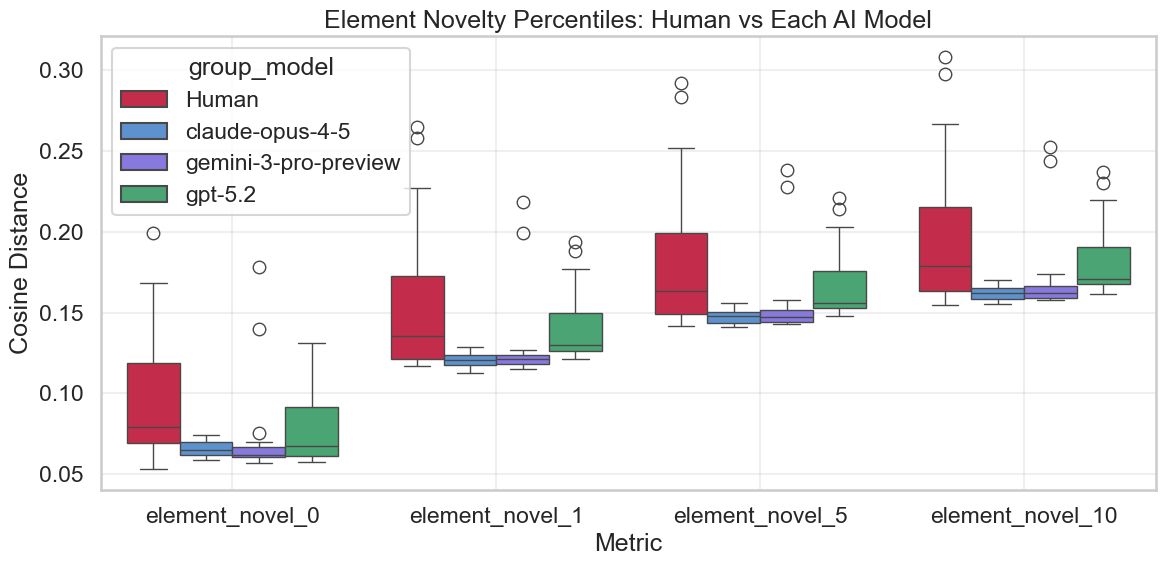

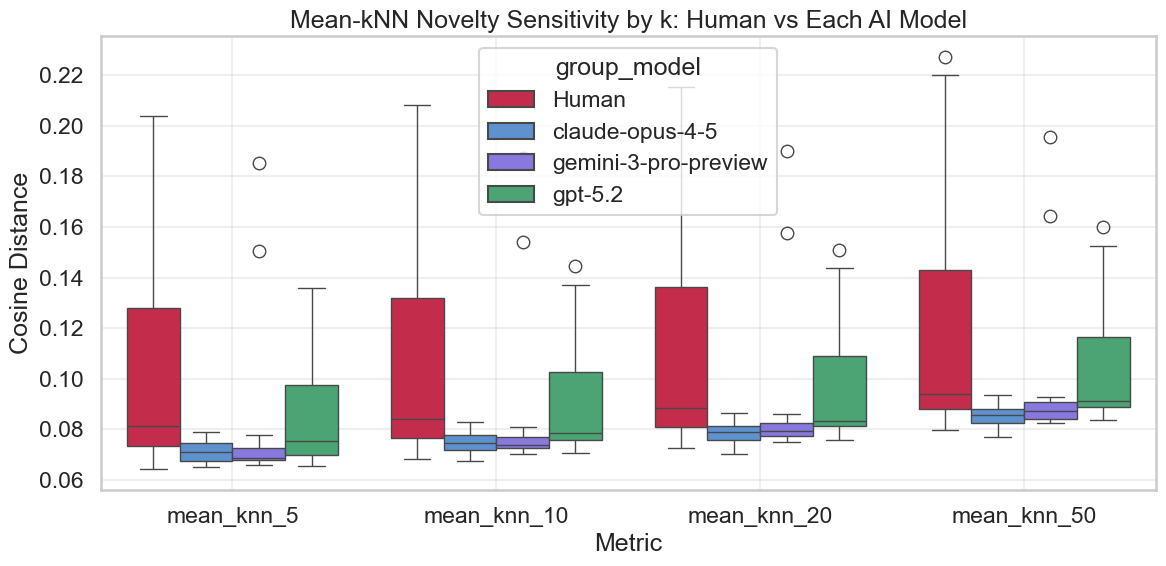

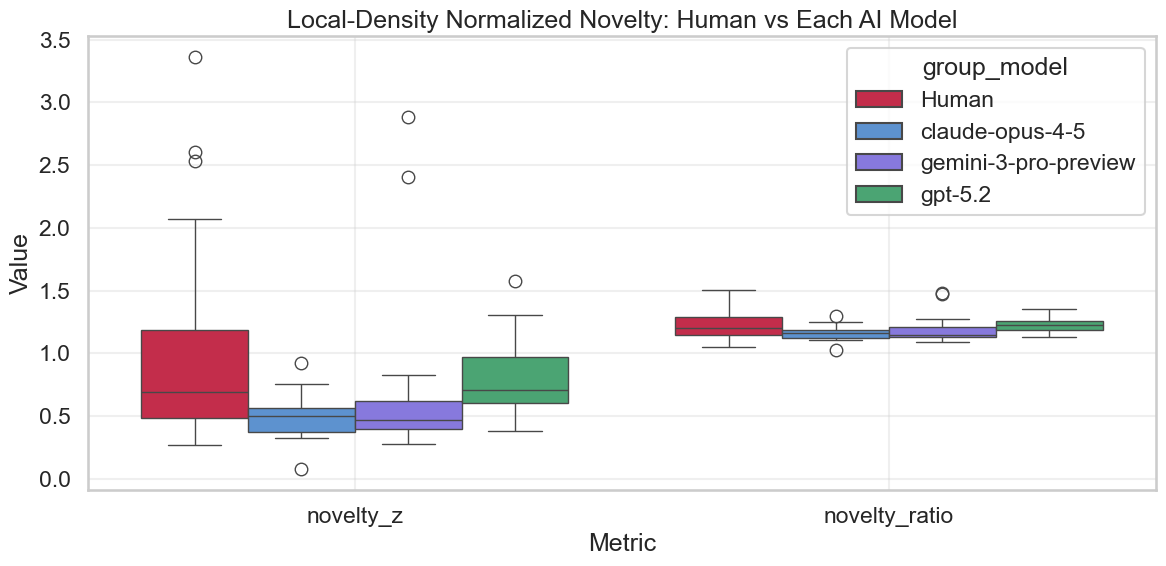

In [146]:

print('='*85)
print('STEP 6: NOVELTY VISUALIZATIONS (ELEMENT, MEANKNN, NORMALIZED)')
print('='*85)

# Panel A: Element novelty percentiles
fig, ax = plt.subplots(figsize=(12,6))
plot_df = element_novelty_df.melt(
    id_vars=['proposal_uid','group_model','group_binary'],
    value_vars=['element_novel_0','element_novel_1','element_novel_5','element_novel_10'],
    var_name='metric',
    value_name='value'
)
sns.boxplot(data=plot_df, x='metric', y='value', hue='group_model',
            hue_order=['Human']+list(ai_models), palette=colors, ax=ax)
ax.set_title('Element Novelty Percentiles: Human vs Each AI Model')
ax.set_xlabel('Metric')
ax.set_ylabel('Cosine Distance')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'novelty_analysis_element_percentiles.png', dpi=300, bbox_inches='tight')

# Panel B: MeanKNN k-sensitivity
fig, ax = plt.subplots(figsize=(12,6))
plot_df = mean_knn_novelty_df.melt(
    id_vars=['proposal_uid','group_model','group_binary'],
    value_vars=['mean_knn_5','mean_knn_10','mean_knn_20','mean_knn_50'],
    var_name='metric',
    value_name='value'
)
sns.boxplot(data=plot_df, x='metric', y='value', hue='group_model',
            hue_order=['Human']+list(ai_models), palette=colors, ax=ax)
ax.set_title('Mean-kNN Novelty Sensitivity by k: Human vs Each AI Model')
ax.set_xlabel('Metric')
ax.set_ylabel('Cosine Distance')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'novelty_analysis_mean_knn.png', dpi=300, bbox_inches='tight')

# Panel C: Normalized novelty
fig, ax = plt.subplots(figsize=(12,6))
plot_df = novelty_local_density_df.melt(
    id_vars=['proposal_uid','group_model','group_binary'],
    value_vars=['novelty_z','novelty_ratio'],
    var_name='metric',
    value_name='value'
)
sns.boxplot(data=plot_df, x='metric', y='value', hue='group_model',
            hue_order=['Human']+list(ai_models), palette=colors, ax=ax)
ax.set_title('Local-Density Normalized Novelty: Human vs Each AI Model')
ax.set_xlabel('Metric')
ax.set_ylabel('Value')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'novelty_analysis_local_density.png', dpi=300, bbox_inches='tight')

print('Saved novelty_analysis_element_percentiles.png, novelty_analysis_mean_knn.png, novelty_analysis_local_density.png')


Graph A — Element Novelty Percentiles
X-axis: element_novel_0, element_novel_1, element_novel_5, element_novel_10

The number is the percentile of the distance distribution over all 39k literature papers for that proposal:

Metric	What it measures
element_novel_0	Distance to the single most similar paper in all of literature (the minimum — the one paper you're most like)
element_novel_1	1st percentile — the threshold where 1% of lit papers are closer (~395 papers)
element_novel_5	5th percentile — the threshold where 5% of lit papers are closer (~1,977 papers)
element_novel_10	10th percentile — the threshold where 10% of lit papers are closer (~3,954 papers)
Interpretation: Moving from _0 → _10, you're progressively asking "how novel is this proposal even compared to a larger chunk of literature?" If a proposal has high element_novel_0 but low element_novel_10, it has no close twin in lit, but it still sits near a crowded neighborhood. Consistent high values across all four = genuinely distant from the whole literature.

Graph B — Mean-kNN Novelty (k-sensitivity check)
X-axis: mean_knn_5, mean_knn_10, mean_knn_20, mean_knn_50

For each proposal, find its k nearest literature papers and take the mean distance to those k papers:

Metric	What it measures
mean_knn_5	Average distance to the 5 closest lit papers
mean_knn_10	Average distance to the 10 closest lit papers
mean_knn_20	Average distance to the 20 closest lit papers
mean_knn_50	Average distance to the 50 closest lit papers
Interpretation: This is the primary novelty metric. Higher = more novel. The x-axis is a sensitivity analysis — if all four k values give similar results, the finding is robust. If mean_knn_5 is low but mean_knn_50 is high, the proposal has a few very close papers but is generally distant. mean_knn_10 is the canonical value used downstream in Graph C.

Graph C — Local-Density Normalized Novelty
X-axis: novelty_ratio, novelty_z

These correct for a confound: some areas of literature space are denser than others. A proposal about a crowded topic (e.g., COVID vaccines) will have low distances just because there are many nearby papers — not because it's unoriginal. The normalization computes the local density of the 10 nearest literature papers around each proposal and adjusts:

Metric	Formula	Interpretation
novelty_ratio	mean_knn_10 / local_lit_density	1.0 = as novel as expected given the local literature density; > 1.0 = more novel than the neighborhood
novelty_z	(mean_knn_10 - local_lit_density) / std(local_lit_density)	Z-score version — how many SDs more novel than the local literature neighborhood
Interpretation: If human proposals score higher here than AI proposals, it means humans are generating ideas in less-explored territory after accounting for how dense that territory is. novelty_z is more comparable across proposals; novelty_ratio emphasizes relative novelty multiplicatively.

Overall interpretation across all three graphs
Y-axis is always cosine distance (0 = identical, 1 = maximally different) for A and B; ratio/z-score for C
Higher = more novel in all panels
Human vs. AI comparison (the hue='group_binary' in all three plots): if the Human box sits higher, human proposals are more novel relative to existing literature
The three panels are complementary: A gives a distributional view, B gives a robust point estimate at different scales, C controls for neighborhood density


## Step 7: Visualize Proposals in Literature Embedding Space

Visualize proposals and literature in shared 2D embedding spaces. The first cell fits **t-SNE jointly** on literature + proposals; the second fits **UMAP on literature only** and projects proposals into that space.

Plots are now shown as **single full-canvas views** (not left/right midpoint splits) to avoid implying an artificial boundary in the embedding.
The publication-year view reuses the UMAP coordinates from the UMAP cell directly below.


VISUALIZING PROPOSALS IN LITERATURE EMBEDDING SPACE (t-SNE, REVIEW-AWARE)
Literature-space proposal counts by group_model:
group_model
Human                   23
gpt-5.2                 23
gemini-3-pro-preview    23
claude-opus-4-5         23

Fitting t-SNE on literature + proposals jointly...
(This may take a minute...)


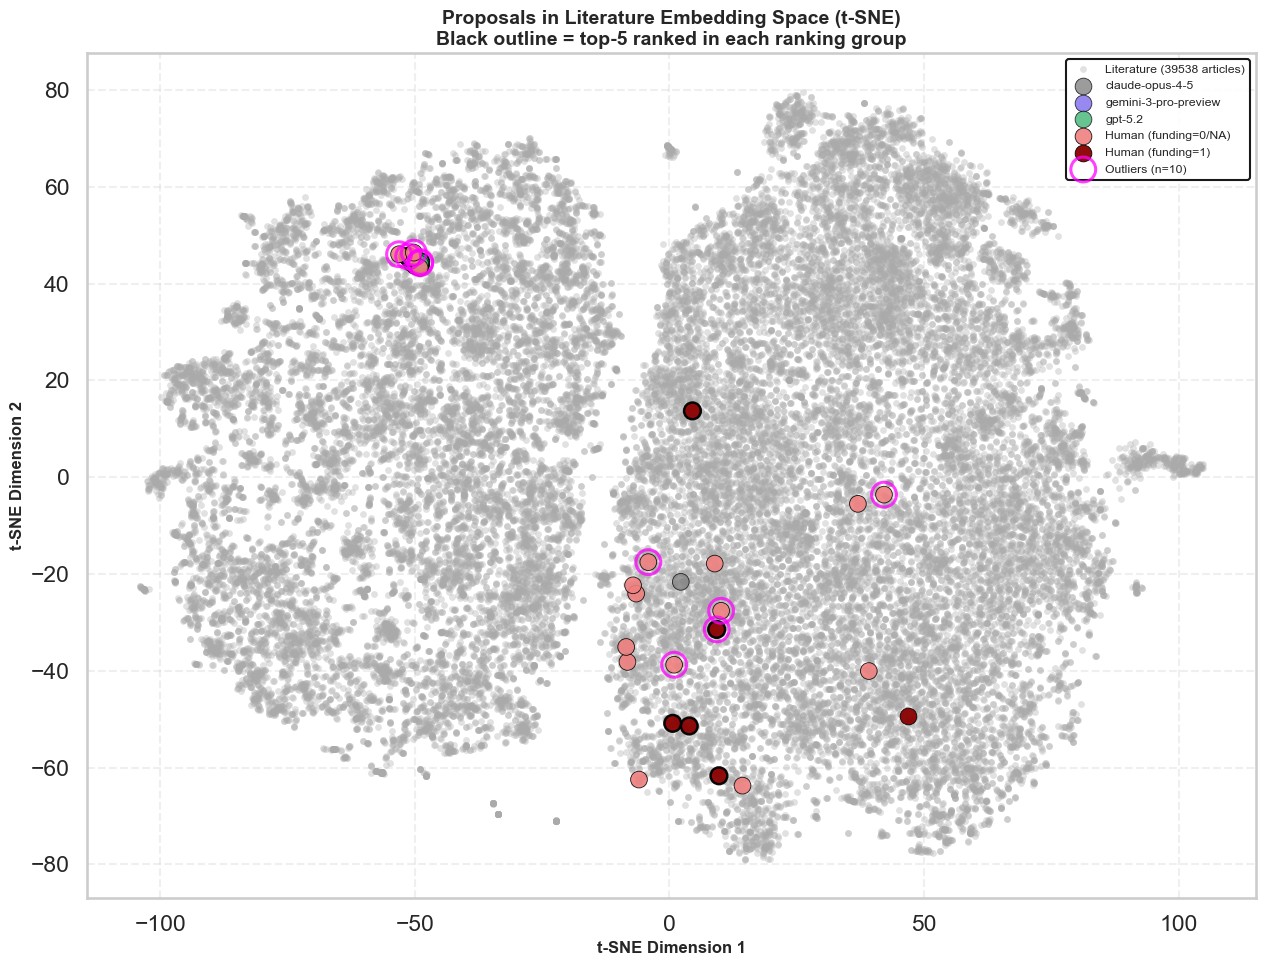


SUCCESS: Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/proposals_in_literature_space_tsne.png


In [137]:

from sklearn.manifold import TSNE

print("="*85)
print("VISUALIZING PROPOSALS IN LITERATURE EMBEDDING SPACE (t-SNE, REVIEW-AWARE)")
print("="*85)

# Build literature-space proposal metadata strictly in abstract-embedding order
n_human_abs = len(human_literature_embeddings)
n_ai_abs = len(ai_literature_embeddings)

if 'abstract_embeddings_data' in globals() and isinstance(abstract_embeddings_data, dict):
    human_meta_abs = abstract_embeddings_data.get('human_metadata', human_metadata)
    ai_meta_abs = abstract_embeddings_data.get('ai_metadata', ai_metadata)
else:
    human_meta_abs = human_metadata
    ai_meta_abs = ai_metadata

if len(human_meta_abs) != n_human_abs or len(ai_meta_abs) != n_ai_abs:
    print('WARNING: abstract metadata length mismatch; falling back to proposal_meta block-order assumptions.')
    human_titles_abs = proposal_meta.loc[proposal_meta['group_binary']=='Human', 'title'].tolist()
    ai_titles_abs = proposal_meta.loc[proposal_meta['group_binary']=='AI', 'title'].tolist()
    ai_models_abs = proposal_meta.loc[proposal_meta['group_binary']=='AI', 'group_model'].tolist()
else:
    human_titles_abs = [str(r.get('proposal_title', r.get('title', ''))) for r in human_meta_abs]
    ai_titles_abs = [str(r.get('title', r.get('proposal_title', ''))) for r in ai_meta_abs]
    ai_models_abs = [str(r.get('model', 'AI')) for r in ai_meta_abs]

proposal_meta_lit = pd.DataFrame({
    'title': human_titles_abs + ai_titles_abs,
    'group_binary': ['Human'] * n_human_abs + ['AI'] * n_ai_abs,
    'group_model': ['Human'] * n_human_abs + ai_models_abs,
})
proposal_meta_lit['title_norm'] = proposal_meta_lit['title'].astype(str).str.strip().str.lower()

# Join review/style fields from proposal_meta (if available)
join_cols = ['title_norm', 'group_binary', 'group_model']
extras = ['funding', 'viz_rank', 'viz_marker_size', 'is_top5_ranked']
for c in extras:
    if c not in proposal_meta.columns:
        proposal_meta[c] = np.nan
proposal_meta_lit = proposal_meta_lit.merge(
    proposal_meta[join_cols + extras].drop_duplicates(subset=join_cols),
    on=join_cols,
    how='left'
)

proposal_meta_lit['viz_marker_size'] = pd.to_numeric(proposal_meta_lit['viz_marker_size'], errors='coerce').fillna(145.0)
proposal_meta_lit['is_top5_ranked'] = proposal_meta_lit['is_top5_ranked'].fillna(False).astype(bool)
proposal_meta_lit['funding'] = pd.to_numeric(proposal_meta_lit['funding'], errors='coerce')

labels_prop = proposal_meta_lit['group_model'].to_numpy()
marker_sizes = proposal_meta_lit['viz_marker_size'].to_numpy()
top5_mask = proposal_meta_lit['is_top5_ranked'].to_numpy(dtype=bool)
funding = proposal_meta_lit['funding'].to_numpy()
human_mask = proposal_meta_lit['group_binary'].eq('Human').to_numpy()
ai_models_nov = sorted(proposal_meta_lit.loc[proposal_meta_lit['group_binary']=='AI', 'group_model'].dropna().unique().tolist())

print('Literature-space proposal counts by group_model:')
print(proposal_meta_lit['group_model'].value_counts().to_string())

print()
print("Fitting t-SNE on literature + proposals jointly...")
print("(This may take a minute...)")

proposals_stacked = np.vstack([human_literature_embeddings, ai_literature_embeddings])
all_embeddings_lit = np.vstack([literature_embeddings, proposals_stacked])

reducer_nov = TSNE(
    n_components=2,
    perplexity=30,
    metric='cosine',
    random_state=42,
    n_iter=1000,
    verbose=0,
)
all_2d_nov = reducer_nov.fit_transform(all_embeddings_lit)

n_lit = len(literature_embeddings)
literature_2d_nov = all_2d_nov[:n_lit]
proposals_2d_nov = all_2d_nov[n_lit:]

if len(proposals_2d_nov) != len(proposal_meta_lit):
    raise RuntimeError(f'Proposal count mismatch between Step 7 embeddings ({len(proposals_2d_nov)}) and proposal_meta_lit ({len(proposal_meta_lit)}).')

fig, ax = plt.subplots(1, 1, figsize=(13, 10))

ax.scatter(
    literature_2d_nov[:, 0], literature_2d_nov[:, 1],
    c='#AAAAAA', s=24, alpha=0.35, linewidths=0,
    label=f'Literature ({len(literature_embeddings)} articles)', zorder=1,
)

def _scatter_with_top5_outline(mask, color, label, alpha=0.75, zorder=3):
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return
    m_other = mask & (~top5_mask)
    m_top = mask & top5_mask
    if m_other.any():
        pts = proposals_2d_nov[m_other]
        ax.scatter(pts[:,0], pts[:,1], c=color, label=label, s=marker_sizes[m_other], alpha=alpha,
                   edgecolors='black', linewidth=0.6, zorder=zorder)
    if m_top.any():
        pts = proposals_2d_nov[m_top]
        ax.scatter(pts[:,0], pts[:,1], c=color, label=(label if not m_other.any() else None), s=marker_sizes[m_top], alpha=alpha,
                   edgecolors='black', linewidth=1.8, zorder=zorder+0.1)

for model in ai_models_nov:
    model_mask = labels_prop == model
    _scatter_with_top5_outline(model_mask, colors.get(model, '#808080'), model, alpha=0.78, zorder=4)

human_funded = human_mask & np.isfinite(funding) & (funding == 1)
human_nonfunded = human_mask & (~human_funded)

_scatter_with_top5_outline(human_nonfunded, '#F08080', 'Human (funding=0/NA)', alpha=0.90, zorder=6)
_scatter_with_top5_outline(human_funded, '#8B0000', 'Human (funding=1)', alpha=0.95, zorder=7)

if 'outliers' in globals() and len(outliers) == len(proposals_2d_nov):
    outlier_coords_nov = proposals_2d_nov[outliers]
    ax.scatter(
        outlier_coords_nov[:, 0], outlier_coords_nov[:, 1],
        s=np.maximum(marker_sizes[outliers] + 160, 320),
        facecolors='none', edgecolors='magenta',
        linewidth=2.2, alpha=0.75,
        label=f'Outliers (n={int(outliers.sum())})', zorder=9,
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposals in Literature Embedding Space (t-SNE)\nBlack outline = top-5 ranked in each ranking group', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=8.8, framealpha=0.9, edgecolor='black')

plt.tight_layout()
out_path = FIGURES_DIR / 'proposals_in_literature_space_tsne.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print()
print(f"SUCCESS: Figure saved to: {out_path}")
print("="*85)


VISUALIZING PROPOSALS IN LITERATURE EMBEDDING SPACE (UMAP, REVIEW-AWARE)
Literature-space proposal counts by group_model:
group_model
Human                   23
gpt-5.2                 23
gemini-3-pro-preview    23
claude-opus-4-5         23

Fitting UMAP on literature corpus...
Projecting proposals into literature UMAP space...
SUCCESS: Literature: 39538 points | Proposals: 92 points


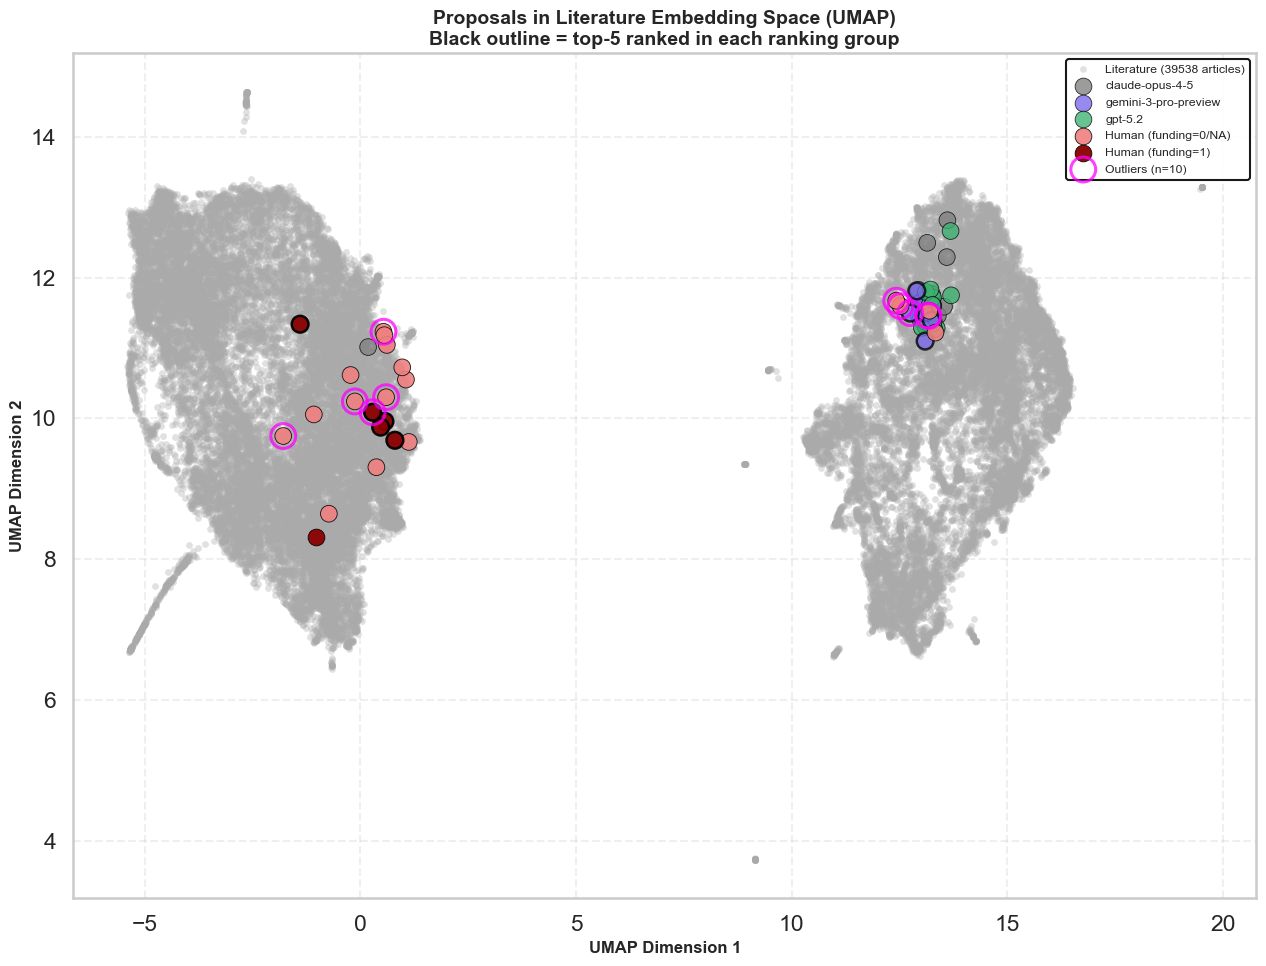


SUCCESS: Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/proposals_in_literature_space_umap.png


In [138]:

import umap

print("="*85)
print("VISUALIZING PROPOSALS IN LITERATURE EMBEDDING SPACE (UMAP, REVIEW-AWARE)")
print("="*85)

# Reuse literature-space-aligned proposal metadata when available
if 'proposal_meta_lit' not in globals():
    n_human_abs = len(human_literature_embeddings)
    n_ai_abs = len(ai_literature_embeddings)
    proposal_meta_lit = pd.DataFrame({
        'title': [''] * (n_human_abs + n_ai_abs),
        'group_binary': ['Human'] * n_human_abs + ['AI'] * n_ai_abs,
        'group_model': ['Human'] * n_human_abs + ['AI'] * n_ai_abs,
    })
    proposal_meta_lit['viz_marker_size'] = 145.0
    proposal_meta_lit['is_top5_ranked'] = False
    proposal_meta_lit['funding'] = np.nan

labels_prop = proposal_meta_lit['group_model'].to_numpy()
marker_sizes = pd.to_numeric(proposal_meta_lit['viz_marker_size'], errors='coerce').fillna(145.0).to_numpy()
top5_mask = proposal_meta_lit['is_top5_ranked'].fillna(False).to_numpy(dtype=bool)
funding = pd.to_numeric(proposal_meta_lit['funding'], errors='coerce').to_numpy()
human_mask = proposal_meta_lit['group_binary'].eq('Human').to_numpy()
ai_models_nov = sorted(proposal_meta_lit.loc[proposal_meta_lit['group_binary']=='AI', 'group_model'].dropna().unique().tolist())

print('Literature-space proposal counts by group_model:')
print(proposal_meta_lit['group_model'].value_counts().to_string())

proposals_stacked = np.vstack([human_literature_embeddings, ai_literature_embeddings])

print()
print("Fitting UMAP on literature corpus...")
reducer_nov_umap = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42,
)
literature_2d_umap = reducer_nov_umap.fit_transform(literature_embeddings)

print("Projecting proposals into literature UMAP space...")
proposals_2d_umap = reducer_nov_umap.transform(proposals_stacked)

if len(proposals_2d_umap) != len(proposal_meta_lit):
    raise RuntimeError(f'Proposal count mismatch between Step 7 UMAP projections ({len(proposals_2d_umap)}) and proposal_meta_lit ({len(proposal_meta_lit)}).')

print(f"SUCCESS: Literature: {len(literature_2d_umap)} points | Proposals: {len(proposals_2d_umap)} points")

all_pts_umap = np.vstack([literature_2d_umap, proposals_2d_umap])
x_all_umap = all_pts_umap[:, 0]
xsplit_umap = (x_all_umap.min() + x_all_umap.max()) / 2
left_mask_umap = x_all_umap < xsplit_umap
right_mask_umap = ~left_mask_umap

fig, ax = plt.subplots(1, 1, figsize=(13, 10))

ax.scatter(
    literature_2d_umap[:, 0], literature_2d_umap[:, 1],
    c='#AAAAAA', s=24, alpha=0.35, linewidths=0,
    label=f'Literature ({len(literature_embeddings)} articles)', zorder=1,
)

def _scatter_with_top5_outline(mask, color, label, alpha=0.75, zorder=3):
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return
    m_other = mask & (~top5_mask)
    m_top = mask & top5_mask
    if m_other.any():
        pts = proposals_2d_umap[m_other]
        ax.scatter(pts[:,0], pts[:,1], c=color, label=label, s=marker_sizes[m_other], alpha=alpha,
                   edgecolors='black', linewidth=0.6, zorder=zorder)
    if m_top.any():
        pts = proposals_2d_umap[m_top]
        ax.scatter(pts[:,0], pts[:,1], c=color, label=(label if not m_other.any() else None), s=marker_sizes[m_top], alpha=alpha,
                   edgecolors='black', linewidth=1.8, zorder=zorder+0.1)

for model in ai_models_nov:
    model_mask = labels_prop == model
    _scatter_with_top5_outline(model_mask, colors.get(model, '#808080'), model, alpha=0.78, zorder=4)

human_funded = human_mask & np.isfinite(funding) & (funding == 1)
human_nonfunded = human_mask & (~human_funded)

_scatter_with_top5_outline(human_nonfunded, '#F08080', 'Human (funding=0/NA)', alpha=0.90, zorder=6)
_scatter_with_top5_outline(human_funded, '#8B0000', 'Human (funding=1)', alpha=0.95, zorder=7)

if 'outliers' in globals() and len(outliers) == len(proposals_2d_umap):
    outlier_coords_umap = proposals_2d_umap[outliers]
    ax.scatter(
        outlier_coords_umap[:, 0], outlier_coords_umap[:, 1],
        s=np.maximum(marker_sizes[outliers] + 160, 320),
        facecolors='none', edgecolors='magenta',
        linewidth=2.2, alpha=0.75,
        label=f'Outliers (n={int(outliers.sum())})', zorder=9,
    )

ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposals in Literature Embedding Space (UMAP)\nBlack outline = top-5 ranked in each ranking group', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=8.8, framealpha=0.9, edgecolor='black')

plt.tight_layout()
out_path_umap = FIGURES_DIR / 'proposals_in_literature_space_umap.png'
plt.savefig(out_path_umap, dpi=300, bbox_inches='tight')
plt.show()
print()
print(f"SUCCESS: Figure saved to: {out_path_umap}")
print("="*85)


### Step 7B: Literature-Space Outliers and High-Novelty Flags

Flags top 10% proposals for mean_knn_10, element_novel_0, and novelty_z, then runs group prevalence tests.

STEP 7B: LITERATURE-SPACE OUTLIERS AND HIGH-NOVELTY FLAGS
Saved literature_space_outliers_mean_knn_k10.csv, literature_space_outliers_element0.csv, literature_space_outliers_z.csv, literature_space_outlier_prevalence_tests.csv

STEP 7B VIS: UMAP outlier comparison (proposal-space vs literature-space k10)


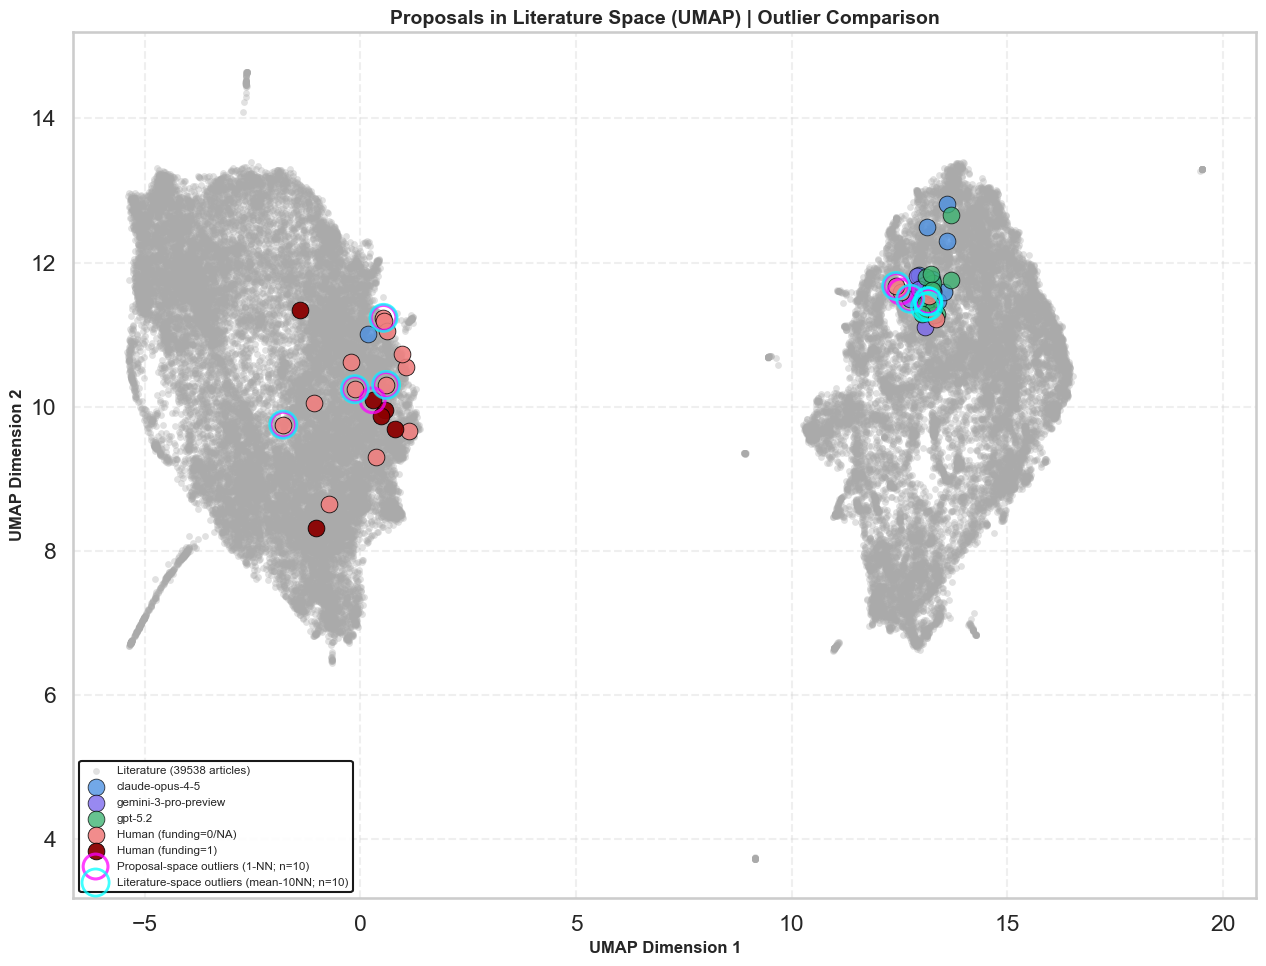

SUCCESS: Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/proposals_in_literature_space_umap_outliers_comparison_k10.png


In [147]:

print('='*85)
print('STEP 7B: LITERATURE-SPACE OUTLIERS AND HIGH-NOVELTY FLAGS')
print('='*85)

lit_outlier_flags_df = proposal_meta[['proposal_uid', 'title', 'group_model', 'group_binary']].copy()
lit_outlier_flags_df['mean_knn_10'] = mean_knn_novelty_df['mean_knn_10'].to_numpy()
lit_outlier_flags_df['element_novel_0'] = element_novelty_df['element_novel_0'].to_numpy()
lit_outlier_flags_df['novelty_z'] = novelty_local_density_df['novelty_z'].to_numpy()

flag_mean10, thr_mean10 = flag_top_percentile(lit_outlier_flags_df['mean_knn_10'].to_numpy(), pct=90, strict=True)
flag_element0, thr_element0 = flag_top_percentile(lit_outlier_flags_df['element_novel_0'].to_numpy(), pct=90, strict=True)
valid_z = lit_outlier_flags_df['novelty_z'].to_numpy()
mask_valid_z = np.isfinite(valid_z)
thr_z = np.percentile(valid_z[mask_valid_z], 90) if mask_valid_z.any() else np.nan
flag_z = np.zeros(len(valid_z), dtype=bool)
flag_z[mask_valid_z] = valid_z[mask_valid_z] > thr_z

lit_outlier_flags_df['is_lit_outlier_mean10'] = flag_mean10
lit_outlier_flags_df['is_lit_outlier_element0'] = flag_element0
lit_outlier_flags_df['is_lit_outlier_z'] = flag_z

# Backward compatibility aliases used in downstream/legacy cells
mean_lit_knn_dist = lit_outlier_flags_df['mean_knn_10'].to_numpy()
lit_mknn_threshold = thr_mean10
is_literature_outlier = flag_mean10

# prevalence tests per flag family
test_frames = []
for flag_col in ['is_lit_outlier_mean10', 'is_lit_outlier_element0', 'is_lit_outlier_z']:
    t = fisher_group_prevalence_tests(lit_outlier_flags_df[flag_col].to_numpy(), lit_outlier_flags_df['group_model'].to_numpy(), reference_group='Human')
    if len(t):
        t['flag_name'] = flag_col
        t = apply_multiple_testing(t, p_cols=('p_value',), method='holm')
    test_frames.append(t)

lit_outlier_prevalence_tests_df = pd.concat(test_frames, ignore_index=True) if test_frames else pd.DataFrame()

# Required exports
lit_outlier_flags_df.to_csv(TABLES_DIR / 'literature_space_outliers_mean_knn_k10.csv', index=False)
lit_outlier_flags_df.to_csv(TABLES_DIR / 'literature_space_outliers_element0.csv', index=False)
lit_outlier_flags_df.to_csv(TABLES_DIR / 'literature_space_outliers_z.csv', index=False)
lit_outlier_prevalence_tests_df.to_csv(TABLES_DIR / 'literature_space_outlier_prevalence_tests.csv', index=False)

print('Saved literature_space_outliers_mean_knn_k10.csv, literature_space_outliers_element0.csv, literature_space_outliers_z.csv, literature_space_outlier_prevalence_tests.csv')



# Outlier-comparison UMAP overlay (proposal-space outliers vs literature-space mean-k10 outliers)
if 'proposals_2d_umap' in globals() and 'lit_outlier_flags_df' in globals() and 'proposal_meta_lit' in globals():
    print('\n' + '='*85)
    print('STEP 7B VIS: UMAP outlier comparison (proposal-space vs literature-space k10)')
    print('='*85)

    # align lit-space outlier flags to literature-space embedding order
    lit_flags = proposal_meta_lit[['title','group_binary','group_model']].copy()
    lit_flags['title_norm'] = lit_flags['title'].astype(str).str.strip().str.lower()

    src = lit_outlier_flags_df.copy()
    src['title_norm'] = src['title'].astype(str).str.strip().str.lower()
    keep = ['title_norm','group_binary','group_model','is_lit_outlier_mean10']
    lit_flags = lit_flags.merge(src[keep].drop_duplicates(subset=['title_norm','group_binary','group_model']),
                                on=['title_norm','group_binary','group_model'], how='left')
    lit_out_mask = lit_flags['is_lit_outlier_mean10'].fillna(False).to_numpy(dtype=bool)

    fig, ax = plt.subplots(1, 1, figsize=(13, 10))
    ax.scatter(literature_2d_umap[:,0], literature_2d_umap[:,1], c='#AAAAAA', s=24, alpha=0.35, linewidths=0,
               label=f'Literature ({len(literature_embeddings)} articles)', zorder=1)

    # draw proposals with same style as UMAP main
    def _draw(mask, color, label, alpha=0.78, zorder=4):
        mask=np.asarray(mask,dtype=bool)
        if not mask.any():
            return
        pts=proposals_2d_umap[mask]
        ax.scatter(pts[:,0], pts[:,1], c=color, s=145, alpha=alpha, edgecolors='black', linewidth=0.6,
                   label=label, zorder=zorder)

    for model in sorted(proposal_meta_lit.loc[proposal_meta_lit['group_binary']=='AI','group_model'].dropna().unique().tolist()):
        _draw(proposal_meta_lit['group_model'].to_numpy()==model, colors.get(model,'#808080'), model, alpha=0.78, zorder=4)

    hmask = proposal_meta_lit['group_binary'].eq('Human').to_numpy()
    hfund = pd.to_numeric(proposal_meta_lit['funding'], errors='coerce').to_numpy()
    _draw(hmask & (~(np.isfinite(hfund) & (hfund==1))), '#F08080', 'Human (funding=0/NA)', alpha=0.90, zorder=6)
    _draw(hmask & (np.isfinite(hfund) & (hfund==1)), '#8B0000', 'Human (funding=1)', alpha=0.95, zorder=7)

    if 'outliers' in globals() and len(outliers)==len(proposals_2d_umap):
        pts = proposals_2d_umap[outliers]
        ax.scatter(pts[:,0], pts[:,1], s=320, facecolors='none', edgecolors='magenta', linewidth=2.2,
                   alpha=0.75, label=f'Proposal-space outliers (1-NN; n={int(outliers.sum())})', zorder=9)

    if len(lit_out_mask)==len(proposals_2d_umap):
        pts = proposals_2d_umap[lit_out_mask]
        ax.scatter(pts[:,0], pts[:,1], s=380, facecolors='none', edgecolors='cyan', linewidth=2.0,
                   alpha=0.75, label=f'Literature-space outliers (mean-10NN; n={int(lit_out_mask.sum())})', zorder=10)

    ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
    ax.set_title('Proposals in Literature Space (UMAP) | Outlier Comparison', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=8.4, framealpha=0.9, edgecolor='black')

    out_cmp = FIGURES_DIR / 'proposals_in_literature_space_umap_outliers_comparison_k10.png'
    plt.tight_layout()
    plt.savefig(out_cmp, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'SUCCESS: Figure saved to: {out_cmp}')


## Additional Analysis: Nearest Neighbors in Literature for Every Proposal

For **each** proposal (human and AI), retrieve the 3 nearest literature abstracts by cosine distance and save the result as a **CSV table** (`nearest_literature_neighbors_top3.csv`).
Each row corresponds to one proposal-neighbor pair and includes proposal metadata, neighbor rank, literature metadata, and distance.

In [140]:

print('='*85)
print('ADDITIONAL ANALYSIS: TOP-3 LITERATURE NEIGHBORS FOR EACH PROPOSAL')
print('='*85)

rows = []
for i in range(len(proposal_meta)):
    top3_idx = D_pl_sorted_idx[i, :3]
    top3_dist = D_pl_sorted_dist[i, :3]
    for rnk, (lid, dist) in enumerate(zip(top3_idx, top3_dist), start=1):
        art = articles[int(lid)]
        rows.append({
            'proposal_uid': proposal_meta.loc[i, 'proposal_uid'],
            'proposal_title': proposal_meta.loc[i, 'title'],
            'proposal_group_model': proposal_meta.loc[i, 'group_model'],
            'neighbor_rank': rnk,
            'lit_doc_id': art.get('pmid', lid),
            'lit_title': art.get('title', ''),
            'lit_year': str(art.get('publication_date', ''))[:4],
            'lit_distance': float(dist),
            'lit_query_category': art.get('query_category', ''),
            'lit_abstract_preview': str(art.get('abstract', ''))[:240],
        })

nearest_literature_neighbors_df = pd.DataFrame(rows)
nearest_literature_neighbors_df.to_csv(TABLES_DIR / 'nearest_literature_neighbors_top3.csv', index=False)
print('Saved nearest_literature_neighbors_top3.csv')

# print required top tables
m = mean_knn_novelty_df[['proposal_uid','title','group_model','mean_knn_10']].copy()
e0 = element_novelty_df[['proposal_uid','title','group_model','element_novel_0']].copy()
print('\nTop 10 largest mean_knn_10')
print(m.sort_values('mean_knn_10', ascending=False).head(10).to_string(index=False))
print('\nTop 10 smallest mean_knn_10')
print(m.sort_values('mean_knn_10', ascending=True).head(10).to_string(index=False))
print('\nTop 10 largest element_novel_0')
print(e0.sort_values('element_novel_0', ascending=False).head(10).to_string(index=False))


ADDITIONAL ANALYSIS: TOP-3 LITERATURE NEIGHBORS FOR EACH PROPOSAL
Saved nearest_literature_neighbors_top3.csv

Top 10 largest mean_knn_10
proposal_uid                                                                                                                                  title          group_model  mean_knn_10
       P_002                                                                     MaiTool - LLM-powered bioinformatics tools for microbiome analysis                Human     0.208225
       P_010                                             Searching the crosslinking mass spectrometry universe for new protein-protein interactions                Human     0.196365
       P_062                                                                      Synthesizing the Emergent Assembly of Bacterial Microcompartments gemini-3-pro-preview     0.187318
       P_022                                  Discovery and functional analysis of bacterial organelles through mining and refinement 

In [141]:

# Unified novelty export
novelty_scores_from_literature_df = proposal_meta[['proposal_uid', 'title', 'group_model', 'group_binary']].copy()

for col in ['element_novel_0','element_novel_1','element_novel_5','element_novel_10']:
    novelty_scores_from_literature_df[col] = element_novelty_df[col].to_numpy()
for col in ['mean_knn_5','mean_knn_10','mean_knn_20','mean_knn_50']:
    novelty_scores_from_literature_df[col] = mean_knn_novelty_df[col].to_numpy()
for col in ['novelty_ratio','novelty_z']:
    novelty_scores_from_literature_df[col] = novelty_local_density_df[col].to_numpy()
for col in ['is_lit_outlier_mean10','is_lit_outlier_element0','is_lit_outlier_z']:
    novelty_scores_from_literature_df[col] = lit_outlier_flags_df[col].to_numpy()

novelty_scores_from_literature_df.to_csv(TABLES_DIR / 'novelty_scores_from_literature.csv', index=False)
print('Saved novelty_scores_from_literature.csv')


Saved novelty_scores_from_literature.csv


## Unified Proposal-Level Metric Export

In [149]:

proposal_metrics_master_df = proposal_meta[['proposal_uid', 'title', 'group_model', 'group_binary', 'is_ai']].copy()

def _dedup(df, cols):
    """Keep first row per proposal_uid to prevent many-to-many merge inflation."""
    return df[cols].drop_duplicates(subset=['proposal_uid'])

# Diversity proposal-level
proposal_metrics_master_df = proposal_metrics_master_df.merge(
    _dedup(pairwise_proposal_df, ['proposal_uid','mean_pairwise_dist']), on='proposal_uid', how='left'
)
proposal_metrics_master_df = proposal_metrics_master_df.merge(
    _dedup(centroid_proposal_df, ['proposal_uid','centroid_dist_raw','centroid_dist_loo']), on='proposal_uid', how='left'
)
proposal_metrics_master_df = proposal_metrics_master_df.merge(
    _dedup(between_group_global_centroid_df, ['proposal_uid','global_centroid_dist']), on='proposal_uid', how='left'
)
proposal_metrics_master_df = proposal_metrics_master_df.merge(
    _dedup(nn_proposal_df, ['proposal_uid','nn_dist_global','is_nn_outlier']), on='proposal_uid', how='left'
)
proposal_metrics_master_df = proposal_metrics_master_df.merge(
    _dedup(mean5_df, ['proposal_uid','mean_5nn_dist_global','is_mean5nn_outlier']), on='proposal_uid', how='left'
)
proposal_metrics_master_df = proposal_metrics_master_df.merge(
    _dedup(medoid_proposal_df, ['proposal_uid','medoid_dist']), on='proposal_uid', how='left'
)
print(f'master df rows after merges: {len(proposal_metrics_master_df)} (expected {len(proposal_meta)})')

# Group-level diversity mapped down
rc_map = pairwise_group_summary_df.set_index('group')['remote_clique'].to_dict()
ch_map = chamfer_group_summary_df.set_index('group')['chamfer'].to_dict()
mst_map = mst_group_summary_df.set_index('group')['mst_dispersion'].to_dict()
sp90_map = span90_group_summary_df.set_index('group')['span_90'].to_dict()
sp_map = sparseness_group_summary_df.set_index('group')['sparseness'].to_dict()
ent_map = entropy_group_summary_df.set_index('group')['grid_entropy'].to_dict()
entn_map = entropy_group_summary_df.set_index('group')['grid_entropy_normalized'].to_dict()

proposal_metrics_master_df['remote_clique_group'] = proposal_metrics_master_df['group_model'].map(rc_map)
proposal_metrics_master_df['chamfer_group'] = proposal_metrics_master_df['group_model'].map(ch_map)
proposal_metrics_master_df['mst_dispersion_group'] = proposal_metrics_master_df['group_model'].map(mst_map)
proposal_metrics_master_df['span90_group'] = proposal_metrics_master_df['group_model'].map(sp90_map)
proposal_metrics_master_df['sparseness_group'] = proposal_metrics_master_df['group_model'].map(sp_map)
proposal_metrics_master_df['grid_entropy_group'] = proposal_metrics_master_df['group_model'].map(ent_map)
proposal_metrics_master_df['grid_entropy_group_norm'] = proposal_metrics_master_df['group_model'].map(entn_map)

# Novelty continuous + flags
for c in ['element_novel_0','element_novel_1','element_novel_5','element_novel_10']:
    proposal_metrics_master_df[c] = element_novelty_df[c].to_numpy()
for c in ['mean_knn_5','mean_knn_10','mean_knn_20','mean_knn_50']:
    proposal_metrics_master_df[c] = mean_knn_novelty_df[c].to_numpy()
for c in ['novelty_ratio','novelty_z']:
    proposal_metrics_master_df[c] = novelty_local_density_df[c].to_numpy()
for c in ['is_lit_outlier_mean10','is_lit_outlier_element0','is_lit_outlier_z']:
    proposal_metrics_master_df[c] = lit_outlier_flags_df[c].to_numpy()

proposal_metrics_master_df.to_csv(TABLES_DIR / 'proposal_metrics_master.csv', index=False)
print('Saved proposal_metrics_master.csv')
print('Rows:', len(proposal_metrics_master_df))


master df rows after merges: 92 (expected 92)
Saved proposal_metrics_master.csv
Rows: 92


# PART III: THEMATIC AND CLUSTER ANALYSIS

Examine whether human and AI proposals cluster in distinct semantic regions and differ in thematic coverage.

**⚠️ Sample Size Note:** With n=23 human and n=69 AI proposals, we use conservative approaches with strong regularization and permutation-based validation.

## Analysis 3.1: Topic Modeling (LDA - Exploratory)

Use Latent Dirichlet Allocation with strong priors to identify thematic topics. LDA is more stable than BERTopic for small samples.

In [150]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

print("="*85)
print("TOPIC MODELING WITH LDA (EXPLORATORY)")
print("="*85)
print("Using normalized CONTENT text (title + abstract) to reduce formatting/template confounding.")

def _normalize_topic_text(text):
    text = str(text or "")
    text = re.sub(r'\b(title|abstract|background|methods?|research questions?|outcomes?|open science|budget)\s*:', ' ', text, flags=re.I)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

def _build_topic_text(row, is_ai=True):
    if is_ai:
        title = row.get('title', '')
        abstract = row.get('abstract', '')
    else:
        title = row.get('proposal_title', row.get('title', ''))
        abstract = row.get('abstract', '')
    return _normalize_topic_text(f"{title}. {abstract}")

ai_abstracts = [_build_topic_text(row, is_ai=True) for _, row in ai_df.iterrows()]
human_abstracts = [_build_topic_text(row, is_ai=False) for _, row in human_df.iterrows()]
all_abstracts = human_abstracts + ai_abstracts

source_labels = ['Human'] * len(human_abstracts) + ['AI'] * len(ai_abstracts)
model_labels = ['Human'] * len(human_abstracts) + ai_df['model'].tolist()

print()
print(f"✓ Prepared {len(all_abstracts)} topic-model texts")
print(f"  Human: {len(human_abstracts)}, AI: {len(ai_abstracts)}")

_unigram_probe = CountVectorizer(stop_words='english', ngram_range=(1, 1), min_df=2, max_df=1.0, max_features=5000)
_unigram_X = _unigram_probe.fit_transform(all_abstracts)
_unigram_terms = _unigram_probe.get_feature_names_out()
_unigram_df = np.asarray((_unigram_X > 0).mean(axis=0)).ravel()

auto_domain_unigram_stopwords = set(_unigram_terms[_unigram_df >= 0.50])
manual_domain_unigram_stopwords = {
    'cell', 'cells', 'protein', 'proteins',
    'title', 'abstract', 'project', 'proposal', 'outcomes',
    'background', 'method', 'methods',
    'using', 'nup', '000', 'nan', 'fg', 'npc', 'ii', 'et'
}
domain_unigram_stopwords = auto_domain_unigram_stopwords | manual_domain_unigram_stopwords

_top_common_idx = np.argsort(_unigram_df)[-20:][::-1]
print()
print("Most common unigrams in corpus (doc frequency):")
for i in _top_common_idx:
    print(f"  {_unigram_terms[i]}: {_unigram_df[i]:.2f}")
print()
print(f"✓ Domain unigram stopwords (auto+manual): {len(domain_unigram_stopwords)}")

print()
print("Creating document-term matrix...")
vectorizer = CountVectorizer(max_features=2000, min_df=2, max_df=0.7, stop_words='english', ngram_range=(1, 2))
_doc_term_matrix_full = vectorizer.fit_transform(all_abstracts)
_feature_names_full = np.array(vectorizer.get_feature_names_out())

_unigram_mask = np.array([' ' not in t for t in _feature_names_full])
_drop_mask = _unigram_mask & np.isin(_feature_names_full, list(domain_unigram_stopwords))
_keep_mask = ~_drop_mask

doc_term_matrix = _doc_term_matrix_full[:, _keep_mask]
feature_names = _feature_names_full[_keep_mask]

print(f"✓ Document-term matrix: {doc_term_matrix.shape}")
print(f"  Documents: {doc_term_matrix.shape[0]}, Vocabulary: {doc_term_matrix.shape[1]}")
print(f"  Dropped domain unigrams: {_drop_mask.sum()} (kept bigrams intact)")

print()
print("Fitting LDA with conservative parameters...")
print("  n_topics=5, alpha=0.5, beta=0.5 (strong regularization)")

n_topics = 3
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    doc_topic_prior=0.5,
    topic_word_prior=0.5,
    max_iter=100,
    learning_method='batch',
    random_state=42,
    n_jobs=-1
)
doc_topic_dist = lda_model.fit_transform(doc_term_matrix)

print("✓ LDA fitted")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print(f"  Log-likelihood: {lda_model.score(doc_term_matrix):.2f}")

def display_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics.append(top_words)
    return topics

topics = display_topics(lda_model, feature_names, n_top_words=10)

print()
print("="*85)
print("TOP 10 WORDS PER TOPIC")
print("="*85)
for i, topic_words in enumerate(topics):
    print()
    print(f"Topic {i+1}: {', '.join(topic_words)}")

doc_topic_df = pd.DataFrame(doc_topic_dist, columns=[f'Topic_{i+1}' for i in range(n_topics)])
doc_topic_df['source'] = source_labels
doc_topic_df['model'] = model_labels
doc_topic_df['group'] = ['Human' if s == 'Human' else 'AI' for s in source_labels]

doc_topic_df['dominant_topic'] = doc_topic_df[[f'Topic_{i+1}' for i in range(n_topics)]].idxmax(axis=1)
doc_topic_df['dominant_topic_prob'] = doc_topic_df[[f'Topic_{i+1}' for i in range(n_topics)]].max(axis=1)

print()
print("="*85)
print("DOCUMENT-TOPIC DISTRIBUTION SUMMARY")
print("="*85)
print("Mean topic probabilities per document:")
for i in range(n_topics):
    print(f"  Topic {i+1}: {doc_topic_df[f'Topic_{i+1}'].mean():.3f} ± {doc_topic_df[f'Topic_{i+1}'].std():.3f}")

print()
print("Dominant topic assignment:")
print(doc_topic_df['dominant_topic'].value_counts().sort_index())

print()
print("⚠️ LABEL AS EXPLORATORY - Small sample size limits topic stability")
print("="*85)


TOPIC MODELING WITH LDA (EXPLORATORY)
Using normalized CONTENT text (title + abstract) to reduce formatting/template confounding.

✓ Prepared 92 topic-model texts
  Human: 23, AI: 69

Most common unigrams in corpus (doc frequency):
  emergent: 0.43
  data: 0.35
  synthesizing: 0.28
  emergence: 0.25
  synthesis: 0.22
  integrating: 0.18
  cell: 0.16
  proteomics: 0.14
  networks: 0.13
  protein: 0.13
  dynamics: 0.12
  decoding: 0.12
  imaging: 0.12
  cellular: 0.12
  organization: 0.12
  structural: 0.12
  understand: 0.11
  functional: 0.10
  multi: 0.10
  assembly: 0.09

✓ Domain unigram stopwords (auto+manual): 20

Creating document-term matrix...
✓ Document-term matrix: (92, 197)
  Documents: 92, Vocabulary: 197
  Dropped domain unigrams: 3 (kept bigrams intact)

Fitting LDA with conservative parameters...
  n_topics=5, alpha=0.5, beta=0.5 (strong regularization)
✓ LDA fitted
  Perplexity: 194.33
  Log-likelihood: -4157.69

TOP 10 WORDS PER TOPIC

Topic 1: synthesis, emergent, dyn

In [151]:
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2_contingency

print("="*85)
print("TOPIC STABILITY VALIDATION")
print("="*85)
print("Running LDA with 10 different random seeds to assess stability (with topic alignment)...")

n_stability_runs = 10
n_top_words = 10
stability_topics = []
stability_topic_dists = []

for seed in range(n_stability_runs):
    lda_temp = LatentDirichletAllocation(
        n_components=n_topics,
        doc_topic_prior=0.5,
        topic_word_prior=0.5,
        max_iter=100,
        learning_method='batch',
        random_state=seed,
        n_jobs=-1
    )
    lda_temp.fit(doc_term_matrix)

    topic_word = lda_temp.components_.astype(float)
    topic_word = topic_word / topic_word.sum(axis=1, keepdims=True)

    topics_temp = display_topics(lda_temp, feature_names, n_top_words=n_top_words)
    stability_topics.append(topics_temp)
    stability_topic_dists.append(topic_word)

print(f"✓ Completed {n_stability_runs} stability runs")

ref_words_by_topic = [set(ws) for ws in stability_topics[0]]
ref_dist = stability_topic_dists[0]

def _cosine_sim_matrix(A, B, eps=1e-12):
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + eps)
    return A @ B.T

per_topic_overlap_all = [[] for _ in range(n_topics)]
per_topic_cos_all = [[] for _ in range(n_topics)]

print()
print("Topic stability (aligned to reference run):")
for run_idx in range(1, n_stability_runs):
    run_dist = stability_topic_dists[run_idx]
    sim = _cosine_sim_matrix(run_dist, ref_dist)

    row_ind, col_ind = linear_sum_assignment(-sim)

    aligned_words = [None] * n_topics
    aligned_cos = np.zeros(n_topics, dtype=float)
    for r_topic, ref_topic in zip(row_ind, col_ind):
        aligned_words[ref_topic] = set(stability_topics[run_idx][r_topic])
        aligned_cos[ref_topic] = sim[r_topic, ref_topic]

    overlaps = []
    for k in range(n_topics):
        overlap = len(ref_words_by_topic[k] & aligned_words[k]) / max(1, len(ref_words_by_topic[k]))
        overlaps.append(overlap)
        per_topic_overlap_all[k].append(overlap)
        per_topic_cos_all[k].append(aligned_cos[k])

    print(f"  Run {run_idx}: mean top-{n_top_words} overlap={np.mean(overlaps):.1%}, mean cosine={np.mean(aligned_cos):.3f}")

print()
print("Per-topic stability (mean across aligned runs):")
for k in range(n_topics):
    print(
        f"  Topic {k+1}: {np.mean(per_topic_overlap_all[k]):.1%} ± {np.std(per_topic_overlap_all[k]):.1%} top-{n_top_words} overlap, "
        f"{np.mean(per_topic_cos_all[k]):.3f} ± {np.std(per_topic_cos_all[k]):.3f} cosine"
    )

print()
print("="*85)
print("TOPIC COUNT SENSITIVITY (k = 4..8)")
print("="*85)

sensitivity_rows = []
for k in [4, 5, 6, 7, 8]:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        doc_topic_prior=0.5,
        topic_word_prior=0.5,
        max_iter=100,
        learning_method='batch',
        random_state=42,
        n_jobs=-1
    )
    dt_k = lda_k.fit_transform(doc_term_matrix)
    dominant_k = pd.Series(dt_k.argmax(axis=1)).map(lambda x: f'Topic_{x+1}')
    cont_k = pd.crosstab(dominant_k, pd.Series(source_labels, name='group'))
    chi2_k, p_k, _, _ = chi2_contingency(cont_k)

    sensitivity_rows.append({
        'k': k,
        'perplexity': float(lda_k.perplexity(doc_term_matrix)),
        'log_likelihood': float(lda_k.score(doc_term_matrix)),
        'chi2': float(chi2_k),
        'chi2_p': float(p_k),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print(sensitivity_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()
print("💡 If overlap/cosine are still low AFTER alignment, that reflects true instability.")
print("💡 k-sensitivity helps verify conclusions are not artifacts of a single topic count.")
print("="*85)


TOPIC STABILITY VALIDATION
Running LDA with 10 different random seeds to assess stability (with topic alignment)...
✓ Completed 10 stability runs

Topic stability (aligned to reference run):
  Run 1: mean top-10 overlap=56.7%, mean cosine=0.814
  Run 2: mean top-10 overlap=56.7%, mean cosine=0.806
  Run 3: mean top-10 overlap=76.7%, mean cosine=0.865
  Run 4: mean top-10 overlap=80.0%, mean cosine=0.876
  Run 5: mean top-10 overlap=66.7%, mean cosine=0.837
  Run 6: mean top-10 overlap=50.0%, mean cosine=0.726
  Run 7: mean top-10 overlap=66.7%, mean cosine=0.784
  Run 8: mean top-10 overlap=70.0%, mean cosine=0.832
  Run 9: mean top-10 overlap=53.3%, mean cosine=0.823

Per-topic stability (mean across aligned runs):
  Topic 1: 47.8% ± 18.1% top-10 overlap, 0.709 ± 0.052 cosine
  Topic 2: 76.7% ± 13.3% top-10 overlap, 0.878 ± 0.070 cosine
  Topic 3: 67.8% ± 14.0% top-10 overlap, 0.868 ± 0.051 cosine

TOPIC COUNT SENSITIVITY (k = 4..8)
 k  perplexity  log_likelihood    chi2  chi2_p
 4   

## Analysis 3.2: Topic Distribution Comparison

Test whether topic distributions differ between human and AI proposals using permutation tests and Fisher's exact tests.

In [152]:
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.multitest import multipletests

print("="*85)
print("TOPIC DISTRIBUTION COMPARISON  (soft assignment: proposals with >20% probability)")
print("="*85)

threshold = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])

human_df_t = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_df_t    = doc_topic_df[doc_topic_df['group'] == 'AI']

# Soft participation counts: proposals with >threshold probability for each topic.
# A single proposal can contribute to multiple topics.
soft_human = {col: int((human_df_t[col] > threshold).sum()) for col in topic_cols}
soft_ai    = {col: int((ai_df_t[col]    > threshold).sum()) for col in topic_cols}

contingency_table = pd.DataFrame({'Human': soft_human, 'AI': soft_ai})
contingency_table.index.name = 'Topic'

print("\nSoft participation table (proposals with >20% probability per topic):")
print(contingency_table)

soft_frac = contingency_table.copy().astype(float)
soft_frac['Human'] /= len(human_df_t)
soft_frac['AI']    /= len(ai_df_t)
print("\nAs fraction of group size:")
print(soft_frac.round(3))
print("\nRow proportions (fraction of soft members from each group):")
print(contingency_table.div(contingency_table.sum(axis=1), axis=0).round(3))

# Permutation test using chi-square statistic on soft counts
print("\n" + "-"*85)
print("PERMUTATION TEST: Overall soft-topic distribution difference")
print("-"*85)

def soft_chi_stat(df, topic_cols, threshold=0.20):
    h_df = df[df['group'] == 'Human']
    a_df = df[df['group'] == 'AI']
    tbl  = np.array([[int((h_df[c] > threshold).sum()), int((a_df[c] > threshold).sum())]
                     for c in topic_cols])
    if tbl.sum() == 0 or (tbl.sum(axis=0) == 0).any():
        return 0.0
    try:
        return chi2_contingency(tbl)[0]
    except Exception:
        return 0.0

observed_chi2 = soft_chi_stat(doc_topic_df, topic_cols, threshold)
print(f"Observed chi-square statistic: {observed_chi2:.4f}")

n_permutations = 10000
perm_chi2_stats = []
for _ in range(n_permutations):
    perm_df = doc_topic_df.copy()
    perm_df['group'] = np.random.permutation(perm_df['group'].values)
    perm_chi2_stats.append(soft_chi_stat(perm_df, topic_cols, threshold))

perm_chi2_stats = np.array(perm_chi2_stats)
p_value_perm = np.mean(perm_chi2_stats >= observed_chi2)

print(f"\nPermutation test results ({n_permutations:,} permutations):")
print(f"  Null mean chi-square: {perm_chi2_stats.mean():.4f} +/- {perm_chi2_stats.std():.4f}")
print(f"  Observed chi-square:  {observed_chi2:.4f}")
print(f"  p-value: {p_value_perm:.4f}")
if p_value_perm < 0.05:
    print("  -> Significant difference in soft topic distributions (p < 0.05)")
else:
    print("  -> No significant difference in soft topic distributions (p >= 0.05)")

# Per-topic Fisher's exact (binary: has >20% for topic or not)
print("\n" + "-"*85)
print("PER-TOPIC TESTS: Fisher's Exact (Human vs. All AI, soft assignment)")
print("-"*85)

n_h = len(human_df_t)
n_a = len(ai_df_t)
fisher_results = []
for col in topic_cols:
    h_yes = soft_human[col]; h_no = n_h - h_yes
    a_yes = soft_ai[col];    a_no = n_a - a_yes
    odds_ratio, p_value = fisher_exact([[h_yes, a_yes], [h_no, a_no]])
    fisher_results.append({
        'topic':       col,
        'human_count': h_yes,
        'ai_count':    a_yes,
        'human_pct':   h_yes / n_h * 100,
        'ai_pct':      a_yes / n_a * 100,
        'odds_ratio':  odds_ratio,
        'p_value':     p_value,
    })

fisher_df = pd.DataFrame(fisher_results)
fisher_df['p_value_fdr'] = multipletests(fisher_df['p_value'], method='fdr_bh', alpha=0.10)[1]

print(f"\n{'Topic':<12} {'Human %':<10} {'AI %':<10} {'OR':<8} {'p-value':<10} {'FDR q':<10} Result")
print("-"*85)
for _, row in fisher_df.iterrows():
    sig = "***" if row["p_value_fdr"]<0.01 else "**" if row["p_value_fdr"]<0.05 else "*" if row["p_value_fdr"]<0.10 else ""
    direction = "Human up" if row["odds_ratio"] > 1 else "AI up" if row["odds_ratio"] < 1 else "Equal"
    print(f"{row['topic']:<12} {row['human_pct']:<10.1f} {row['ai_pct']:<10.1f} "
          f"{row['odds_ratio']:<8.2f} {row['p_value']:<10.4f} {row['p_value_fdr']:<10.4f} {direction} {sig}")

print("\n*** p<0.01, ** p<0.05, * p<0.10 (FDR-corrected)")
print("OR > 1 = over-represented in human; OR < 1 = over-represented in AI")
print("="*85)


TOPIC DISTRIBUTION COMPARISON  (soft assignment: proposals with >20% probability)

Soft participation table (proposals with >20% probability per topic):
         Human  AI
Topic             
Topic_1     13  27
Topic_2      9  26
Topic_3      9  29

As fraction of group size:
         Human     AI
Topic                
Topic_1  0.565  0.391
Topic_2  0.391  0.377
Topic_3  0.391  0.420

Row proportions (fraction of soft members from each group):
         Human     AI
Topic                
Topic_1  0.325  0.675
Topic_2  0.257  0.743
Topic_3  0.237  0.763

-------------------------------------------------------------------------------------
PERMUTATION TEST: Overall soft-topic distribution difference
-------------------------------------------------------------------------------------
Observed chi-square statistic: 0.8361

Permutation test results (10,000 permutations):
  Null mean chi-square: 1.5721 +/- 1.5501
  Observed chi-square:  0.8361
  p-value: 0.5990
  -> No significant difference 

In [153]:
# Subsample validation -- soft assignment (proposals with >20% probability per topic)
print("="*85)
print("SUBSAMPLE VALIDATION  (soft assignment, AI subsampled to n=23)")
print("="*85)
print("Subsampling AI to n=23, repeating 1000 times...")

threshold  = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])
n_subsamples = 1000
subsample_results = {col: [] for col in topic_cols}

for _ in range(n_subsamples):
    ai_idx     = doc_topic_df[doc_topic_df['group'] == 'AI'].index
    sample_idx = np.random.choice(ai_idx, size=len(human_abstracts), replace=False)
    sampled_ai = doc_topic_df.loc[sample_idx]
    human_sub  = doc_topic_df[doc_topic_df['group'] == 'Human']
    n_h = len(human_sub); n_a = len(sampled_ai)

    for col in topic_cols:
        h_yes = int((human_sub[col]  > threshold).sum()); h_no = n_h - h_yes
        a_yes = int((sampled_ai[col] > threshold).sum()); a_no = n_a - a_yes
        _, p_val = fisher_exact([[h_yes, a_yes], [h_no, a_no]])
        subsample_results[col].append(p_val)

print("\nSubsample validation results (soft assignment):")
print(f"{'Topic':<12} {'Sig. subsamples':<22} {'Proportion':<12} Interpretation")
print("-"*85)
for col in topic_cols:
    p_vals = np.array(subsample_results[col])
    n_sig  = int((p_vals < 0.05).sum())
    prop   = n_sig / n_subsamples
    interp = "Robust" if prop > 0.8 else "Moderate" if prop > 0.5 else "Weak"
    print(f"{col:<12} {n_sig}/{n_subsamples:<17} {prop:<12.2%} {interp}")

print("\n Proportion >80% = robust difference even with balanced sample sizes")
print("="*85)


SUBSAMPLE VALIDATION  (soft assignment, AI subsampled to n=23)
Subsampling AI to n=23, repeating 1000 times...

Subsample validation results (soft assignment):
Topic        Sig. subsamples        Proportion   Interpretation
-------------------------------------------------------------------------------------
Topic_1      27/1000              2.70%        Weak
Topic_2      0/1000              0.00%        Weak
Topic_3      0/1000              0.00%        Weak

 Proportion >80% = robust difference even with balanced sample sizes


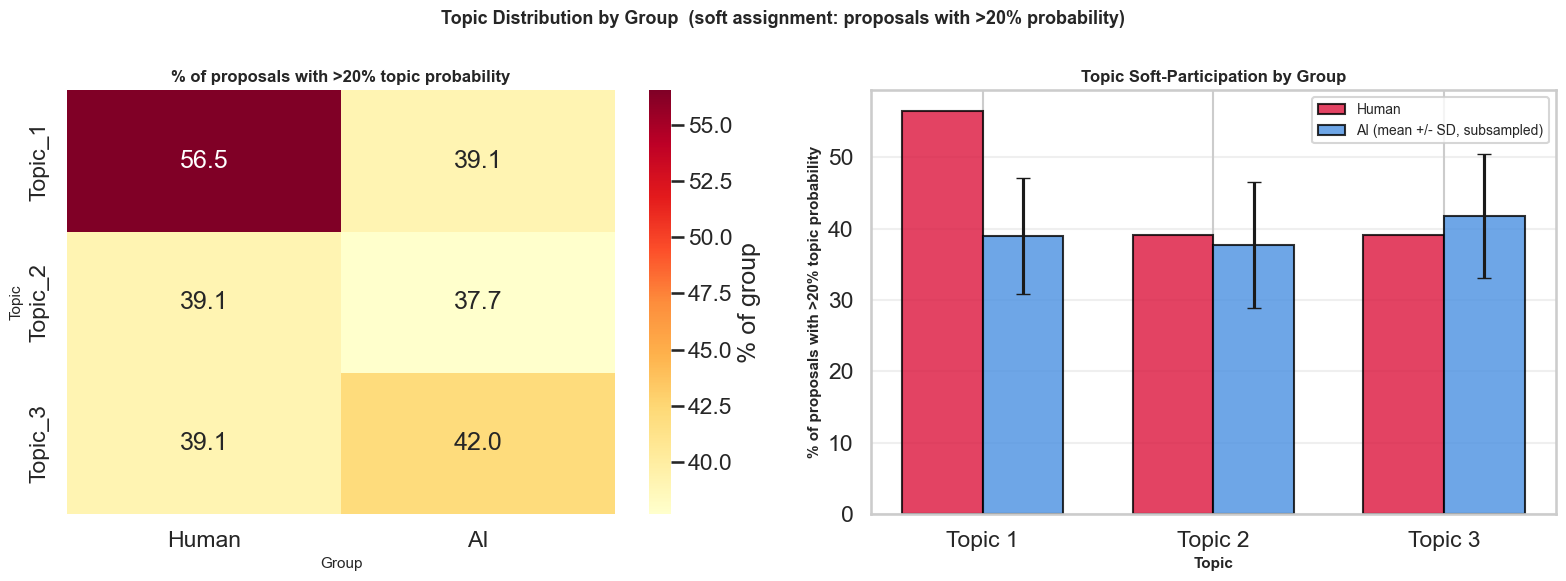

Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/topic_distribution_comparison.png


In [154]:
import seaborn as sns

# Visualization: Soft-assignment topic distribution by group
threshold  = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])

human_df_t = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_df_t    = doc_topic_df[doc_topic_df['group'] == 'AI']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Topic Distribution by Group  (soft assignment: proposals with >20% probability)",
             fontsize=13, fontweight='bold')

# Panel 1: Heatmap -- fraction of group with >20% for each topic
soft_frac = pd.DataFrame({
    'Human': {col: (human_df_t[col] > threshold).mean() * 100 for col in topic_cols},
    'AI':    {col: (ai_df_t[col]    > threshold).mean() * 100 for col in topic_cols},
})
sns.heatmap(soft_frac, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': '% of group'})
axes[0].set_title('% of proposals with >20% topic probability', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Group', fontsize=11)
axes[0].set_ylabel('Topic', fontsize=11)

# Panel 2: Bar plot with subsample error bars
x     = np.arange(len(topic_cols))
width = 0.35
human_pcts = [(human_df_t[col] > threshold).mean() * 100 for col in topic_cols]

ai_pcts_mean, ai_pcts_std = [], []
ai_idx = ai_df_t.index
for col in topic_cols:
    vals = []
    for _ in range(500):
        s = doc_topic_df.loc[np.random.choice(ai_idx, size=len(human_df_t), replace=False)]
        vals.append((s[col] > threshold).mean() * 100)
    ai_pcts_mean.append(np.mean(vals))
    ai_pcts_std.append(np.std(vals))

axes[1].bar(x - width/2, human_pcts,  width,
            label='Human', color='#DC143C', alpha=0.8, edgecolor='black')
axes[1].bar(x + width/2, ai_pcts_mean, width, yerr=ai_pcts_std,
            label='AI (mean +/- SD, subsampled)',
            color='#4A90E2', alpha=0.8, edgecolor='black', capsize=5)
axes[1].set_xlabel('Topic', fontsize=11, fontweight='bold')
axes[1].set_ylabel('% of proposals with >20% topic probability', fontsize=11, fontweight='bold')
axes[1].set_title('Topic Soft-Participation by Group', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([c.replace('_', ' ') for c in topic_cols])
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'topic_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {FIGURES_DIR / 'topic_distribution_comparison.png'}")


## Analysis 3.3: Topic Coverage and Entropy

Examine breadth and evenness of topic coverage with sample size corrections.

In [155]:
from scipy.stats import entropy as scipy_entropy

print("="*85)
print("TOPIC COVERAGE AND ENTROPY ANALYSIS  (soft assignment throughout)")
print("="*85)

threshold  = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])

human_doc_topics = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_doc_topics    = doc_topic_df[doc_topic_df['group'] == 'AI']

# ── 1. Coverage (unchanged -- already used soft assignment) ───────────────────
def count_topics_covered(group_df, topic_cols, threshold=0.20):
    return sum(1 for col in topic_cols if (group_df[col] > threshold).any())

human_coverage = count_topics_covered(human_doc_topics, topic_cols, threshold)
ai_coverage    = count_topics_covered(ai_doc_topics,    topic_cols, threshold)

print()
print(f"1. TOPIC COVERAGE (topics with at least one proposal >{threshold*100:.0f}% probability):")
print(f"  Human: {human_coverage}/{len(topic_cols)} topics")
print(f"  AI:    {ai_coverage}/{len(topic_cols)} topics")

# ── 2. Exclusive topics -- soft, min_count=2 (was 5; too strict at n=23) ─────
def get_exclusive_topics_soft(group_df, other_df, topic_cols, threshold=0.20, min_count=2):
    """Topics where group has >=min_count proposals >threshold AND other group has 0."""
    return [(col, int((group_df[col] > threshold).sum()))
            for col in topic_cols
            if (group_df[col] > threshold).sum() >= min_count
            and (other_df[col] > threshold).sum() == 0]

human_exclusive_raw = get_exclusive_topics_soft(human_doc_topics, ai_doc_topics,    topic_cols, threshold)
ai_exclusive_raw    = get_exclusive_topics_soft(ai_doc_topics,    human_doc_topics, topic_cols, threshold)

human_exclusive = [t for t, _ in human_exclusive_raw]
ai_exclusive    = [t for t, _ in ai_exclusive_raw]

print()
print(f"2. EXCLUSIVE TOPICS (soft: >=2 proposals >{threshold*100:.0f}% probability, 0 in other group):")
print(f"  Human-exclusive: {len(human_exclusive)}")
for t, n in human_exclusive_raw:
    print(f"    {t} ({n} proposals)")
print(f"  AI-exclusive:    {len(ai_exclusive)}")
for t, n in ai_exclusive_raw:
    print(f"    {t} ({n} proposals)")

print()
print("  Permutation test for exclusive topic counts:")
n_perm    = 10000
perm_h_exc = []
perm_a_exc = []
for _ in range(n_perm):
    shuffled          = doc_topic_df.copy()
    shuffled['group'] = np.random.permutation(shuffled['group'].values)
    h = shuffled[shuffled['group'] == 'Human']
    a = shuffled[shuffled['group'] == 'AI']
    perm_h_exc.append(len(get_exclusive_topics_soft(h, a, topic_cols, threshold)))
    perm_a_exc.append(len(get_exclusive_topics_soft(a, h, topic_cols, threshold)))

perm_h_exc = np.array(perm_h_exc)
perm_a_exc = np.array(perm_a_exc)
p_human = np.mean(perm_h_exc >= len(human_exclusive))
p_ai    = np.mean(perm_a_exc >= len(ai_exclusive))
print(f"    Human: {len(human_exclusive)} observed vs. {perm_h_exc.mean():.2f} +/- {perm_h_exc.std():.2f} expected, p={p_human:.4f}")
print(f"    AI:    {len(ai_exclusive)} observed vs. {perm_a_exc.mean():.2f} +/- {perm_a_exc.std():.2f} expected, p={p_ai:.4f}")

# ── 3. Shannon entropy on MEAN SOFT TOPIC DISTRIBUTION ───────────────────────
print()
print("3. SHANNON ENTROPY on mean soft topic distribution (Miller-Madow corrected):")
print("   Uses mean LDA probability across proposals -- more informative than dominant-topic counts.")

def group_soft_entropy(group_df, topic_cols, base=2):
    mean_dist    = group_df[topic_cols].mean()
    mean_dist    = mean_dist / mean_dist.sum()
    h            = float(scipy_entropy(mean_dist, base=base))
    k            = len(topic_cols)
    n            = len(group_df)
    h_corrected  = h + (k - 1) / (2 * n)
    h_max        = np.log2(k)
    h_normalized = h_corrected / h_max if h_max > 0 else 0
    return h_corrected, h_normalized

human_entropy, human_norm_entropy = group_soft_entropy(human_doc_topics, topic_cols)
ai_entropy,    ai_norm_entropy    = group_soft_entropy(ai_doc_topics,    topic_cols)

print(f"  Human: H = {human_entropy:.4f}, H_normalized = {human_norm_entropy:.4f}")
print(f"  AI:    H = {ai_entropy:.4f}, H_normalized = {ai_norm_entropy:.4f}")

print()
print(f"  Subsample validation (AI subsampled to n={len(human_doc_topics)}, 1000 iterations):")
subsample_entropies      = []
subsample_norm_entropies = []
ai_idx = ai_doc_topics.index
for _ in range(1000):
    sampled = ai_doc_topics.loc[np.random.choice(ai_idx, size=len(human_doc_topics), replace=False)]
    h, h_norm = group_soft_entropy(sampled, topic_cols)
    subsample_entropies.append(h)
    subsample_norm_entropies.append(h_norm)

subsample_entropies      = np.array(subsample_entropies)
subsample_norm_entropies = np.array(subsample_norm_entropies)

print(f"    AI (subsampled): H = {subsample_entropies.mean():.4f} +/- {subsample_entropies.std():.4f}")
print(f"    AI (subsampled): H_normalized = {subsample_norm_entropies.mean():.4f} +/- {subsample_norm_entropies.std():.4f}")

diff        = human_entropy - subsample_entropies.mean()
p_lower     = np.mean(subsample_entropies <= human_entropy)
p_upper     = np.mean(subsample_entropies >= human_entropy)
p_two_sided = min(1.0, 2 * min(p_lower, p_upper))
p_one_sided = p_lower if human_entropy < subsample_entropies.mean() else p_upper
p_entropy   = p_two_sided

print()
print("  Comparison (subsample test):")
print(f"    Difference (Human - AI_subsample_mean): {diff:.4f}")
print(f"    p_one_sided (observed direction): {p_one_sided:.4f}")
print(f"    p_two_sided: {p_two_sided:.4f}")
if p_two_sided < 0.05:
    direction_str = "HIGHER" if human_entropy > subsample_entropies.mean() else "LOWER"
    print(f"    -> Human proposals have significantly {direction_str} entropy")
else:
    print("    -> No significant difference in entropy")

print()
print("  Higher entropy = more even spread of probability mass across topics")
print("  Soft entropy avoids the dominant-topic discretization artifact.")
print("="*85)


TOPIC COVERAGE AND ENTROPY ANALYSIS  (soft assignment throughout)

1. TOPIC COVERAGE (topics with at least one proposal >20% probability):
  Human: 3/3 topics
  AI:    3/3 topics

2. EXCLUSIVE TOPICS (soft: >=2 proposals >20% probability, 0 in other group):
  Human-exclusive: 0
  AI-exclusive:    0

  Permutation test for exclusive topic counts:
    Human: 0 observed vs. 0.00 +/- 0.00 expected, p=1.0000
    AI:    0 observed vs. 0.00 +/- 0.00 expected, p=1.0000

3. SHANNON ENTROPY on mean soft topic distribution (Miller-Madow corrected):
   Uses mean LDA probability across proposals -- more informative than dominant-topic counts.
  Human: H = 1.6135, H_normalized = 1.0180
  AI:    H = 1.5987, H_normalized = 1.0087

  Subsample validation (AI subsampled to n=23, 1000 iterations):
    AI (subsampled): H = 1.6012 +/- 0.0282
    AI (subsampled): H_normalized = 1.0103 +/- 0.0178

  Comparison (subsample test):
    Difference (Human - AI_subsample_mean): 0.0123
    p_one_sided (observed dire

## Analysis 3.4: Cluster Composition/Segregation Analysis

Examine whether human and AI proposals segregate into distinct clusters in embedding space using Gaussian Mixture Models.

In [156]:
from pathlib import Path

emb_path = PROPOSAL_EMBEDDINGS_FILE
if not emb_path.exists():
    legacy_paths = sorted(emb_path.parent.glob('proposal_embeddings_[0-9]*.pkl'))
    if not legacy_paths:
        raise FileNotFoundError(f"No embedding pickle found at {emb_path}. Run the embedding generation cell first.")
    emb_path = legacy_paths[-1]

embeddings_data = retrieve_embeddings(str(emb_path))

ai_embeddings = embeddings_data['ai_embeddings']
human_embeddings = embeddings_data['human_embeddings']
# ai_metadata = embeddings_data['ai_metadata']
# human_metadata = embeddings_data['human_metadata']

print(f"✓ Loaded embeddings from: {emb_path}")
print(f"  AI: {ai_embeddings.shape}, Human: {human_embeddings.shape}")


✓ Loaded embeddings from: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/rephrased/minimal/proposal_embeddings_human_ai_rephrased.pkl
  AI: (69, 1024), Human: (23, 1024)


CLUSTER ANALYSIS: STEP 1 - OPTIMAL k SELECTION

Using embeddings: (92, 1024)
  Human: 23, AI: 69

Testing k = [3, 4, 5, 6, 7, 8]...

k     Silhouette   Davies-Bouldin   BIC         
--------------------------------------------------
3     0.1442       2.5817           6050901.67  
4     0.0833       2.5834           8424734.72  
5     0.0494       2.5788           10798718.95 
6     0.0600       2.6483           13164480.22 
7     0.0412       2.5074           15544460.17 
8     0.0436       2.1211           17919616.68 

✓ Best k by BIC (elbow method): 3
✓ Best k by Silhouette score: 3

→ Selected k = 3 (using BIC)


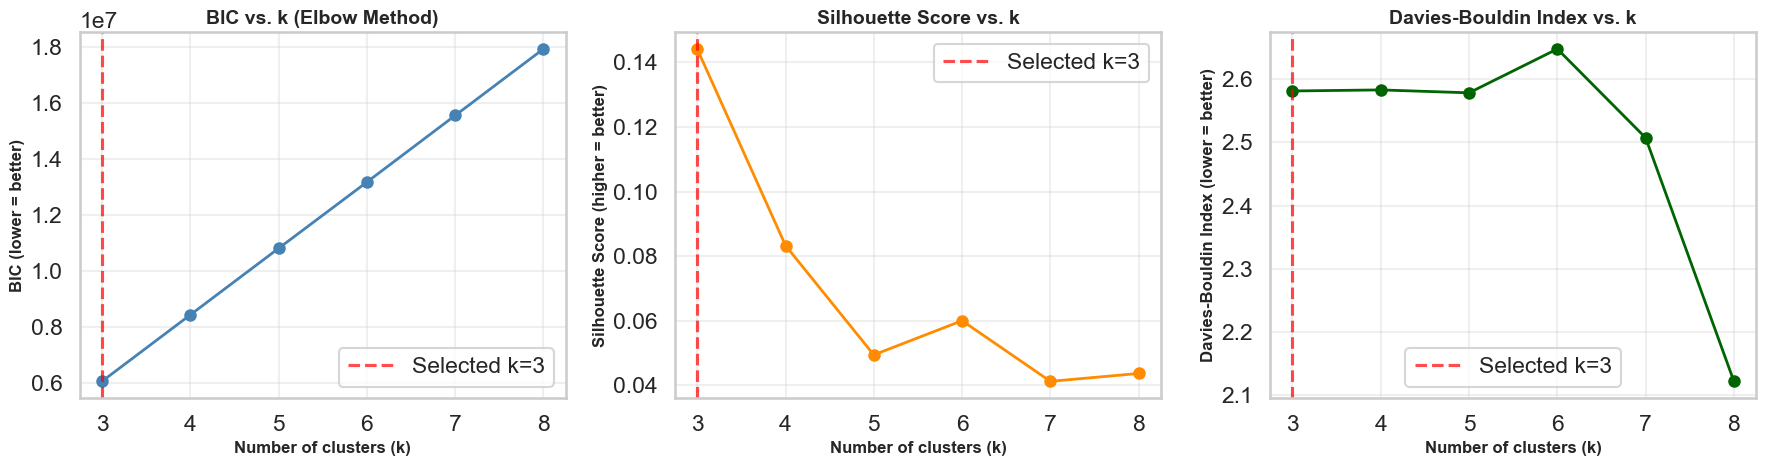

✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/cluster_k_selection.png


In [157]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, normalized_mutual_info_score, adjusted_rand_score

print("="*85)
print("CLUSTER ANALYSIS: STEP 1 - OPTIMAL k SELECTION")
print("="*85)

# Use embeddings from diversity analysis (already computed)
all_embeddings_cluster = np.vstack([human_embeddings, ai_embeddings])
source_labels_cluster = np.array(['Human'] * len(human_embeddings) + ['AI'] * len(ai_embeddings))

print(f"\nUsing embeddings: {all_embeddings_cluster.shape}")
print(f"  Human: {len(human_embeddings)}, AI: {len(ai_embeddings)}")

# Test different values of k
k_values = [3, 4, 5, 6, 7, 8]
metrics_results = []

print(f"\nTesting k = {k_values}...")
print(f"\n{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<16} {'BIC':<12}")
print("-"*50)

for k in k_values:
    # Fit GMM
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    cluster_labels = gmm.fit_predict(all_embeddings_cluster)
    
    # Compute metrics
    silhouette = silhouette_score(all_embeddings_cluster, cluster_labels)
    davies_bouldin = davies_bouldin_score(all_embeddings_cluster, cluster_labels)
    bic = gmm.bic(all_embeddings_cluster)
    
    metrics_results.append({
        'k': k,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'bic': bic
    })
    
    print(f"{k:<5} {silhouette:<12.4f} {davies_bouldin:<16.4f} {bic:<12.2f}")

metrics_df = pd.DataFrame(metrics_results)

# Select best k using BIC (lower is better)
best_k_bic = metrics_df.loc[metrics_df['bic'].idxmin(), 'k']
best_k_silhouette = metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k']

print(f"\n✓ Best k by BIC (elbow method): {best_k_bic}")
print(f"✓ Best k by Silhouette score: {best_k_silhouette}")

# Use BIC as primary criterion
best_k = int(best_k_bic)
print(f"\n→ Selected k = {best_k} (using BIC)")

# Visualize selection metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: BIC
ax1 = axes[0]
ax1.plot(metrics_df['k'], metrics_df['bic'], 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax1.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('BIC (lower = better)', fontsize=12, fontweight='bold')
ax1.set_title('BIC vs. k (Elbow Method)', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend()

# Panel 2: Silhouette
ax2 = axes[1]
ax2.plot(metrics_df['k'], metrics_df['silhouette'], 'o-', linewidth=2, markersize=8, color='darkorange')
ax2.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax2.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Silhouette Score (higher = better)', fontsize=12, fontweight='bold')
ax2.set_title('Silhouette Score vs. k', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()

# Panel 3: Davies-Bouldin
ax3 = axes[2]
ax3.plot(metrics_df['k'], metrics_df['davies_bouldin'], 'o-', linewidth=2, markersize=8, color='darkgreen')
ax3.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax3.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Davies-Bouldin Index (lower = better)', fontsize=12, fontweight='bold')
ax3.set_title('Davies-Bouldin Index vs. k', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {FIGURES_DIR / 'cluster_k_selection.png'}")
print("="*85)

In [158]:
print("="*85)
print(f"CLUSTER ANALYSIS: STEP 2 - CLUSTERING WITH k={best_k}")
print("="*85)

# Fit final GMM with best k
gmm_final = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    random_state=42,
    n_init=10
)

cluster_labels_final = gmm_final.fit_predict(all_embeddings_cluster)
cluster_probs_final = gmm_final.predict_proba(all_embeddings_cluster)

print(f"\n✓ Clustered {len(all_embeddings_cluster)} proposals into {best_k} clusters")
print(f"  Cluster sizes: {np.bincount(cluster_labels_final)}")

# Cluster composition analysis
print(f"\n" + "-"*85)
print("CLUSTER COMPOSITION ANALYSIS")
print("-"*85)

cluster_composition = []

for cluster_id in range(best_k):
    cluster_mask = cluster_labels_final == cluster_id
    cluster_sources = source_labels_cluster[cluster_mask]
    
    n_total = len(cluster_sources)
    n_human = (cluster_sources == 'Human').sum()
    n_ai = (cluster_sources == 'AI').sum()
    
    pct_human = n_human / n_total * 100 if n_total > 0 else 0
    pct_ai = n_ai / n_total * 100 if n_total > 0 else 0
    
    # Classify cluster dominance (baseline: 25% human, 75% AI)
    if pct_human > 60:
        dominance = 'Human-dominated'
    elif pct_human < 15:  # Less than expected given 25% baseline
        dominance = 'AI-dominated'
    else:
        dominance = 'Mixed'
    
    cluster_composition.append({
        'cluster': cluster_id,
        'total': n_total,
        'human': n_human,
        'ai': n_ai,
        'pct_human': pct_human,
        'pct_ai': pct_ai,
        'dominance': dominance
    })

composition_df = pd.DataFrame(cluster_composition)

print(f"\n{'Cluster':<10} {'Total':<8} {'Human':<8} {'AI':<8} {'%Human':<10} {'%AI':<10} {'Dominance'}")
print("-"*85)

for _, row in composition_df.iterrows():
    print(f"{row['cluster']:<10} {row['total']:<8} {row['human']:<8} {row['ai']:<8} "
          f"{row['pct_human']:<10.1f} {row['pct_ai']:<10.1f} {row['dominance']}")

print(f"\n{'Dominance':<20} {'Count'}")
print("-"*30)
dominance_counts = composition_df['dominance'].value_counts()
for dom, count in dominance_counts.items():
    print(f"{dom:<20} {count}")

print(f"\n💡 Baseline: 25% human, 75% AI")
print(f"   Human-dominated: >60% human")
print(f"   AI-dominated: <15% human")
print(f"   Mixed: 15-60% human")
print("="*85)

CLUSTER ANALYSIS: STEP 2 - CLUSTERING WITH k=3

✓ Clustered 92 proposals into 3 clusters
  Cluster sizes: [22 19 51]

-------------------------------------------------------------------------------------
CLUSTER COMPOSITION ANALYSIS
-------------------------------------------------------------------------------------

Cluster    Total    Human    AI       %Human     %AI        Dominance
-------------------------------------------------------------------------------------
0          22       5        17       22.7       77.3       Mixed
1          19       11       8        57.9       42.1       Mixed
2          51       7        44       13.7       86.3       AI-dominated

Dominance            Count
------------------------------
Mixed                2
AI-dominated         1

💡 Baseline: 25% human, 75% AI
   Human-dominated: >60% human
   AI-dominated: <15% human
   Mixed: 15-60% human


In [159]:
print("="*85)
print("CLUSTER ANALYSIS: STEP 3 - SEGREGATION METRICS (with Permutation Tests)")
print("="*85)

# Convert source labels to binary (0 = Human, 1 = AI)
source_binary = (source_labels_cluster == 'AI').astype(int)

# 1. Normalized Mutual Information (NMI)
nmi_observed = normalized_mutual_info_score(cluster_labels_final, source_binary)

print(f"\n1. NORMALIZED MUTUAL INFORMATION (NMI):")
print(f"   Observed NMI: {nmi_observed:.4f}")

# Permutation test for NMI
n_perm_seg = 10000
nmi_null = []

for _ in range(n_perm_seg):
    shuffled_sources = np.random.permutation(source_binary)
    nmi_perm = normalized_mutual_info_score(cluster_labels_final, shuffled_sources)
    nmi_null.append(nmi_perm)

nmi_null = np.array(nmi_null)
p_nmi = np.mean(nmi_null >= nmi_observed)

print(f"   Null distribution: {nmi_null.mean():.4f} ± {nmi_null.std():.4f}")
print(f"   p-value: {p_nmi:.4f}")

if p_nmi < 0.05:
    print(f"   → Significant segregation: clusters predict source better than chance")
else:
    print(f"   → No significant segregation: clustering independent of source")

# 2. Adjusted Rand Index (ARI)
ari_observed = adjusted_rand_score(cluster_labels_final, source_binary)

print(f"\n2. ADJUSTED RAND INDEX (ARI):")
print(f"   Observed ARI: {ari_observed:.4f}")

# Permutation test for ARI
ari_null = []

for _ in range(n_perm_seg):
    shuffled_sources = np.random.permutation(source_binary)
    ari_perm = adjusted_rand_score(cluster_labels_final, shuffled_sources)
    ari_null.append(ari_perm)

ari_null = np.array(ari_null)
p_ari = np.mean(ari_null >= ari_observed)

print(f"   Null distribution: {ari_null.mean():.4f} ± {ari_null.std():.4f}")
print(f"   p-value: {p_ari:.4f}")

if p_ari < 0.05:
    print(f"   → Significant agreement: cluster assignments correlate with source")
else:
    print(f"   → No significant agreement: random overlap")

# 3. Within-group vs. Between-group distances
print(f"\n3. WITHIN-GROUP VS. BETWEEN-GROUP DISTANCES:")

# Calculate pairwise distances
from sklearn.metrics.pairwise import cosine_distances

distances_all = cosine_distances(all_embeddings_cluster)

# Within-human distances
human_mask = source_labels_cluster == 'Human'
within_human_dists = distances_all[np.ix_(human_mask, human_mask)]
within_human_dists = within_human_dists[np.triu_indices_from(within_human_dists, k=1)]

# Within-AI distances
ai_mask = source_labels_cluster == 'AI'
within_ai_dists = distances_all[np.ix_(ai_mask, ai_mask)]
within_ai_dists = within_ai_dists[np.triu_indices_from(within_ai_dists, k=1)]

# Between human-AI distances
between_dists = distances_all[np.ix_(human_mask, ai_mask)].flatten()

print(f"   Within-human mean distance: {within_human_dists.mean():.4f} ± {within_human_dists.std():.4f}")
print(f"   Within-AI mean distance: {within_ai_dists.mean():.4f} ± {within_ai_dists.std():.4f}")
print(f"   Between human-AI mean distance: {between_dists.mean():.4f} ± {between_dists.std():.4f}")

# Ratio of between to within
within_mean = np.mean([within_human_dists.mean(), within_ai_dists.mean()])
between_within_ratio = between_dists.mean() / within_mean

print(f"\n   Between/Within ratio: {between_within_ratio:.4f}")

# Permutation test for between/within ratio
ratio_null = []

for _ in range(n_perm_seg):
    shuffled = np.random.permutation(source_labels_cluster)
    h_mask = shuffled == 'Human'
    a_mask = shuffled == 'AI'
    
    within_h = distances_all[np.ix_(h_mask, h_mask)]
    within_h = within_h[np.triu_indices_from(within_h, k=1)]
    
    within_a = distances_all[np.ix_(a_mask, a_mask)]
    within_a = within_a[np.triu_indices_from(within_a, k=1)]
    
    between = distances_all[np.ix_(h_mask, a_mask)].flatten()
    
    within_m = np.mean([within_h.mean(), within_a.mean()])
    ratio_perm = between.mean() / within_m
    ratio_null.append(ratio_perm)

ratio_null = np.array(ratio_null)
p_ratio = np.mean(ratio_null >= between_within_ratio)

print(f"   Null distribution: {ratio_null.mean():.4f} ± {ratio_null.std():.4f}")
print(f"   p-value: {p_ratio:.4f}")

if p_ratio < 0.05:
    if between_within_ratio > 1:
        print(f"   → Human and AI proposals are significantly MORE distant from each other than within groups")
    else:
        print(f"   → Human and AI proposals are significantly CLOSER to each other than within groups")
else:
    print(f"   → No significant difference in between vs. within-group distances")

print("\n" + "="*85)
print("INTERPRETATION SUMMARY")
print("="*85)

if p_nmi < 0.05 or p_ari < 0.05:
    print("✓ SEGREGATION: Human and AI proposals cluster in distinct semantic regions")
    print("  → They generate different KINDS of ideas")
elif p_nmi > 0.10 and p_ari > 0.10:
    print("✓ INTEGRATION: Human and AI proposals intermixed in embedding space")
    print("  → Ideas are similar regardless of source")
else:
    print("✓ INTERMEDIATE: Some thematic clustering but not strictly by source")

print("="*85)

CLUSTER ANALYSIS: STEP 3 - SEGREGATION METRICS (with Permutation Tests)

1. NORMALIZED MUTUAL INFORMATION (NMI):
   Observed NMI: 0.0923
   Null distribution: 0.0148 ± 0.0148
   p-value: 0.0021
   → Significant segregation: clusters predict source better than chance

2. ADJUSTED RAND INDEX (ARI):
   Observed ARI: 0.1411
   Null distribution: 0.0003 ± 0.0311
   p-value: 0.0016
   → Significant agreement: cluster assignments correlate with source

3. WITHIN-GROUP VS. BETWEEN-GROUP DISTANCES:
   Within-human mean distance: 0.4429 ± 0.3176
   Within-AI mean distance: 0.1826 ± 0.2796
   Between human-AI mean distance: 0.3880 ± 0.3394

   Between/Within ratio: 1.2406
   Null distribution: 1.0000 ± 0.0320
   p-value: 0.0017
   → Human and AI proposals are significantly MORE distant from each other than within groups

INTERPRETATION SUMMARY
✓ SEGREGATION: Human and AI proposals cluster in distinct semantic regions
  → They generate different KINDS of ideas


CLUSTER ANALYSIS: STEP 4 - VISUALIZATION
Reducing to 2D with UMAP for visualization...
✓ UMAP projection complete: (92, 2)


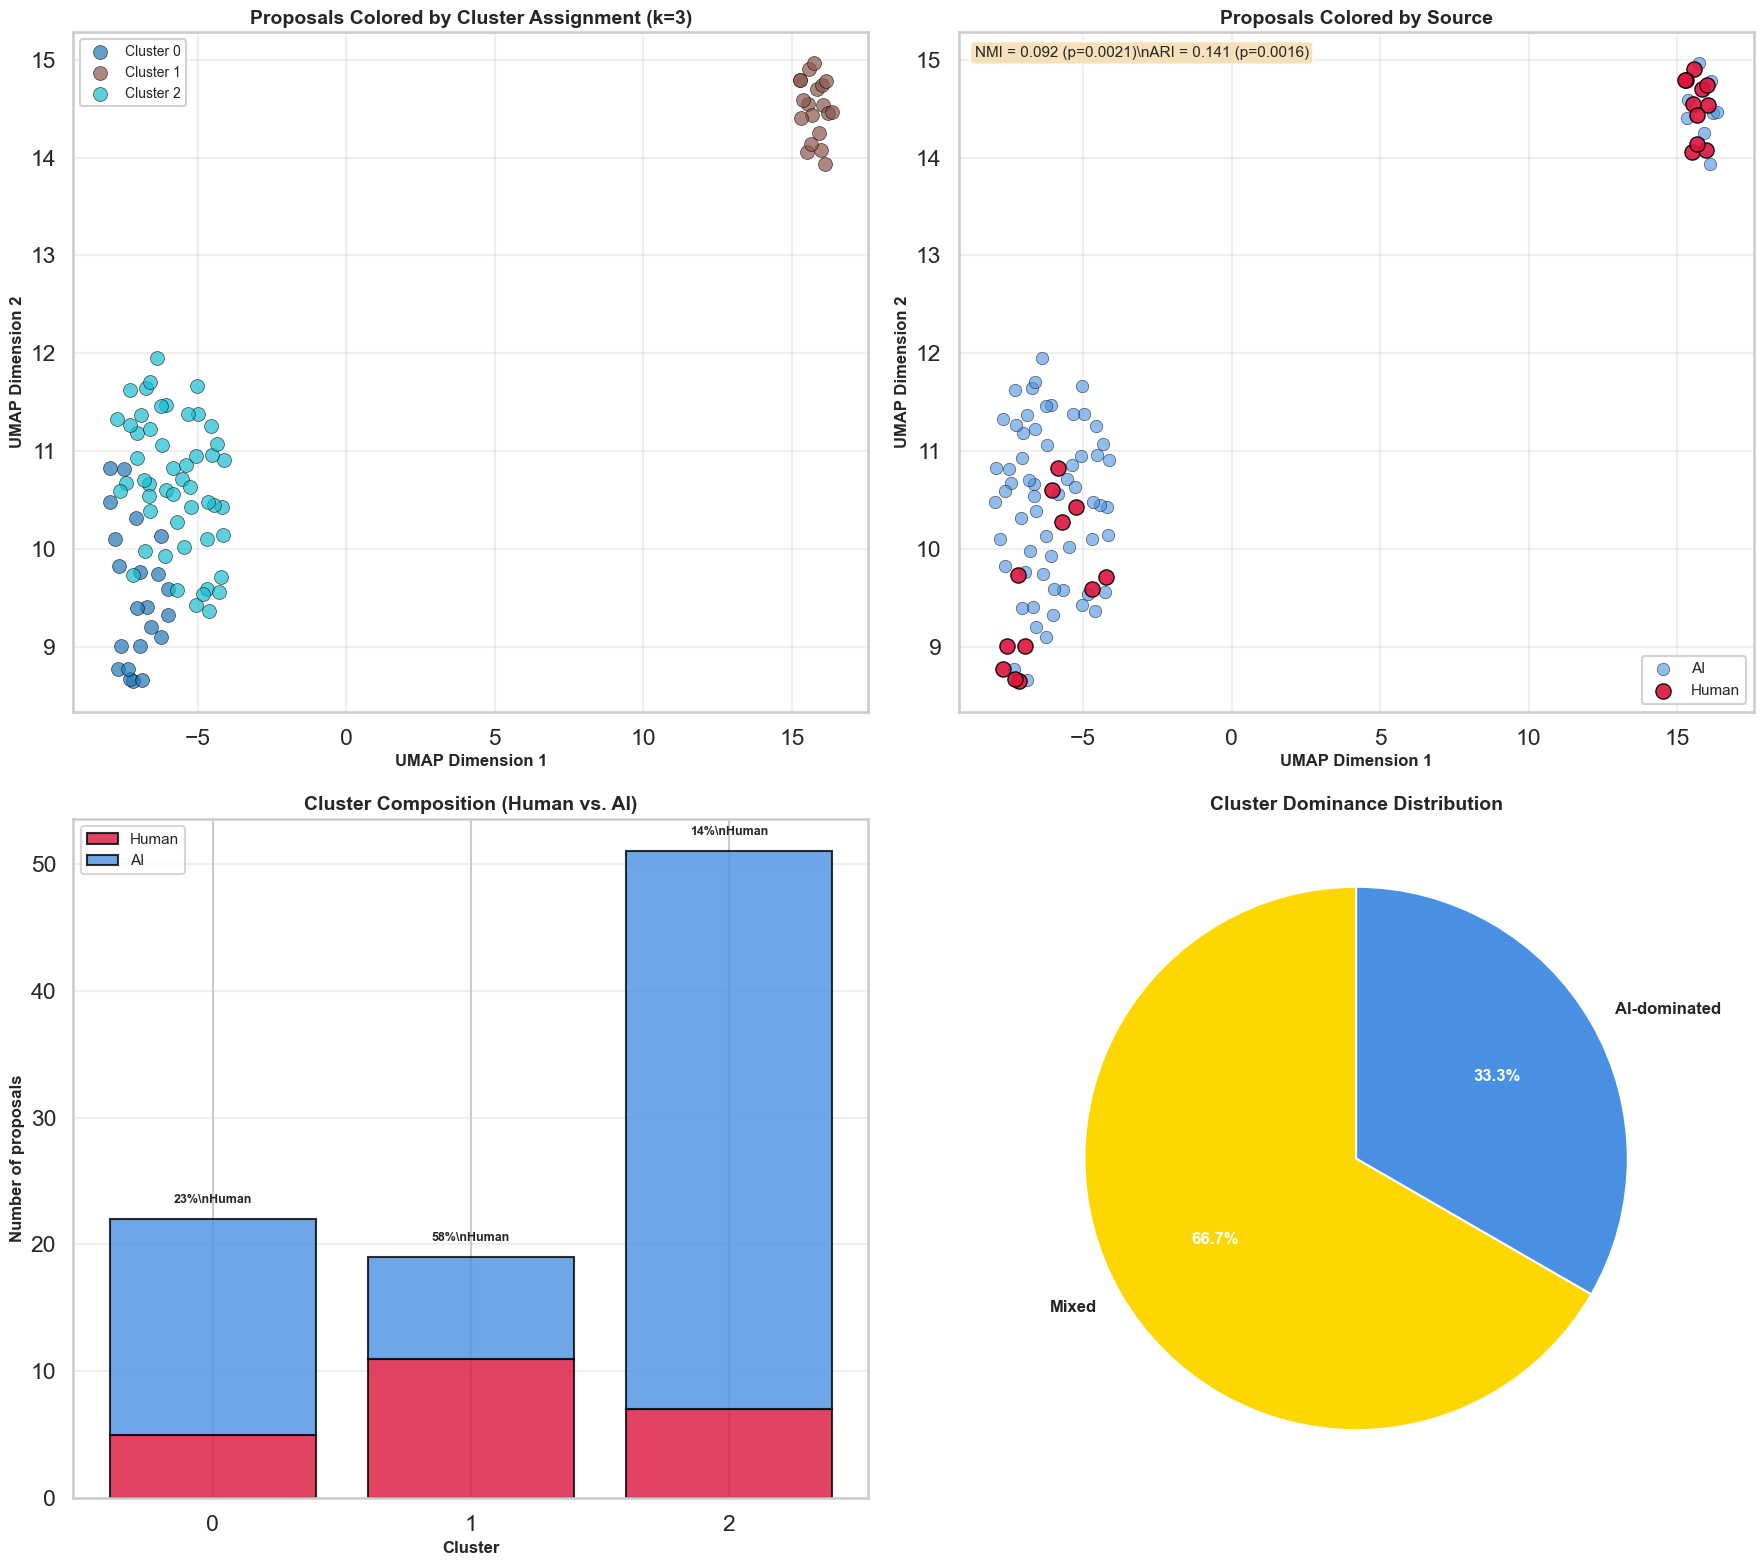

✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/cluster_analysis_visualization.png


In [160]:
import umap
# Visualization: Cluster analysis in 2D embedding space
print("="*85)
print("CLUSTER ANALYSIS: STEP 4 - VISUALIZATION")
print("="*85)

# Use existing UMAP projection from earlier analysis
# Apply UMAP if not already done for this combined set
print("Reducing to 2D with UMAP for visualization...")

reducer_cluster = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d_cluster = reducer_cluster.fit_transform(all_embeddings_cluster)

print(f"✓ UMAP projection complete: {embeddings_2d_cluster.shape}")

# Create 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Color schemes
source_colors = {'Human': '#DC143C', 'AI': '#4A90E2'}
cluster_colors = plt.cm.tab10(np.linspace(0, 1, best_k))

# Panel 1: Colored by cluster assignment
ax1 = axes[0, 0]
for cluster_id in range(best_k):
    mask = cluster_labels_final == cluster_id
    ax1.scatter(embeddings_2d_cluster[mask, 0], embeddings_2d_cluster[mask, 1],
               c=[cluster_colors[cluster_id]], label=f'Cluster {cluster_id}',
               s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax1.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax1.set_title(f'Proposals Colored by Cluster Assignment (k={best_k})', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(alpha=0.3)

# Panel 2: Colored by source (Human vs. AI)
ax2 = axes[0, 1]
for source in ['AI', 'Human']:  # Plot AI first, Human on top
    mask = source_labels_cluster == source
    ax2.scatter(embeddings_2d_cluster[mask, 0], embeddings_2d_cluster[mask, 1],
               c=source_colors[source], label=source,
               s=120 if source == 'Human' else 80, 
               alpha=0.9 if source == 'Human' else 0.6,
               edgecolors='black', linewidth=1.0 if source == 'Human' else 0.5)

ax2.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax2.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax2.set_title('Proposals Colored by Source', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=11, framealpha=0.9)
ax2.grid(alpha=0.3)

# Add NMI and ARI as text
textstr = f'NMI = {nmi_observed:.3f} (p={p_nmi:.4f})\\nARI = {ari_observed:.3f} (p={p_ari:.4f})'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Panel 3: Cluster composition (stacked bar chart)
ax3 = axes[1, 0]
cluster_ids = composition_df['cluster'].values
human_counts = composition_df['human'].values
ai_counts = composition_df['ai'].values

ax3.bar(cluster_ids, human_counts, label='Human', color='#DC143C', alpha=0.8, edgecolor='black')
ax3.bar(cluster_ids, ai_counts, bottom=human_counts, label='AI', color='#4A90E2', alpha=0.8, edgecolor='black')

ax3.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of proposals', fontsize=12, fontweight='bold')
ax3.set_title('Cluster Composition (Human vs. AI)', fontsize=14, fontweight='bold')
ax3.set_xticks(cluster_ids)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, cluster_id in enumerate(cluster_ids):
    total = composition_df.loc[i, 'total']
    pct_h = composition_df.loc[i, 'pct_human']
    ax3.text(cluster_id, total + 1, f'{pct_h:.0f}%\\nHuman', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 4: Cluster dominance pie chart
ax4 = axes[1, 1]
dominance_counts = composition_df['dominance'].value_counts()
colors_pie = {'Human-dominated': '#DC143C', 'AI-dominated': '#4A90E2', 'Mixed': '#FFD700'}
pie_colors = [colors_pie.get(d, 'gray') for d in dominance_counts.index]

wedges, texts, autotexts = ax4.pie(dominance_counts.values, labels=dominance_counts.index, 
                                     autopct='%1.1f%%', startangle=90,
                                     colors=pie_colors, textprops={'fontsize': 12, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax4.set_title('Cluster Dominance Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_analysis_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {FIGURES_DIR / 'cluster_analysis_visualization.png'}")
print("="*85)

### PART III Summary

In [161]:
print("="*85)
print("ANALYSIS 2.3: THEMATIC AND CLUSTER ANALYSIS - COMPREHENSIVE SUMMARY")
print("="*85)

if 'p_entropy' not in globals():
    p_entropy = p_two_sided if 'p_two_sided' in globals() else np.nan

print()
print("="*85)
print("1. TOPIC MODELING (LDA with n=5 topics)")
print("="*85)
print("  Model: Latent Dirichlet Allocation")
print("  Parameters: alpha=0.5, beta=0.5 (strong regularization)")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print("  Topics identified:")
for i, topic_words in enumerate(topics):
    print(f"    Topic {i+1}: {', '.join(topic_words[:5])}...")

print()
print("="*85)
print("2. TOPIC DISTRIBUTION COMPARISON")
print("="*85)
print("  Overall distribution test (permutation):")
print(f"    Chi-square: {observed_chi2:.4f}, p={p_value_perm:.4f}")
if p_value_perm < 0.05:
    print("    → Significant difference in topic distributions")
else:
    print("    → No significant difference in topic distributions")

print("  Per-topic tests (Fisher's exact with FDR correction):")
significant_topics = fisher_df[fisher_df['p_value_fdr'] < 0.10]
if len(significant_topics) > 0:
    print(f"    {len(significant_topics)} topics show significant over/under-representation:")
    for _, row in significant_topics.iterrows():
        direction = 'Human' if row['odds_ratio'] > 1 else 'AI'
        print(f"      {row['topic']}: OR={row['odds_ratio']:.2f}, p_fdr={row['p_value_fdr']:.4f} ({direction}↑)")
else:
    print("    No topics show significant over/under-representation (FDR q=0.10)")

print()
print("="*85)
print("3. TOPIC COVERAGE AND ENTROPY")
print("="*85)
print("  Coverage (topics with >20% probability):")
print(f"    Human: {human_coverage}/{n_topics} topics")
print(f"    AI: {ai_coverage}/{n_topics} topics")
print("  Exclusive topics (≥5 proposals):")
print(f"    Human-exclusive: {len(human_exclusive)} (p={p_human:.4f})")
print(f"    AI-exclusive: {len(ai_exclusive)} (p={p_ai:.4f})")
print("  Shannon entropy (Miller-Madow corrected):")
print(f"    Human: H={human_entropy:.4f}, H_norm={human_norm_entropy:.4f}")
print(f"    AI (subsampled): H={subsample_entropies.mean():.4f}±{subsample_entropies.std():.4f}")
print(f"    Difference (two-sided): p={p_entropy:.4f}")

print()
print("="*85)
print(f"4. CLUSTER ANALYSIS (GMM with k={best_k})")
print("="*85)
print("  Model selection:")
print(f"    Best k by BIC: {best_k}")
print(f"    Silhouette score: {metrics_df.loc[metrics_df['k']==best_k, 'silhouette'].values[0]:.4f}")
print("  Cluster composition:")
print(f"    Human-dominated clusters: {(composition_df['dominance']=='Human-dominated').sum()}")
print(f"    AI-dominated clusters: {(composition_df['dominance']=='AI-dominated').sum()}")
print(f"    Mixed clusters: {(composition_df['dominance']=='Mixed').sum()}")
print("  Segregation metrics:")
print(f"    NMI: {nmi_observed:.4f} (null: {nmi_null.mean():.4f}±{nmi_null.std():.4f}, p={p_nmi:.4f})")
print(f"    ARI: {ari_observed:.4f} (null: {ari_null.mean():.4f}±{ari_null.std():.4f}, p={p_ari:.4f})")
print(f"    Between/Within distance ratio: {between_within_ratio:.4f} (p={p_ratio:.4f})")

print()
print("="*85)
print("OVERALL INTERPRETATION")
print("="*85)
if p_value_perm < 0.05:
    print("✓ Topics: Human and AI differ in topic distributions")
else:
    print("✓ Topics: No significant difference in topic distributions")

if np.isfinite(p_entropy) and p_entropy < 0.05:
    if diff > 0:
        print("✓ Entropy: Human proposals show higher thematic diversity")
    else:
        print("✓ Entropy: AI proposals show higher thematic diversity")
else:
    print("✓ Entropy: Similar thematic diversity between groups")

if p_nmi < 0.05 or p_ari < 0.05:
    print("✓ Clustering: SEGREGATION - Human and AI occupy distinct semantic regions")
    print("  → Generate different KINDS of ideas")
elif p_nmi > 0.10 and p_ari > 0.10:
    print("✓ Clustering: INTEGRATION - Human and AI ideas are intermixed")
    print("  → Similar ideas regardless of source")
else:
    print("✓ Clustering: INTERMEDIATE - Some thematic patterns but not strict segregation")

print()
print("⚠️  LIMITATIONS:")
print("  • Small sample size (n=23 human, n=69 AI)")
print("  • Topic modeling labeled as EXPLORATORY")
print("  • Results should be validated with larger samples")
print("  • Segregation may reflect prompt differences, not inherent ideation differences")

print()
print("="*85)
print("📊 FIGURES GENERATED:")
print("="*85)
print(f"  1. {FIGURES_DIR / 'cluster_k_selection.png'}")
print(f"  2. {FIGURES_DIR / 'topic_distribution_comparison.png'}")
print(f"  3. {FIGURES_DIR / 'cluster_analysis_visualization.png'}")
print("="*85)


ANALYSIS 2.3: THEMATIC AND CLUSTER ANALYSIS - COMPREHENSIVE SUMMARY

1. TOPIC MODELING (LDA with n=5 topics)
  Model: Latent Dirichlet Allocation
  Parameters: alpha=0.5, beta=0.5 (strong regularization)
  Perplexity: 194.33
  Topics identified:
    Topic 1: synthesis, emergent, dynamics, decoding, multi...
    Topic 2: proteomics, imaging, emergent, emergence, synthesizing...
    Topic 3: data, emergent, synthesizing, structural, understand...

2. TOPIC DISTRIBUTION COMPARISON
  Overall distribution test (permutation):
    Chi-square: 0.8361, p=0.5990
    → No significant difference in topic distributions
  Per-topic tests (Fisher's exact with FDR correction):
    No topics show significant over/under-representation (FDR q=0.10)

3. TOPIC COVERAGE AND ENTROPY
  Coverage (topics with >20% probability):
    Human: 3/3 topics
    AI: 3/3 topics
  Exclusive topics (≥5 proposals):
    Human-exclusive: 0 (p=1.0000)
    AI-exclusive: 0 (p=1.0000)
  Shannon entropy (Miller-Madow corrected):
 

----------------------------
# PART IV Style Baseline

Before interpreting embedding distances, clustering segregation (NMI/ARI), or topic separation as “conceptual” differences, quantify how much **purely stylistic** signals can separate Human vs. AI. If a style-only model predicts source well, then a substantial portion of downstream “segregation/diversity” effects may be stylistic rather than conceptual.

### Exract stylistic features

In [162]:
# =============================================================================
# ANALYSIS 2.3.5–2.3.6: STYLE VS CONTENT (Baseline + Style-Controlled Sensitivity)
# Text scope: full proposals (full_text)
# =============================================================================

import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ----------------------------
# Style feature extraction
# ----------------------------

_HEDGE_WORDS = {
    'may','might','could','can','suggest','suggests','suggested','potential','potentially',
    'likely','unlikely','possibly','possible','approximately','estimate','estimated',
    'hypothesize','hypothesis','we propose','we aim','we will','we plan'
}

def _tokenize_words(text: str):
    return re.findall(r"[A-Za-z']+", text.lower())

def _split_sentences(text: str):
    # lightweight sentence split for readability/stylistic counts
    sents = re.split(r"[.!?]+\s+|\n+", text.strip())
    return [s for s in (sent.strip() for sent in sents) if s]

def _count_syllables(word: str) -> int:
    # heuristic syllable counter (good enough for comparative readability proxies)
    w = re.sub(r"[^a-z]", "", word.lower())
    if not w:
        return 0
    w = re.sub(r"e$", "", w)  # silent e
    groups = re.findall(r"[aeiouy]+", w)
    return max(1, len(groups))

def _flesch_kincaid(text: str):
    words = _tokenize_words(text)
    n_words = len(words)
    sents = _split_sentences(text)
    n_sents = len(sents)
    if n_words == 0 or n_sents == 0:
        return np.nan, np.nan
    syllables = sum(_count_syllables(w) for w in words)

    # Flesch Reading Ease & FK Grade Level (English)
    fre = 206.835 - 1.015 * (n_words / n_sents) - 84.6 * (syllables / n_words)
    fkgl = 0.39 * (n_words / n_sents) + 11.8 * (syllables / n_words) - 15.59
    return fre, fkgl

def extract_style_features(text: str) -> dict:
    text = text or ""
    words = _tokenize_words(text)
    n_words = len(words)
    n_chars = len(text)
    sents = _split_sentences(text)
    n_sents = len(sents)

    uniq = len(set(words)) if n_words else 0
    ttr = (uniq / n_words) if n_words else 0.0

    stop_ct = sum(1 for w in words if w in ENGLISH_STOP_WORDS)
    stop_rate = (stop_ct / n_words) if n_words else 0.0

    avg_word_len = (np.mean([len(w) for w in words]) if n_words else 0.0)
    avg_sent_len = (n_words / n_sents) if n_sents else 0.0

    # punctuation / formatting (normalized)
    punct = {
        'comma': text.count(','),
        'semicolon': text.count(';'),
        'colon': text.count(':'),
        'dash': text.count('-') + text.count('–') + text.count('—'),
        'paren': text.count('(') + text.count(')'),
        'quote': text.count('"') + text.count("'"),
        'newline': text.count('\n'),
        'bullet': len(re.findall(r"(^|\n)\s*[-*•]\s+", text))
    }
    punct_rate = {f"{k}_per_1k_chars": (v / max(1, n_chars)) * 1000.0 for k, v in punct.items()}

    # hedging / stance
    low = text.lower()
    hedge_hits = 0
    # count single-token hedges
    hedge_hits += sum(1 for w in words if w in _HEDGE_WORDS)
    # count a few multiword patterns
    hedge_hits += len(re.findall(r"\bwe\s+(propose|aim|plan|will)\b", low))
    hedge_rate = (hedge_hits / n_words) if n_words else 0.0

    # simple headers / sectioning markers (your full_text includes e.g., "Title:", "Abstract:")
    header_lines = 0
    for line in (ln.strip() for ln in text.splitlines()):
        if re.match(r"^[A-Z][A-Za-z0-9 /-]{1,40}:\s+", line):
            header_lines += 1
    header_rate = header_lines

    fre, fkgl = _flesch_kincaid(text)

    feats = {
        'n_words': n_words,
        'n_chars': n_chars,
        'n_sents': n_sents,
        'avg_word_len': avg_word_len,
        'avg_sent_len_words': avg_sent_len,
        'type_token_ratio': ttr,
        'stopword_rate': stop_rate,
        'hedge_rate': hedge_rate,
        'flesch_reading_ease': fre,
        'fk_grade_level': fkgl,
    }
    feats.update(punct_rate)
    return feats

# Build style feature table (full proposals)
human_texts_style = human_df['full_text'].fillna('').tolist()
ai_texts_style = ai_df['full_text'].fillna('').tolist()
all_texts_style = human_texts_style + ai_texts_style

style_rows = [extract_style_features(t) for t in all_texts_style]
style_df = pd.DataFrame(style_rows)
style_df['group'] = (['Human'] * len(human_texts_style)) + (['AI'] * len(ai_texts_style))
style_df['is_ai'] = (style_df['group'] == 'AI').astype(int)

print("="*85)
print("STYLE FEATURES: EXTRACTED")
print("="*85)
print(f"✓ Built style feature table: {style_df.shape[0]} docs × {style_df.shape[1]-2} features")
print(style_df.groupby('group')[['avg_sent_len_words','stopword_rate','hedge_rate','fk_grade_level']].mean().round(3))


STYLE FEATURES: EXTRACTED
✓ Built style feature table: 92 docs × 18 features
       avg_sent_len_words  stopword_rate  hedge_rate  fk_grade_level
group                                                               
AI                 18.341          0.296         0.0          17.932
Human              18.378          0.293         0.0          17.642


In [163]:
# Save: style features with titles
import pandas as pd; from pathlib import Path
out_dir = TABLES_DIR; out_dir.mkdir(parents=True, exist_ok=True)
titles = ([r.get('proposal_title', r.get('title','')) for r in human_metadata]
        + [r.get('title', r.get('proposal_title','')) for r in ai_metadata])
out = style_df.copy().reset_index(drop=True)
out.insert(0, 'title', titles)
out.to_csv(out_dir/'style_features.csv', index=False)
print(f"Saved style_features.csv  ({len(out)} rows x {len(out.columns)} cols)")


Saved style_features.csv  (92 rows x 21 cols)


#### Visualization: Style feature distributions by group (Human vs each AI model)

**How to read:** Each subplot is one style feature.
- The **box** shows median (center line) and IQR (25th–75th percentile).
- The **black diamond** is the mean, and the **error bar** is ±1 standard deviation.

This makes it easy to compare **median vs mean** (skew/outliers) and overall spread across Human and each AI model.

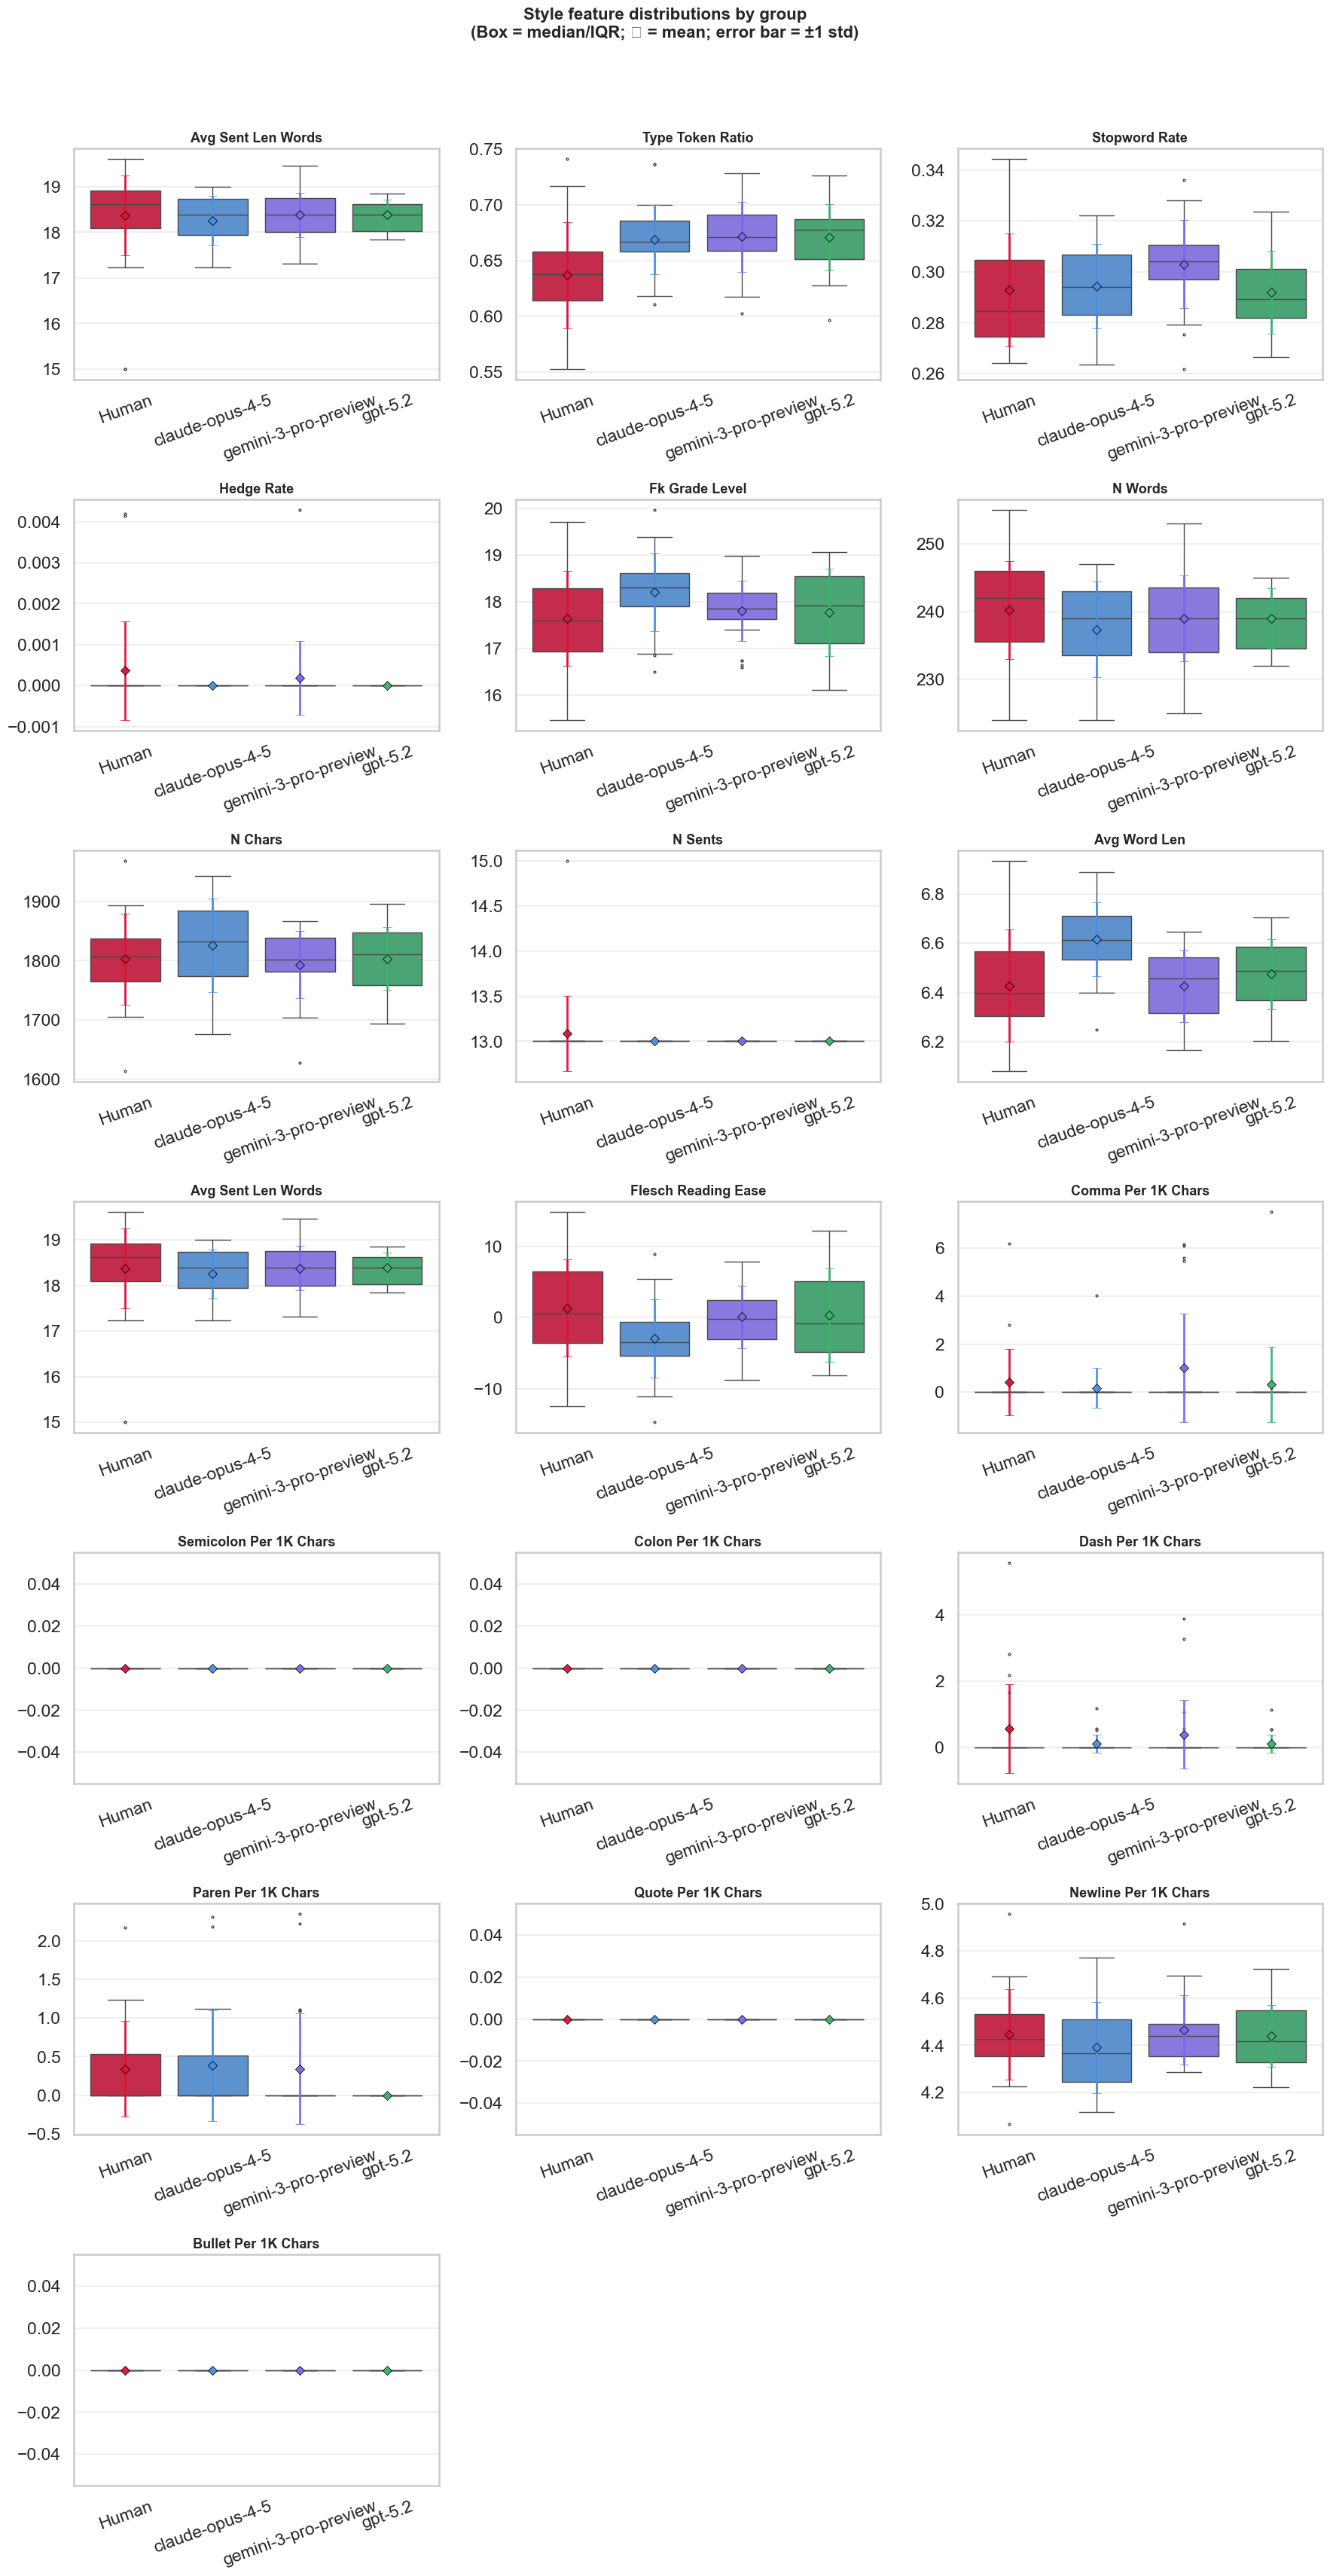

✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/style_features_by_model_boxplots.png

Summary (mean / median / std) by group:
                     avg_sent_len_words                type_token_ratio               stopword_rate               hedge_rate               fk_grade_level                 n_words                 n_chars                 n_sents               avg_word_len               avg_sent_len_words                flesch_reading_ease               comma_per_1k_chars               semicolon_per_1k_chars             colon_per_1k_chars             dash_per_1k_chars               paren_per_1k_chars               quote_per_1k_chars             newline_per_1k_chars               bullet_per_1k_chars            
                                   mean  median    std             mean median    std          mean median    std       mean median    std           mean  median    std     mean median    std      mean  median     std    m

In [164]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots per feature across Human and each AI model
# Box = median/IQR, whiskers = spread, ◆ = mean, error bar = ±1 std

if 'style_df' not in globals():
    raise RuntimeError("style_df not found. Run the style feature extraction cell first.")
if 'ai_df' not in globals():
    raise RuntimeError("ai_df not found. Run the AI proposal loading cell first.")

# Reconstruct per-model labels aligned to style_df construction order: Human rows first, then AI rows
n_h = int((style_df['group'] == 'Human').sum()) if 'group' in style_df.columns else 0
if n_h == 0:
    n_h = len(human_df)

ai_model_labels = ai_df['model'].tolist()
expected_ai = len(style_df) - n_h
if len(ai_model_labels) != expected_ai:
    raise ValueError(
        f"Alignment error: style_df has {len(style_df)} rows with n_h={n_h}, expected {expected_ai} AI rows, "
        f"but ai_df['model'] has {len(ai_model_labels)} labels."
    )

style_plot = style_df.copy()
style_plot['group_model'] = (['Human'] * n_h) + ai_model_labels

# Compact, interpretable features for quick comparison
features_to_plot = [
    'avg_sent_len_words',
    'type_token_ratio',
    'stopword_rate',
    'hedge_rate',
    'fk_grade_level',
    'header_lines', 'n_words', 'n_chars', 'n_sents', 'avg_word_len', 'avg_sent_len_words', 'flesch_reading_ease', 'comma_per_1k_chars', 'semicolon_per_1k_chars', 'colon_per_1k_chars', 'dash_per_1k_chars', 'paren_per_1k_chars', 'quote_per_1k_chars', 'newline_per_1k_chars', 'bullet_per_1k_chars'
]
# features_to_plot = [f for f in features_to_plot if f in style_plot.columns]
features_to_plot = [f for f in features_to_plot if f in style_plot.columns]
# Prepare long DF
long_df = style_plot[['group_model'] + features_to_plot].replace([np.inf, -np.inf], np.nan)
for f in features_to_plot:
    long_df[f] = long_df[f].fillna(long_df[f].median())
long_df = long_df.melt(id_vars='group_model', var_name='feature', value_name='value')

# Group order (Human first, then models)
if 'ai_models' in globals():
    group_order = ['Human'] + [m for m in ai_models if m in set(style_plot['group_model'])]
else:
    group_order = ['Human'] + sorted([m for m in style_plot['group_model'].unique() if m != 'Human'])

# Plot subplots
n_feat = len(features_to_plot)
ncols = 3
nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.8 * nrows))
axes = np.array(axes).reshape(-1)

# Use consistent group colors if defined earlier in the notebook
if 'colors' in globals() and isinstance(colors, dict):
    colors_local = dict(colors)
else:
    colors_local = {}

# Ensure every group has a color (fallback for any missing keys)
for idx, g in enumerate(group_order):
    colors_local.setdefault(g, f"C{idx % 10}")

palette_dict = {g: colors_local[g] for g in group_order}

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    df_f = long_df[long_df['feature'] == feat]

    # Boxes colored by group
    sns.boxplot(
        data=df_f, x='group_model', y='value', order=group_order,
        ax=ax, palette=palette_dict, fliersize=2
    )

    # Overlay mean ± std as colored diamonds (matches group color)
    stats = df_f.groupby('group_model')['value'].agg(['mean', 'std']).reindex(group_order)
    for xpos, g in enumerate(group_order):
        if g not in stats.index or pd.isna(stats.loc[g, 'mean']):
            continue
        m = float(stats.loc[g, 'mean'])
        s = float(stats.loc[g, 'std']) if not pd.isna(stats.loc[g, 'std']) else 0.0
        ax.errorbar(
            xpos, m, yerr=s,
            fmt='D',
            color=colors_local[g], ecolor=colors_local[g],
            elinewidth=2, capsize=4,
            markersize=6,
            markeredgecolor='black', markeredgewidth=0.6,
            alpha=0.95,
            zorder=10
        )

    ax.set_title(feat.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Style feature distributions by group\n(Box = median/IQR; ◆ = mean; error bar = ±1 std)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

out_path = FIGURES_DIR / 'style_features_by_model_boxplots.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {out_path}")

# Print a compact table of mean/median/std
summary = style_plot.groupby('group_model')[features_to_plot].agg(['mean', 'median', 'std']).round(3)
print("\nSummary (mean / median / std) by group:")
print(summary.to_string())

### Analysis 2.3.5: Style-only baseline (can style predict source?)

In [165]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

print("="*85)
print("STYLE-ONLY BASELINE: HUMAN VS AI")
print("="*85)

feature_cols = [c for c in style_df.columns if c not in {'group','is_ai'}]
print(f"features: {feature_cols}")
X = style_df[feature_cols].replace([np.inf, -np.inf], np.nan).values
y = style_df['is_ai'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced', solver='liblinear', random_state=42)
)

auc_scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
bal_scores = cross_val_score(clf, X, y, cv=cv, scoring='balanced_accuracy')

print(f"CV AUROC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
print(f"CV balanced accuracy: {bal_scores.mean():.3f} ± {bal_scores.std():.3f}")

obs_score, perm_scores, p_value = permutation_test_score(
    clf, X, y, cv=cv, scoring='roc_auc', n_permutations=1000, n_jobs=-1, random_state=42
)

print()
print("Permutation test (AUROC, 1,000 label shuffles):")
print(f"  Observed AUROC: {obs_score:.3f}")
print(f"  Null mean AUROC: {perm_scores.mean():.3f} ± {perm_scores.std():.3f}")
print(f"  p-value: {p_value:.4f}")
print("  Note: Imputation now occurs INSIDE each CV fold (no leakage).")

if obs_score >= 0.80:
    print("  → Strong evidence that style alone separates Human vs AI.")
elif obs_score >= 0.60:
    print("  → Moderate evidence that style contributes to separation.")
else:
    print("  → Style-only separation is weak; downstream separation is less likely to be purely stylistic.")


STYLE-ONLY BASELINE: HUMAN VS AI
features: ['n_words', 'n_chars', 'n_sents', 'avg_word_len', 'avg_sent_len_words', 'type_token_ratio', 'stopword_rate', 'hedge_rate', 'flesch_reading_ease', 'fk_grade_level', 'comma_per_1k_chars', 'semicolon_per_1k_chars', 'colon_per_1k_chars', 'dash_per_1k_chars', 'paren_per_1k_chars', 'quote_per_1k_chars', 'newline_per_1k_chars', 'bullet_per_1k_chars']
CV AUROC: 0.561 ± 0.166
CV balanced accuracy: 0.584 ± 0.117

Permutation test (AUROC, 1,000 label shuffles):
  Observed AUROC: 0.561
  Null mean AUROC: 0.504 ± 0.098
  p-value: 0.2977
  Note: Imputation now occurs INSIDE each CV fold (no leakage).
  → Style-only separation is weak; downstream separation is less likely to be purely stylistic.


In [166]:
# ── Most predictive STYLE features (interpretable coefficients) ───────────────
import numpy as np
import pandas as pd

print("="*85)
print("TOP STYLE FEATURES PREDICTING AI VS HUMAN (LogReg coefficients)")
print("="*85)

# Fit the SAME pipeline on all data for interpretation
clf.fit(X, y)

# Pull fitted components
imputer = clf.named_steps['simpleimputer']
scaler  = clf.named_steps['standardscaler']
logreg  = clf.named_steps['logisticregression']

# Feature names from the current cell
feature_names = list(feature_cols)

# Coefs correspond to *scaled* features (comparable magnitudes)
coefs = logreg.coef_.ravel()  # shape: (n_features,)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

k = min(15, len(coef_df))

print(f"\nTop {k} strongest predictors (by |coef|):")
print(coef_df.head(k)[['feature','coef']].to_string(index=False))

# Directional lists
ai_like = coef_df.sort_values('coef', ascending=False).head(k)[['feature','coef']]
human_like = coef_df.sort_values('coef', ascending=True).head(k)[['feature','coef']]

print(f"\nTop {k} features pushing prediction toward AI (positive coef):")
print(ai_like.to_string(index=False))

print(f"\nTop {k} features pushing prediction toward Human (negative coef):")
print(human_like.to_string(index=False))

print("\nNote: coefficients are on standardized features (after imputation + scaling).")
print("      Positive = more AI-like; Negative = more Human-like.")


TOP STYLE FEATURES PREDICTING AI VS HUMAN (LogReg coefficients)

Top 15 strongest predictors (by |coef|):
               feature      coef
      type_token_ratio  0.794931
               n_sents -0.535994
    comma_per_1k_chars  0.415146
         stopword_rate  0.374591
            hedge_rate -0.368857
   flesch_reading_ease -0.296825
        fk_grade_level  0.287558
               n_words -0.230170
     dash_per_1k_chars -0.205762
               n_chars -0.188495
  newline_per_1k_chars  0.114311
          avg_word_len  0.081602
    paren_per_1k_chars  0.070145
    avg_sent_len_words  0.027845
semicolon_per_1k_chars  0.000000

Top 15 features pushing prediction toward AI (positive coef):
               feature      coef
      type_token_ratio  0.794931
    comma_per_1k_chars  0.415146
         stopword_rate  0.374591
        fk_grade_level  0.287558
  newline_per_1k_chars  0.114311
          avg_word_len  0.081602
    paren_per_1k_chars  0.070145
    avg_sent_len_words  0.027845
    qu

#### Visualization: Style-only baseline results (CV + permutation test)

**How to read:** Left panel shows cross-validation fold performance (each dot = one CV fold; box = distribution). Right panel shows the permutation-test *null* distribution of AUROC when Human/AI labels are shuffled; the vertical red line is the observed AUROC—if it sits far in the right tail, style alone separates groups beyond chance (small p-value).

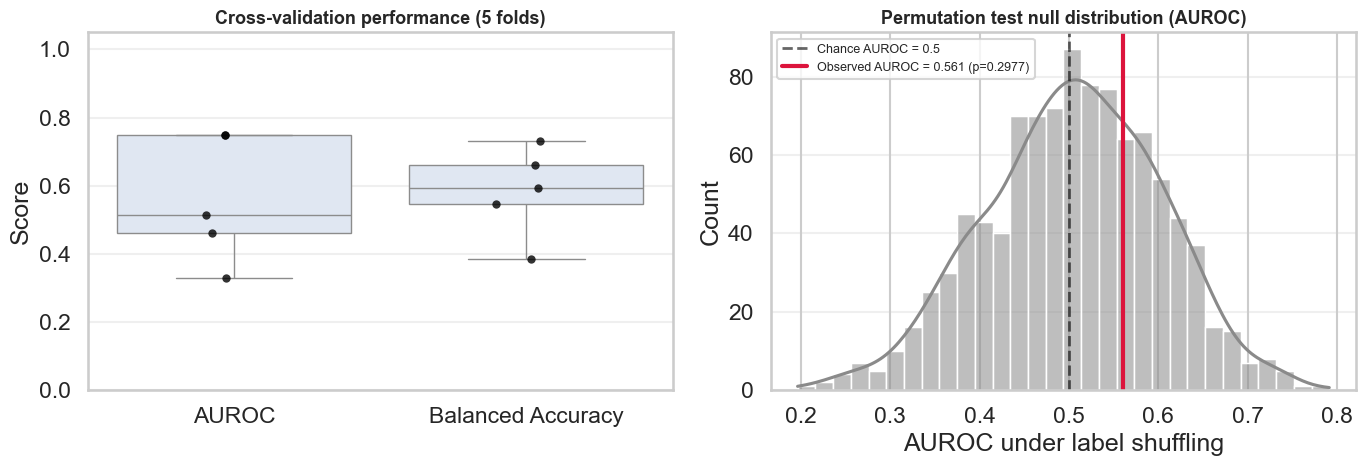

✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/style_only_baseline_viz.png

Interpretation:
- Left: tighter boxes/points = stable CV estimates; higher = better separation.
- Right: if the red line is far to the right of the gray histogram, the result is unlikely under chance (small p).


In [167]:
# Visualization for style-only baseline results
import matplotlib.pyplot as plt

# 1) CV fold distributions (AUROC + balanced accuracy)
cv_plot_df = pd.DataFrame({
    'Fold': np.arange(1, len(auc_scores) + 1),
    'AUROC': auc_scores,
    'Balanced Accuracy': bal_scores,
})
cv_long = cv_plot_df.melt(id_vars='Fold', var_name='Metric', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CV score distributions
ax = axes[0]
sns.boxplot(data=cv_long, x='Metric', y='Score', ax=ax, color='#DDE6F5', fliersize=2)
sns.stripplot(data=cv_long, x='Metric', y='Score', ax=ax, color='black', size=6, jitter=0.12, alpha=0.8)
ax.set_title('Cross-validation performance (5 folds)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0.0, 1.05)
ax.grid(axis='y', alpha=0.3)

# Right: permutation null distribution
ax = axes[1]
sns.histplot(perm_scores, bins=30, kde=True, ax=ax, color='#8A8A8A', alpha=0.55)
ax.axvline(0.5, color='black', linestyle='--', linewidth=2, alpha=0.6, label='Chance AUROC = 0.5')
ax.axvline(obs_score, color='crimson', linestyle='-', linewidth=3,
           label=f'Observed AUROC = {obs_score:.3f} (p={p_value:.4f})')
ax.set_title('Permutation test null distribution (AUROC)', fontsize=13, fontweight='bold')
ax.set_xlabel('AUROC under label shuffling')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()

out_path = FIGURES_DIR / 'style_only_baseline_viz.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {out_path}")
print("\nInterpretation:")
print("- Left: tighter boxes/points = stable CV estimates; higher = better separation.")
print("- Right: if the red line is far to the right of the gray histogram, the result is unlikely under chance (small p).")

### Analysis 2.3.6A: Style-controlled sensitivity via residualization

In [168]:
import pickle
from pathlib import Path
import numpy as np

# ── Load embeddings from cache if not already in scope ───────────────────────
if 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    _emb_path = PROPOSAL_EMBEDDINGS_FILE
    if not _emb_path.exists():
        legacy_paths = sorted(_emb_path.parent.glob('proposal_embeddings_[0-9]*.pkl'))
        if not legacy_paths:
            raise FileNotFoundError(f"No embedding cache found at {_emb_path}. Run the embedding cell first.")
        _emb_path = legacy_paths[-1]
    _data = pickle.load(open(_emb_path, 'rb'))
    human_embeddings = _data['human_embeddings']
    ai_embeddings    = _data['ai_embeddings']
    human_metadata   = _data['human_metadata']
    ai_metadata      = _data['ai_metadata']
    print(f"Loaded embeddings from {_emb_path.name}  "
          f"(human={human_embeddings.shape}, ai={ai_embeddings.shape})")

from sklearn.metrics.pairwise import cosine_distances

print("="*85)
print("STYLE-CONTROLLED EMBEDDING OUTCOMES (RESIDUALIZATION)")
print("="*85)

if 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found in workspace variables (expected `human_embeddings` and `ai_embeddings`).")
else:
    # Align document order: Human first, then AI (matches style_df build above)
    E_h = np.asarray(human_embeddings)
    E_a = np.asarray(ai_embeddings)
    E = np.vstack([E_h, E_a])
    group = np.array([0] * len(E_h) + [1] * len(E_a))  # 0=Human, 1=AI

    # Style covariates (compact set)
    cov_cols = [c for c in style_df.columns if c not in {'group', 'is_ai'}]  # all style features
    cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    cov = StandardScaler().fit_transform(cov)

    # Outcomes from embeddings
    centroid_all = E.mean(axis=0, keepdims=True)
    dist_to_all = cosine_distances(E, centroid_all).ravel()

    centroid_h = E_h.mean(axis=0, keepdims=True)
    centroid_a = E_a.mean(axis=0, keepdims=True)
    dist_to_group = np.where(group == 0,
                             cosine_distances(E, centroid_h).ravel(),
                             cosine_distances(E, centroid_a).ravel())

    def _ols_group_coef(y, g, covariates):
        X = np.column_stack([np.ones(len(y)), g.astype(float), covariates])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        return beta[1], beta

    def perm_test_group_coef(y, g, covariates, n_perm=5000, seed=42):
        rng = np.random.default_rng(seed)
        obs_coef, _ = _ols_group_coef(y, g, covariates)
        null = np.zeros(n_perm, dtype=float)
        for i in range(n_perm):
            g_perm = rng.permutation(g)
            null[i], _ = _ols_group_coef(y, g_perm, covariates)
        p_two = (np.mean(np.abs(null) >= abs(obs_coef)) + 1) / (n_perm + 1)
        return obs_coef, null, p_two

    def summarize_outcome(name, y):
        mean_h = float(np.mean(y[group == 0]))
        mean_a = float(np.mean(y[group == 1]))
        print(f"\nOutcome: {name}")
        print(f"  Unadjusted means: Human={mean_h:.4f}, AI={mean_a:.4f}, (AI-Human)={mean_a-mean_h:+.4f}")
        coef, null, p = perm_test_group_coef(y, group, cov, n_perm=5000, seed=42)
        print(f"  Style-adjusted group coef (AI indicator): {coef:+.6f}")
        print(f"  Permutation p (two-sided, 5,000 shuffles): {p:.4f}")

    summarize_outcome('Cosine distance to overall centroid', dist_to_all)
    summarize_outcome('Cosine distance to own-group centroid', dist_to_group)


STYLE-CONTROLLED EMBEDDING OUTCOMES (RESIDUALIZATION)

Outcome: Cosine distance to overall centroid
  Unadjusted means: Human=0.2872, AI=0.1011, (AI-Human)=-0.1861
  Style-adjusted group coef (AI indicator): -0.174962
  Permutation p (two-sided, 5,000 shuffles): 0.0002

Outcome: Cosine distance to own-group centroid
  Unadjusted means: Human=0.2413, AI=0.0945, (AI-Human)=-0.1468
  Style-adjusted group coef (AI indicator): -0.151039
  Permutation p (two-sided, 5,000 shuffles): 0.0002


### Style-adjusted centroid dispersion (All Groups vs Human)


These tests repeat the same Mann–Whitney U, Cliff’s delta, and permutation test comparisons as the unadjusted centroid-dispersion section, but using **style-adjusted (residualized)** distances-to-own-group-centroid.

Compute each proposal’s distance-to-its-group-centroid (y_raw).
Fit a simple linear model: y_raw ~ (style features).
Subtract the model’s prediction from y_raw to get a residual.
Add back the overall mean (just to keep numbers on a similar scale).
Result: y_adj = “dispersion after removing what style can explain”.
Statistical tests on style-adjusted dispersion:
Same tests, just run on y_adj instead of y_raw.
So your MW / Cliff’s delta / permutation test become: “Are groups still different in dispersion after removing style effects?”

In [169]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

print("\n" + "="*85)
print("STATISTICAL TESTS: Style-adjusted Centroid Dispersion (All Groups vs Human)")
print("="*85)

# ---- helpers (define if not already in notebook) ----
if 'cliffs_delta' not in globals():
    def cliffs_delta(x, y):
        """Cliff's delta: P(x>y) - P(x<y)."""
        x = np.asarray(x)
        y = np.asarray(y)
        gt = 0
        lt = 0
        for xi in x:
            gt += np.sum(xi > y)
            lt += np.sum(xi < y)
        return (gt - lt) / (len(x) * len(y))

if 'interpret_cliffs_delta' not in globals():
    def interpret_cliffs_delta(d):
        ad = abs(d)
        if ad < 0.147:
            return 'negligible'
        if ad < 0.33:
            return 'small'
        if ad < 0.474:
            return 'medium'
        return 'large'

def _perm_test_mean_diff(x, y, n_perm=10000, seed=42):
    """Two-sided permutation test on mean difference: mean(x)-mean(y).

    Named uniquely to avoid conflicts with any earlier `permutation_test()` defined elsewhere in the notebook.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    obs = float(np.mean(x) - np.mean(y))
    pooled = np.concatenate([x, y])
    n_x = len(x)
    null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        null[i] = float(np.mean(perm[:n_x]) - np.mean(perm[n_x:]))
    p = (np.mean(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)
    return p, obs, null

# ---- compute y_adj robustly (don’t assume previous cell variables exist) ----
if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
elif 'ai_df' not in globals() or 'model_embeddings_dict' not in globals():
    print("⚠️ ai_df/model_embeddings_dict not found. Run the proposal loading/embedding setup cells first.")
else:
    # Align document order: Human first, then AI (matches style_df build above)
    E_h = np.asarray(human_embeddings)
    E_a = np.asarray(ai_embeddings)
    E = np.vstack([E_h, E_a])
    n_h, n_a = len(E_h), len(E_a)

    # Labels (Human first, then AI per-model)
    ai_model_labels = ai_df['model'].tolist()
    assert len(ai_model_labels) == n_a, "ai_df['model'] length must match ai_embeddings"
    labels = np.array((['Human'] * n_h) + ai_model_labels)

    # Group order consistent with earlier analyses
    if 'ai_models' in globals():
        ai_models_local = list(ai_models)
    else:
        ai_models_local = sorted(ai_df['model'].dropna().unique().tolist())
    group_order = ['Human'] + [m for m in ai_models_local if m in set(ai_model_labels)]

    # Raw distance-to-own-group-centroid
    y_raw = np.zeros(len(labels), dtype=float)
    for g in group_order:
        idx = np.where(labels == g)[0]
        if len(idx) == 0:
            continue
        centroid = E[idx].mean(axis=0, keepdims=True)
        y_raw[idx] = cosine_distances(E[idx], centroid).ravel()

    # Style residualization on y_raw
    _STYLE_CONTROL_COLS = [
        'avg_word_len', 'type_token_ratio', 'avg_sent_len_words',
        'flesch_reading_ease', 'dash_per_1k_chars',
    ]
    cov_cols = [c for c in _STYLE_CONTROL_COLS if c in style_df.columns]
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(y_raw)), X_cov])
    beta, *_ = np.linalg.lstsq(X, y_raw, rcond=None)
    y_pred = X @ beta
    y_adj = (y_raw - y_pred) + y_raw.mean()

    # Split adjusted distances
    human_adj = y_adj[labels == 'Human']
    ai_adj = y_adj[labels != 'Human']

    model_adj = {m: y_adj[labels == m] for m in group_order if m != 'Human'}

    # ---- tests ----
    adj_comparison_results = []

    print("\n" + "-"*85)
    print("Comparison: All AI (combined) vs Human [STYLE-ADJUSTED]")
    print("-"*85)

    u_stat, p_mw = mannwhitneyu(ai_adj, human_adj, alternative='two-sided')
    d = cliffs_delta(ai_adj, human_adj)
    d_interp = interpret_cliffs_delta(d)
    p_perm, obs_diff, _ = _perm_test_mean_diff(ai_adj, human_adj, n_perm=10000, seed=42)

    print("\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat:,.0f}, p-value: {p_mw:.4e}")
    print("\nCliff's Delta:")
    print(f"  δ = {d:.4f} ({d_interp} effect)")
    if d > 0:
        print("  → All AI proposals are MORE dispersed from center (after style adjustment)")
    else:
        print("  → Human proposals are MORE dispersed from center (after style adjustment)")
    print("\nPermutation Test (10,000 permutations):")
    print(f"  Observed difference (mean AI - mean Human): {obs_diff:.4f}, p-value: {p_perm:.4f}")

    adj_comparison_results.append({
        'group': 'All AI',
        'u_stat': u_stat,
        'p_value_mw': p_mw,
        'delta': d,
        'delta_interp': d_interp,
        'p_value_perm': p_perm
    })

    for model in group_order:
        if model == 'Human':
            continue
        vals = model_adj.get(model)
        if vals is None or len(vals) == 0:
            continue

        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human [STYLE-ADJUSTED]")
        print("-"*85)

        u_stat_m, p_mw_m = mannwhitneyu(vals, human_adj, alternative='two-sided')
        d_m = cliffs_delta(vals, human_adj)
        d_interp_m = interpret_cliffs_delta(d_m)
        p_perm_m, obs_diff_m, _ = _perm_test_mean_diff(vals, human_adj, n_perm=10000, seed=42)

        print("\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_m:,.0f}, p-value: {p_mw_m:.4e}")
        print("\nCliff's Delta:")
        print(f"  δ = {d_m:.4f} ({d_interp_m} effect)")
        if d_m > 0:
            print(f"  → {model} proposals are MORE dispersed from center (after style adjustment)")
        else:
            print("  → Human proposals are MORE dispersed from center (after style adjustment)")
        print("\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference (mean {model} - mean Human): {obs_diff_m:.4f}, p-value: {p_perm_m:.4f}")

        adj_comparison_results.append({
            'group': model,
            'u_stat': u_stat_m,
            'p_value_mw': p_mw_m,
            'delta': d_m,
            'delta_interp': d_interp_m,
            'p_value_perm': p_perm_m
        })

    # Summary table
    print("\n" + "="*85)
    print("SUMMARY: Effect Sizes (Cliff's Delta) - Style-adjusted Centroid Dispersion")
    print("="*85)
    print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
    print("-"*85)
    for r in adj_comparison_results:
        print(f"{r['group']:<30} {r['delta']:<12.4f} {r['delta_interp']:<20} {r['p_value_mw']:<15.4e}")
    print("="*85)
    print("\n💡 Positive δ = AI more dispersed; Negative δ = Human more dispersed (style-adjusted)")
    print("="*85)



STATISTICAL TESTS: Style-adjusted Centroid Dispersion (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human [STYLE-ADJUSTED]
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 187, p-value: 4.6478e-08

Cliff's Delta:
  δ = -0.7643 (large effect)
  → Human proposals are MORE dispersed from center (after style adjustment)

Permutation Test (10,000 permutations):
  Observed difference (mean AI - mean Human): -0.1284, p-value: 0.0001

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human [STYLE-ADJUSTED]
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 0, p-value: 6.6369e-09

Cliff's Delta:
  δ = -1.0000 (large effect)
  → Human proposals are MORE dispersed from center (after style adj

CENTROID DISPERSION: UNADJUSTED vs STYLE-ADJUSTED (RESIDUALIZED)


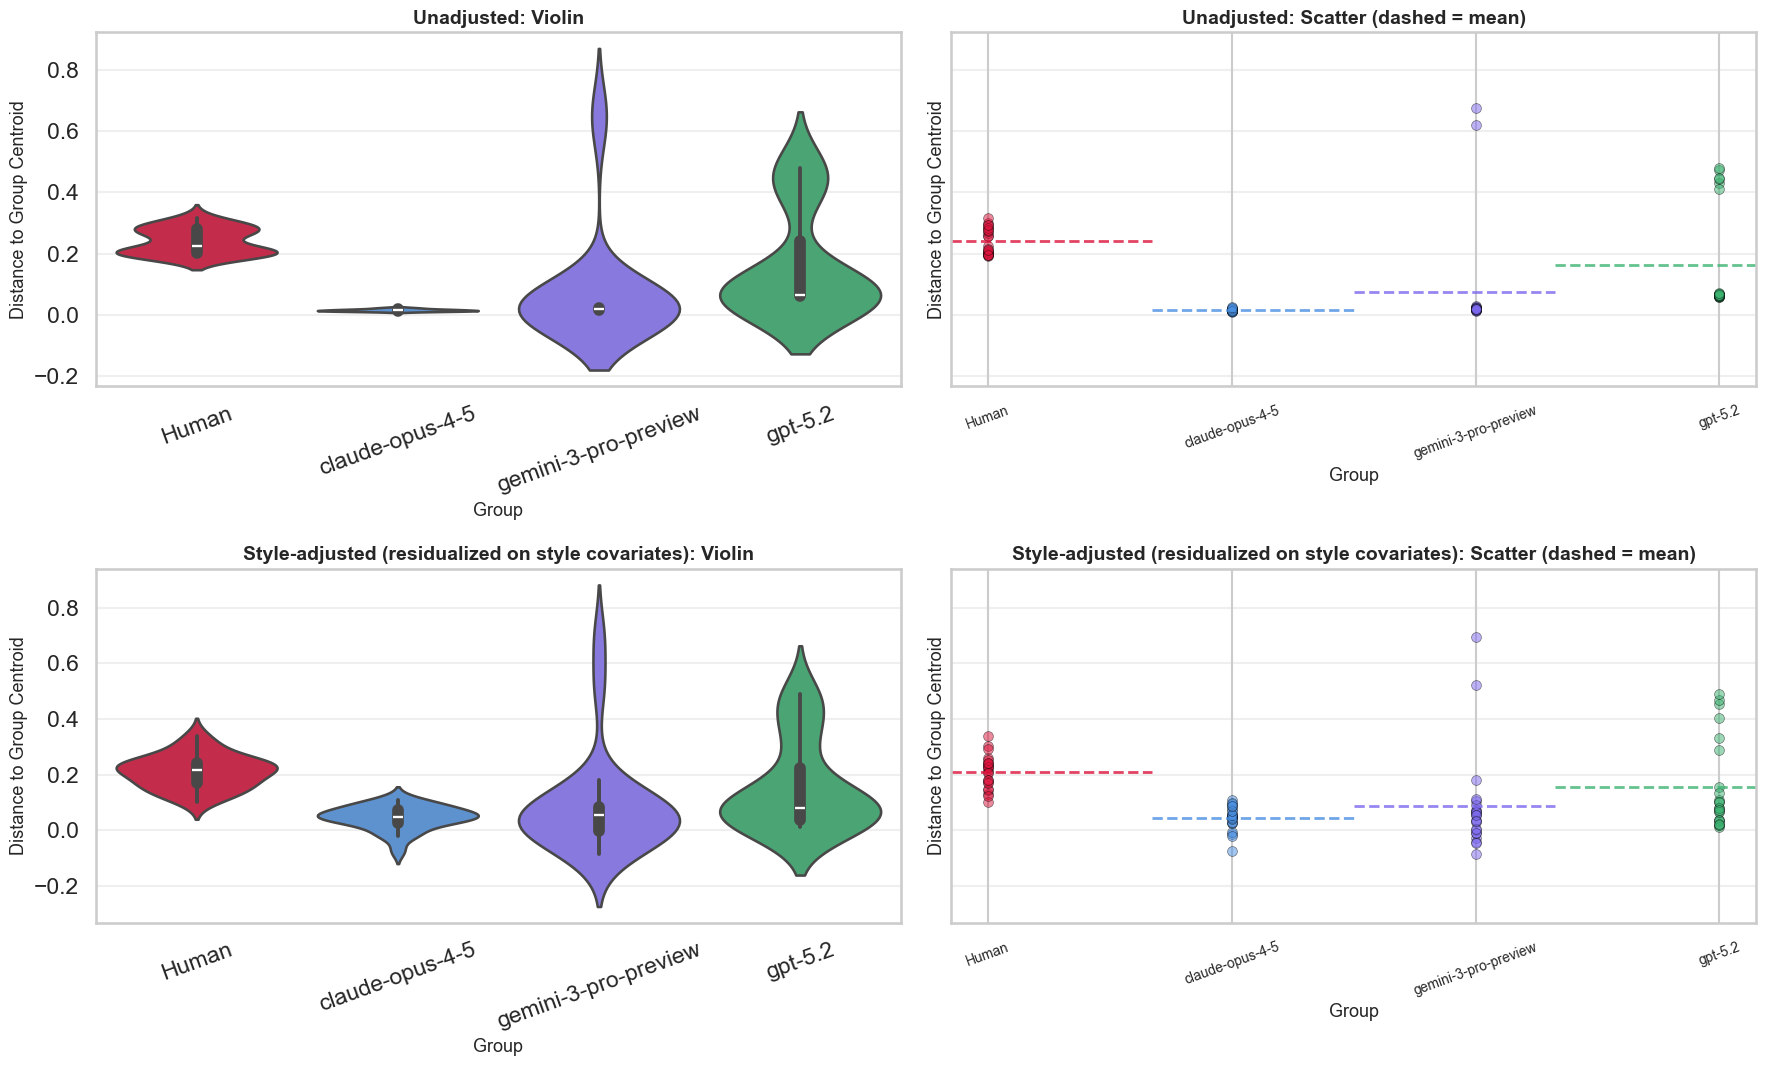

✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/centroid_dispersion_style_adjusted.png

Note: 'Style-adjusted' removes linear effects of selected style covariates (not group).


In [170]:
# ----------------------------
# Visualization: centroid dispersion before vs after style residualization
# ----------------------------

from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler

print("="*85)
print("CENTROID DISPERSION: UNADJUSTED vs STYLE-ADJUSTED (RESIDUALIZED)")
print("="*85)

if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
else:
    # Labels (Human first, then AI) — match the style_df construction order
    n_h = len(human_embeddings)
    n_a = len(ai_embeddings)

    # Prefer the notebook's model list if available; otherwise derive from ai_df
    if 'ai_models' in globals():
        ai_models_local = list(ai_models)
    else:
        ai_models_local = sorted(ai_df['model'].dropna().unique().tolist())

    ai_model_labels = ai_df['model'].tolist()
    assert len(ai_model_labels) == n_a, "ai_df['model'] length must match ai_embeddings"

    labels = np.array((['Human'] * n_h) + ai_model_labels)

    # Embeddings matrix
    E = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])

    # Compute distance-to-own-group-centroid for each proposal (Human + each AI model)
    group_order = ['Human'] + [m for m in ai_models_local if m in set(ai_model_labels)]

    y_raw = np.zeros(len(labels), dtype=float)
    for g in group_order:
        idx = np.where(labels == g)[0]
        if len(idx) == 0:
            continue
        centroid = E[idx].mean(axis=0, keepdims=True)
        y_raw[idx] = cosine_distances(E[idx], centroid).ravel()

    # Style residualization (remove linear effect of style covariates; keep scale comparable)
    cov_cols = [c for c in style_df.columns if c not in {'group', 'is_ai'}]  # all style features
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(y_raw)), X_cov])
    beta, *_ = np.linalg.lstsq(X, y_raw, rcond=None)
    y_pred = X @ beta
    y_adj = (y_raw - y_pred) + y_raw.mean()  # residuals shifted back to original mean

    # Colors: reuse if present, else define a fallback
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = colors
    else:
        colors_local = {'Human': '#DC143C'}
        for i, m in enumerate(group_order[1:]):
            colors_local[m] = f"C{(i+1)%10}"

    def _plot_row(ax_violin, ax_scatter, y, row_title):
        # Build long DF
        plot_df = pd.DataFrame({'Group': labels, 'Distance to Centroid': y})

        palette_list = [colors_local.get(g, 'gray') for g in group_order]

        sns.violinplot(
            data=plot_df, x='Group', y='Distance to Centroid',
            order=group_order, palette=palette_list, ax=ax_violin
        )
        ax_violin.set_ylabel('Distance to Group Centroid', fontsize=13)
        ax_violin.set_xlabel('Group', fontsize=13)
        ax_violin.set_title(f'{row_title}: Violin', fontsize=14, fontweight='bold')
        ax_violin.tick_params(axis='x', rotation=20)
        ax_violin.grid(alpha=0.3, axis='y')

        # Scatter with per-group mean lines
        for xpos, g in enumerate(group_order):
            vals = plot_df.loc[plot_df['Group'] == g, 'Distance to Centroid'].values
            if len(vals) == 0:
                continue
            ax_scatter.scatter(
                [xpos] * len(vals), vals,
                alpha=0.5, color=colors_local.get(g, 'gray'),
                s=50, edgecolors='black', linewidth=0.5
            )
            ax_scatter.axhline(
                np.mean(vals),
                xmin=xpos/len(group_order), xmax=(xpos+1)/len(group_order),
                color=colors_local.get(g, 'gray'), linestyle='--', linewidth=2, alpha=0.8
            )

        ax_scatter.set_xticks(range(len(group_order)))
        ax_scatter.set_xticklabels(group_order, rotation=20, fontsize=10)
        ax_scatter.set_ylabel('Distance to Group Centroid', fontsize=13)
        ax_scatter.set_xlabel('Group', fontsize=13)
        ax_scatter.set_title(f'{row_title}: Scatter (dashed = mean)', fontsize=14, fontweight='bold')
        ax_scatter.grid(alpha=0.3, axis='y')

    fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharey='row')
    _plot_row(axes[0, 0], axes[0, 1], y_raw, 'Unadjusted')
    _plot_row(axes[1, 0], axes[1, 1], y_adj, 'Style-adjusted (residualized on style covariates)')

    plt.tight_layout()
    out_path = FIGURES_DIR / 'centroid_dispersion_style_adjusted.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Figure saved to: {out_path}")
    print("\nNote: 'Style-adjusted' removes linear effects of selected style covariates (not group).")


### Style-adjust nearest-neighbor (NN) distances by residualizing embeddings


This removes the *linear* contribution of selected style covariates from the embedding vectors (dimension-wise OLS), then recomputes cosine NN distances on the residual embeddings (renormalized).

STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS (Metadata-aligned)

COMPUTING STYLE-ADJUSTED NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.2359     0.1848     0.0833     0.7390    

claude-opus-4-5                     23       0.2679     0.2400     0.1130     0.7115    
gemini-3-pro-preview                23       0.3104     0.2226     0.0873     0.7822    
gpt-5.2                             23       0.2640     0.2359     0.0833     0.7728    

All AI (combined)                   69       0.2808     0.2359     0.0833     0.7822    

💡 INTERPRETATION:
   - Higher mean NN distance = more isolated proposals (outliers)
   - Lower mean NN distance = proposals cluster together
   - Distances are computed AFTER removing linear embedding variation explained by style covariates

O

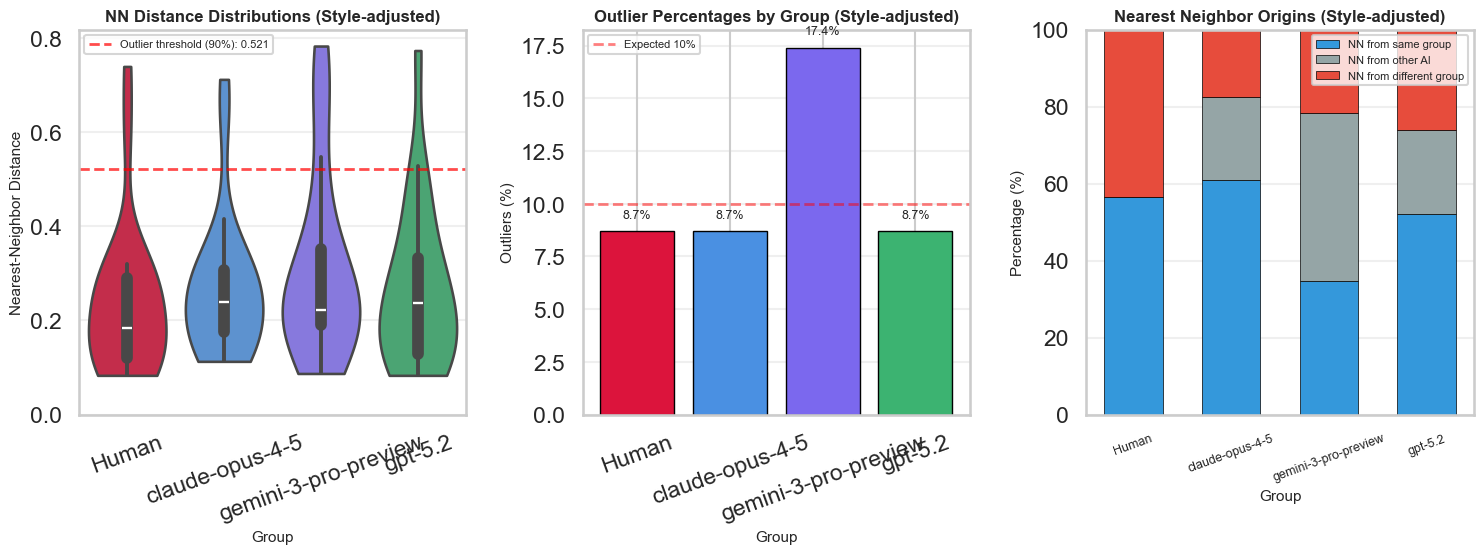


✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/nearest_neighbor_by_model_style_adjusted.png

Note: This mirrors the unadjusted NN pipeline, but all distances are computed in residual (style-adjusted) embedding space.


In [171]:
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

print("="*85)
print("STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS (Metadata-aligned)")
print("="*85)

if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
else:
    # ----------------------------
    # 0) Build per-row labels that match embedding order
    # ----------------------------
    n_human = len(human_embeddings)
    n_ai = len(ai_embeddings)

    if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_ai:
        ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
    elif 'ai_df' in globals() and len(ai_df) == n_ai and 'model' in ai_df.columns:
        print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
        ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
    else:
        raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

    labels = np.array((['Human'] * n_human) + ai_model_labels)

    # Stable group order
    if 'ai_models' in globals():
        ai_models_local = [m for m in list(ai_models) if m in set(ai_model_labels)]
    else:
        ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

    group_order = ['Human'] + ai_models_local

    # ----------------------------
    # 1) Build embedding matrix (Human first, then AI) and residualize on style
    # ----------------------------
    all_embeddings = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])

    # Control only for features that significantly separate Human from AI (from
    # the LogReg coefficients in cell 102 / PART IV Mann-Whitney analysis).
    # Using all 17 features risks absorbing semantic variance that correlates
    # with length (n_words, n_chars, n_sents are semantic proxies).
    _STYLE_CONTROL_COLS = [
        'avg_word_len',          # word complexity (AI uses shorter words)
        'type_token_ratio',      # vocabulary diversity (human higher)
        'avg_sent_len_words',    # sentence length (AI runs longer)
        'flesch_reading_ease',   # readability composite (correlated with above)
        'dash_per_1k_chars',     # hyphen usage (human uses more)
    ]
    cov_cols = [c for c in _STYLE_CONTROL_COLS if c in style_df.columns]
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(X_cov)), X_cov])

    B, *_ = np.linalg.lstsq(X, all_embeddings, rcond=None)
    all_embeddings_resid = all_embeddings - (X @ B)
    all_embeddings_resid = all_embeddings_resid / (np.linalg.norm(all_embeddings_resid, axis=1, keepdims=True) + 1e-12)

    # ----------------------------
    # 2) Compute full distance matrix + NN distances (STYLE-ADJUSTED)
    # ----------------------------
    print("\n" + "="*85)
    print("COMPUTING STYLE-ADJUSTED NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS")
    print("="*85)

    all_distances_adj = cosine_distances(all_embeddings_resid)
    np.fill_diagonal(all_distances_adj, np.inf)
    nn_distances_adj = all_distances_adj.min(axis=1)

    # Group-wise NN distances
    human_nn_dists_adj = nn_distances_adj[labels == 'Human']
    ai_nn_dists_adj = nn_distances_adj[labels != 'Human']

    model_nn_dists_adj = {g: nn_distances_adj[labels == g] for g in ai_models_local}

    # Print statistics table
    print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
    print("-"*85)
    print(f"{'Human':<35} {len(human_nn_dists_adj):<8} {human_nn_dists_adj.mean():<10.4f} {np.median(human_nn_dists_adj):<10.4f} {human_nn_dists_adj.min():<10.4f} {human_nn_dists_adj.max():<10.4f}")
    print()
    for model in ai_models_local:
        dists = model_nn_dists_adj[model]
        print(f"{model:<35} {len(dists):<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.min():<10.4f} {dists.max():<10.4f}")
    print()
    print(f"{'All AI (combined)':<35} {len(ai_nn_dists_adj):<8} {ai_nn_dists_adj.mean():<10.4f} {np.median(ai_nn_dists_adj):<10.4f} {ai_nn_dists_adj.min():<10.4f} {ai_nn_dists_adj.max():<10.4f}")

    print("="*85)
    print("\n💡 INTERPRETATION:")
    print("   - Higher mean NN distance = more isolated proposals (outliers)")
    print("   - Lower mean NN distance = proposals cluster together")
    print("   - Distances are computed AFTER removing linear embedding variation explained by style covariates")
    print("="*85)

    # ----------------------------
    # 3) Outlier detection (top 10% NN distances) - STYLE-ADJUSTED
    # ----------------------------
    threshold_adj = np.percentile(nn_distances_adj, 90)
    outliers_adj = nn_distances_adj > threshold_adj

    human_outliers_adj = int(outliers_adj[labels == 'Human'].sum())
    ai_outliers_adj = int(outliers_adj[labels != 'Human'].sum())
    model_outliers_adj = {g: int(outliers_adj[labels == g].sum()) for g in ai_models_local}

    print("\n" + "="*85)
    print("OUTLIER DETECTION (Top 10% NN distance) — STYLE-ADJUSTED")
    print("="*85)
    print(f"Threshold distance: {threshold_adj:.4f}")
    print()
    print(f"{'GROUP':<35} {'Outliers':<15} {'Total':<10} {'Percentage':<15}")
    print("-"*85)
    print(f"{'Human':<35} {human_outliers_adj:<15} {n_human:<10} {human_outliers_adj/n_human*100:<15.1f}%")
    print()
    for model in ai_models_local:
        n_model = int((labels == model).sum())
        print(f"{model:<35} {model_outliers_adj[model]:<15} {n_model:<10} {model_outliers_adj[model]/n_model*100:<15.1f}%")
    print()
    print(f"{'All AI (combined)':<35} {ai_outliers_adj:<15} {n_ai:<10} {ai_outliers_adj/n_ai*100:<15.1f}%")
    print("="*85)

    # ----------------------------
    # 4) Nearest-neighbor origin analysis — STYLE-ADJUSTED
    # ----------------------------
    nn_indices_adj = all_distances_adj.argmin(axis=1)
    nn_labels_adj = labels[nn_indices_adj]

    human_nn_same_group_adj = int((nn_labels_adj[labels == 'Human'] == 'Human').sum())
    human_nn_diff_group_adj = int(n_human - human_nn_same_group_adj)

    ai_nn_same_group_adj = int((nn_labels_adj[labels != 'Human'] != 'Human').sum())
    ai_nn_diff_group_adj = int(n_ai - ai_nn_same_group_adj)

    model_nn_analysis_adj = {}
    for model in ai_models_local:
        mask = labels == model
        total = int(mask.sum())
        nn_from_human = int((nn_labels_adj[mask] == 'Human').sum())
        nn_from_same_model = int((nn_labels_adj[mask] == model).sum())
        nn_from_other_ai = int(total - nn_from_human - nn_from_same_model)
        model_nn_analysis_adj[model] = {
            'from_human': nn_from_human,
            'from_same_model': nn_from_same_model,
            'from_other_ai': nn_from_other_ai,
            'total': total
        }

    print("\n" + "="*85)
    print("NEAREST NEIGHBOR GROUP ANALYSIS — STYLE-ADJUSTED")
    print("="*85)

    print(f"\n{'Human proposals:':<50}")
    print(f"  NN from same group (human): {human_nn_same_group_adj} ({human_nn_same_group_adj/n_human*100:.1f}%)")
    print(f"  NN from different group (AI): {human_nn_diff_group_adj} ({human_nn_diff_group_adj/n_human*100:.1f}%)")

    print(f"\n{'All AI proposals (combined):':<50}")
    print(f"  NN from same group (AI): {ai_nn_same_group_adj} ({ai_nn_same_group_adj/n_ai*100:.1f}%)")
    print(f"  NN from different group (human): {ai_nn_diff_group_adj} ({ai_nn_diff_group_adj/n_ai*100:.1f}%)")

    print("\n" + "-"*85)
    print("Per-Model NN Group Breakdown:")
    print("-"*85)

    for model in ai_models_local:
        data = model_nn_analysis_adj[model]
        print(f"\n{model}:")
        print(f"  NN from Human: {data['from_human']} ({data['from_human']/data['total']*100:.1f}%)")
        print(f"  NN from same model: {data['from_same_model']} ({data['from_same_model']/data['total']*100:.1f}%)")
        print(f"  NN from other AI models: {data['from_other_ai']} ({data['from_other_ai']/data['total']*100:.1f}%)")

    print("\n" + "="*85)
    print("\n💡 INTERPRETATION:")
    print("   - High 'NN from same model' = model produces similar proposals")
    print("   - High 'NN from Human' = model proposals resemble human work")
    print("   - All computed in style-adjusted residual embedding space")
    print("="*85)

    # ----------------------------
    # 5) Statistical tests vs Human (same tests) — STYLE-ADJUSTED
    # ----------------------------
    print("\n" + "="*85)
    print("STATISTICAL TESTS: NN Distances (All Groups vs Human) — STYLE-ADJUSTED")
    print("="*85)

    nn_comparison_results_adj = []

    print("\n" + "-"*85)
    print("Comparison: All AI (combined) vs Human")
    print("-"*85)

    u_stat_nn, p_value_nn = mannwhitneyu(ai_nn_dists_adj, human_nn_dists_adj, alternative='two-sided')
    delta_nn = cliffs_delta(ai_nn_dists_adj, human_nn_dists_adj)
    delta_nn_interp = interpret_cliffs_delta(delta_nn)
    p_value_perm_nn, obs_diff_nn, _ = permutation_test(ai_nn_dists_adj, human_nn_dists_adj)

    print(f"\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat_nn:,.0f}, p-value: {p_value_nn:.4e}")
    print(f"\nCliff's Delta:")
    print(f"  δ = {delta_nn:.4f} ({delta_nn_interp} effect)")
    if delta_nn > 0:
        print(f"  → All AI proposals have MORE unique/outlier ideas (style-adjusted)")
    else:
        print(f"  → Human proposals have MORE unique/outlier ideas (style-adjusted)")
    print(f"\nPermutation Test (10,000 permutations):")
    print(f"  Observed difference: {obs_diff_nn:.4f}, p-value: {p_value_perm_nn:.4f}")

    nn_comparison_results_adj.append({
        'group': 'All AI',
        'u_stat': u_stat_nn,
        'p_value_mw': p_value_nn,
        'delta': delta_nn,
        'delta_interp': delta_nn_interp,
        'p_value_perm': p_value_perm_nn
    })

    for model in ai_models_local:
        if model in model_nn_dists_adj:
            print("\n" + "-"*85)
            print(f"Comparison: {model} vs Human")
            print("-"*85)

            u_stat_model, p_value_mw_model = mannwhitneyu(model_nn_dists_adj[model], human_nn_dists_adj, alternative='two-sided')
            delta_model = cliffs_delta(model_nn_dists_adj[model], human_nn_dists_adj)
            delta_interp_model = interpret_cliffs_delta(delta_model)
            p_value_perm_model, obs_diff_model, _ = permutation_test(model_nn_dists_adj[model], human_nn_dists_adj)

            print(f"\nMann-Whitney U Test:")
            print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
            print(f"\nCliff's Delta:")
            print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
            if delta_model > 0:
                print(f"  → {model} proposals have MORE unique/outlier ideas (style-adjusted)")
            else:
                print(f"  → Human proposals have MORE unique/outlier ideas (style-adjusted)")
            print(f"\nPermutation Test (10,000 permutations):")
            print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")

            nn_comparison_results_adj.append({
                'group': model,
                'u_stat': u_stat_model,
                'p_value_mw': p_value_mw_model,
                'delta': delta_model,
                'delta_interp': delta_interp_model,
                'p_value_perm': p_value_perm_model
            })

    print("\n" + "="*85)
    print("SUMMARY: Effect Sizes (Cliff's Delta) - NN Distances (Style-adjusted)")
    print("="*85)
    print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
    print("-"*85)
    for result in nn_comparison_results_adj:
        print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
    print("="*85)
    print("\n💡 Positive δ = AI more outlier-prone; Negative δ = Human more outlier-prone (style-adjusted)")
    print("="*85)

    # ----------------------------
    # 6) Visualization (same 3-panel layout) — STYLE-ADJUSTED
    # ----------------------------
    fig = plt.figure(figsize=(18, 5))
    gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

    # Colors (reuse global mapping)
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = dict(colors)
    else:
        colors_local = {'Human': 'steelblue'}

    # 1. NN distance distributions by group
    ax1 = fig.add_subplot(gs[0, 0])
    nn_data = []
    for dist, label in [(human_nn_dists_adj, 'Human')] + [(model_nn_dists_adj[m], m) for m in ai_models_local if m in model_nn_dists_adj]:
        for val in dist:
            nn_data.append({'NN Distance': val, 'Group': label})

    nn_df = pd.DataFrame(nn_data)
    group_order_viz = ['Human'] + [m for m in ai_models_local if m in model_nn_dists_adj]
    palette_list = [colors_local.get(g, 'gray') for g in group_order_viz]

    sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list,
                   order=group_order_viz, cut=0)  # cut=0 clips KDE at data min/max (prevents negative bleed)
    ax1.axhline(threshold_adj, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold_adj:.3f}')
    ax1.set_ylim(bottom=0)  # hard floor at 0 as a second safety net
    ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
    ax1.set_xlabel('Group', fontsize=11)
    ax1.set_title('NN Distance Distributions (Style-adjusted)', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='x', rotation=20)
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3, axis='y')

    # 2. Outlier counts by group
    ax2 = fig.add_subplot(gs[0, 1])
    outlier_data = []
    outlier_data.append({'Group': 'Human', 'Outliers': human_outliers_adj, 'Total': n_human, 'Percentage': human_outliers_adj/n_human*100})
    for model in ai_models_local:
        if model in model_outliers_adj:
            n_model = len(model_embeddings_dict.get(model, []))
            outlier_data.append({'Group': model, 'Outliers': model_outliers_adj[model], 'Total': n_model, 'Percentage': model_outliers_adj[model]/n_model*100})

    outlier_df = pd.DataFrame(outlier_data)
    bars = ax2.bar(outlier_df['Group'], outlier_df['Percentage'], color=[colors_local.get(g, 'gray') for g in outlier_df['Group']], edgecolor='black', linewidth=1)
    ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
    ax2.set_ylabel('Outliers (%)', fontsize=11)
    ax2.set_xlabel('Group', fontsize=11)
    ax2.set_title('Outlier Percentages by Group (Style-adjusted)', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=20)
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3, axis='y')

    for bar, pct in zip(bars, outlier_df['Percentage']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    # 3. NN origins (stacked bar)
    ax3 = fig.add_subplot(gs[0, 2])

    groups = ['Human'] + [m for m in ai_models_local if m in model_nn_analysis_adj]
    nn_from_human_pcts = [human_nn_diff_group_adj/n_human*100]
    nn_from_same_pcts = [human_nn_same_group_adj/n_human*100]
    nn_from_other_ai_pcts = [0]

    for model in [m for m in ai_models_local if m in model_nn_analysis_adj]:
        data = model_nn_analysis_adj[model]
        nn_from_human_pcts.append(data['from_human']/data['total']*100)
        nn_from_same_pcts.append(data['from_same_model']/data['total']*100)
        nn_from_other_ai_pcts.append(data['from_other_ai']/data['total']*100)

    x_pos = np.arange(len(groups))
    width = 0.6

    p1 = ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
    p2 = ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
    bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
    p3 = ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

    ax3.set_ylabel('Percentage (%)', fontsize=11)
    ax3.set_xlabel('Group', fontsize=11)
    ax3.set_title('Nearest Neighbor Origins (Style-adjusted)', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(groups, rotation=20, fontsize=9)
    ax3.legend(fontsize=8, loc='upper right')
    ax3.grid(alpha=0.3, axis='y')
    ax3.set_ylim([0, 100])

    plt.tight_layout()
    out_fig = FIGURES_DIR / 'nearest_neighbor_by_model_style_adjusted.png'
    plt.savefig(out_fig, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Figure saved to: {out_fig}")
    print("\nNote: This mirrors the unadjusted NN pipeline, but all distances are computed in residual (style-adjusted) embedding space.")

### Visualization: Style-adjusted NN analysis in 2D (UMAP on residual embeddings)

This mirrors the unadjusted UMAP plot, but uses **style-residualized embeddings** (the same ones used to compute style-adjusted NN distances/outliers). It also prints a small diagnostic showing that style covariates have much weaker linear association with the embedding coordinates after residualization.

STYLE-ADJUSTED: UMAP PROJECTION FOR NN/OUTLIER ANALYSIS

Style-adjustment diagnostic (lower is better):
  Mean |corr(style covariate, PC score)| (raw embeddings):  0.1053
  Mean |corr(style covariate, PC score)| (residual embeddings): 0.0638

Reducing residual embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


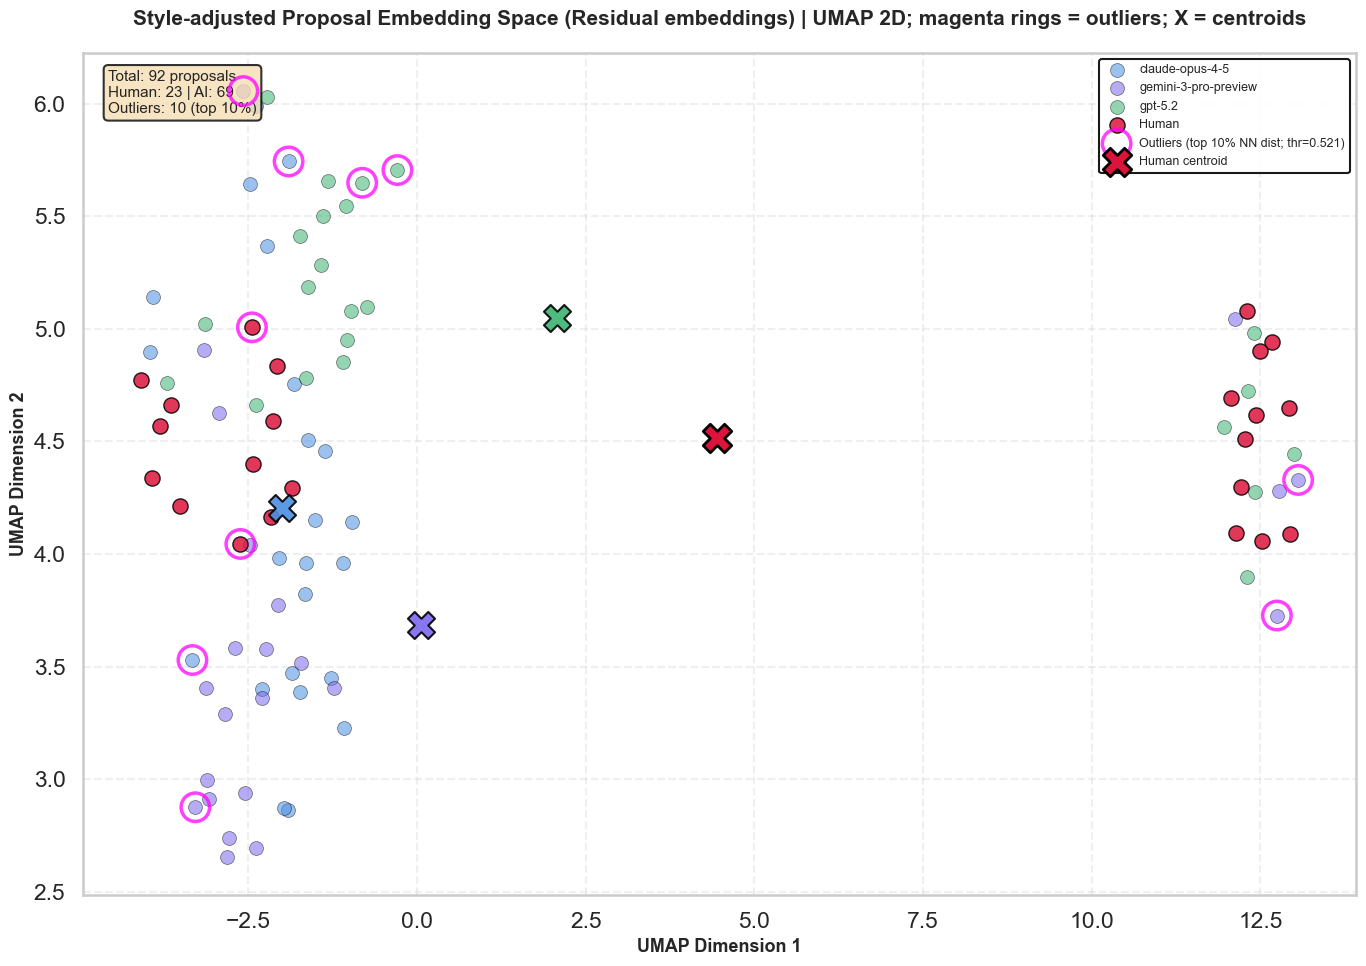


✓ Figure saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/embedding_space_2d_style_adjusted.png
💡 INTERPRETATION:
   - Clusters = similar proposals in style-adjusted residual space
   - Magenta rings = outliers by NN distance in residual space
   - X markers = group centroids in residual space


In [172]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("="*85)
print("STYLE-ADJUSTED: UMAP PROJECTION FOR NN/OUTLIER ANALYSIS")
print("="*85)

required_vars = ['all_embeddings_resid', 'outliers_adj', 'threshold_adj', 'n_human', 'n_ai', 'ai_models_local', 'model_embeddings_dict', 'labels']
missing = [v for v in required_vars if v not in globals()]
if missing:
    print(f"⚠️ Missing variables from prior style-adjusted NN cell: {missing}")
    print("Run the 'STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS' cell first.")
else:
    try:
        _STYLE_CONTROL_COLS = [
            'avg_word_len', 'type_token_ratio', 'avg_sent_len_words',
            'flesch_reading_ease', 'dash_per_1k_chars',
        ]
        cov_cols = [c for c in _STYLE_CONTROL_COLS if c in style_df.columns]
        X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
        X_cov = StandardScaler().fit_transform(X_cov)

        E_raw = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])
        E_raw = E_raw / (np.linalg.norm(E_raw, axis=1, keepdims=True) + 1e-12)
        E_adj = np.asarray(all_embeddings_resid)

        pca = PCA(n_components=10, random_state=42)
        Z_raw = pca.fit_transform(E_raw)
        Z_adj = pca.fit_transform(E_adj)

        def _mean_abs_corr(Z, X):
            corrs = []
            for i in range(Z.shape[1]):
                zi = Z[:, i]
                for j in range(X.shape[1]):
                    xj = X[:, j]
                    c = np.corrcoef(zi, xj)[0, 1]
                    if np.isfinite(c):
                        corrs.append(abs(c))
            return float(np.mean(corrs)) if corrs else np.nan

        raw_corr = _mean_abs_corr(Z_raw, X_cov)
        adj_corr = _mean_abs_corr(Z_adj, X_cov)

        print()
        print("Style-adjustment diagnostic (lower is better):")
        print(f"  Mean |corr(style covariate, PC score)| (raw embeddings):  {raw_corr:.4f}")
        print(f"  Mean |corr(style covariate, PC score)| (residual embeddings): {adj_corr:.4f}")
    except Exception as e:
        print()
        print(f"⚠️ Diagnostic skipped due to error: {e}")

    print()
    print("Reducing residual embeddings to 2D using UMAP...")
    reducer_adj = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='cosine', random_state=42)
    embeddings_2d_adj = reducer_adj.fit_transform(all_embeddings_resid)

    human_2d_adj = embeddings_2d_adj[:n_human]
    ai_2d_adj = embeddings_2d_adj[n_human:]
    model_2d_adj = {model: embeddings_2d_adj[labels == model] for model in ai_models_local}

    print(f"✓ UMAP completed: {len(embeddings_2d_adj)} proposals reduced to 2D")

    outlier_indices_adj = np.where(outliers_adj)[0]
    outlier_coords_adj = embeddings_2d_adj[outlier_indices_adj]

    colors_local = dict(colors) if 'colors' in globals() and isinstance(colors, dict) else {'Human': '#DC143C'}

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    for model in ai_models_local:
        mask = labels == model
        if mask.any():
            pts = embeddings_2d_adj[mask]
            ax.scatter(pts[:, 0], pts[:, 1], c=colors_local.get(model, '#808080'), label=model, s=100, alpha=0.55, edgecolors='black', linewidth=0.5)

    ax.scatter(human_2d_adj[:, 0], human_2d_adj[:, 1], c=colors_local.get('Human', '#DC143C'), label='Human', s=120, alpha=0.85, edgecolors='black', linewidth=1.0, marker='o', zorder=10)
    ax.scatter(outlier_coords_adj[:, 0], outlier_coords_adj[:, 1], s=420, facecolors='none', edgecolors='magenta', linewidth=2.5, alpha=0.75, label=f'Outliers (top 10% NN dist; thr={threshold_adj:.3f})', zorder=12)

    human_centroid_2d = human_2d_adj.mean(axis=0)
    ax.scatter(human_centroid_2d[0], human_centroid_2d[1], c=colors_local.get('Human', '#DC143C'), s=420, marker='X', edgecolors='black', linewidth=2, alpha=1.0, zorder=15, label='Human centroid')

    for model in ai_models_local:
        if model in model_2d_adj and len(model_2d_adj[model]) > 0:
            c2d = model_2d_adj[model].mean(axis=0)
            ax.scatter(c2d[0], c2d[1], c=colors_local.get(model, '#808080'), s=380, marker='X', edgecolors='black', linewidth=1.5, alpha=0.9, zorder=14)

    ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
    ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
    ax.set_title('Style-adjusted Proposal Embedding Space (Residual embeddings) | UMAP 2D; magenta rings = outliers; X = centroids', fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')
    ax.grid(True, alpha=0.3, linestyle='--')

    textstr = '\n'.join([
        f'Total: {len(embeddings_2d_adj)} proposals',
        f'Human: {n_human} | AI: {n_ai}',
        f'Outliers: {len(outlier_indices_adj)} (top 10%)'
    ])
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props)

    plt.tight_layout()
    out_path = FIGURES_DIR / 'embedding_space_2d_style_adjusted.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print()
    print(f"✓ Figure saved to: {out_path}")
    print("💡 INTERPRETATION:")
    print("   - Clusters = similar proposals in style-adjusted residual space")
    print("   - Magenta rings = outliers by NN distance in residual space")
    print("   - X markers = group centroids in residual space")
    print("="*85)


#### Outlier proposals (style-adjusted NN)

Print the titles of proposals flagged as **outliers** in the style-adjusted NN analysis (top 10% NN distance), along with whether they are Human or which AI model generated them.

In [173]:
import pandas as pd
import numpy as np

print("\n" + "="*85)
print("STYLE-ADJUSTED NN OUTLIERS: TITLES + AUTHOR")
print("="*85)

required = ['outliers_adj', 'threshold_adj', 'n_human']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"⚠️ Missing variables: {missing}")
    print("Run the style-adjusted NN analysis cell first.")
else:
    outlier_indices = np.where(outliers_adj)[0]
    n_total = int(len(outliers_adj))
    n_ai = int(n_total - n_human)

    # Get style-adjusted NN distances if available; otherwise recompute quickly
    if 'nn_distances_adj' in globals():
        nn_d = np.asarray(nn_distances_adj)
    elif 'all_distances_adj' in globals():
        nn_d = np.min(np.asarray(all_distances_adj), axis=1)
    elif 'all_embeddings_resid' in globals():
        from sklearn.metrics.pairwise import cosine_distances
        D = cosine_distances(np.asarray(all_embeddings_resid))
        np.fill_diagonal(D, np.inf)
        nn_d = D.min(axis=1)
    else:
        nn_d = None

    # Prefer metadata saved alongside embeddings (guaranteed to match embedding order)
    use_metadata = ('ai_metadata' in globals()) and ('human_metadata' in globals())
    if use_metadata:
        if len(human_metadata) != n_human or len(ai_metadata) != n_ai:
            print("⚠️ Metadata lengths do not match embedding counts; falling back to df-based lookup.")
            use_metadata = False

    rows = []
    for idx in outlier_indices:
        if idx < n_human:
            who = 'Human'
            model = 'Human'
            if use_metadata:
                rec = human_metadata[idx]
                title = rec.get('proposal_title', rec.get('title', ''))
            else:
                title = human_df.iloc[idx].get('proposal_title', human_df.iloc[idx].get('title', '')) if 'human_df' in globals() else ''
        else:
            ai_idx = idx - n_human
            who = 'AI'
            if use_metadata:
                rec = ai_metadata[ai_idx]
                model = str(rec.get('model', 'AI'))
                title = str(rec.get('title', ''))
            else:
                model = str(ai_df.iloc[ai_idx].get('model', '')) if 'ai_df' in globals() else 'AI'
                title = str(ai_df.iloc[ai_idx].get('title', '')) if 'ai_df' in globals() else ''

        rows.append({
            'global_index': int(idx),
            'who': who,
            'model': model,
            'nn_distance_style_adj': float(nn_d[idx]) if nn_d is not None else np.nan,
            'title': title
        })

    out_df = pd.DataFrame(rows).sort_values('nn_distance_style_adj', ascending=False)

    print(f"Outlier threshold (90th percentile): {threshold_adj:.4f}")
    print(f"Total outliers: {len(out_df)} / {n_total} ({len(out_df)/n_total*100:.1f}%)")
    print("Outliers by source (model):")
    print(out_df['model'].value_counts().to_string())

    with pd.option_context('display.max_colwidth', 140):
        display(out_df.reset_index(drop=True))



STYLE-ADJUSTED NN OUTLIERS: TITLES + AUTHOR
Outlier threshold (90th percentile): 0.5212
Total outliers: 10 / 92 (10.9%)
Outliers by source (model):
model
gemini-3-pro-preview    4
gpt-5.2                 2
Human                   2
claude-opus-4-5         2


,global_index,who,model,nn_distance_style_adj,title
0,51,AI,gemini-3-pro-preview,0.782234,Uncovering the Rules of Nucleolar Assembly and Ribosome Biogenesis Emergence
1,40,AI,gpt-5.2,0.772776,"A Cross-Species Synthesis of Autophagosome Biogenesis: Integrating Proteomics, Lipid Signatures, and Imaging Dynamics"
2,14,Human,Human,0.738968,Deciphering systemic biological networks through AI-driven multi-omic integration
3,83,AI,claude-opus-4-5,0.711531,"The Emergence of Signaling Specificity: Synthesizing Interaction, Localization, and Kinetic Data to Understand Pathway Insulation"
4,48,AI,gemini-3-pro-preview,0.701685,Synthesizing the Emergent Properties of Chromatin Topology and Epigenetic Memory
5,57,AI,gemini-3-pro-preview,0.699480,Emergent Cargo Sorting Dynamics in Extracellular Vesicle Biogenesis
6,72,AI,claude-opus-4-5,0.629669,"Emergent Properties of the Cellular Crowding Landscape: Synthesizing Biophysical, Structural, and Systems Data to Understand Macromolecu..."
7,20,Human,Human,0.598331,Predictive Synthesis Framework for Elucidating Biophysical Cell State from Spatial Transcriptomics and Proteomics
8,56,AI,gemini-3-pro-preview,0.545743,Synthesizing the Emergence of Autophagosomes at ER-Mitochondria Contact Sites
9,42,AI,gpt-5.2,0.527042,"A Community Meta-Analysis of Multivesicular Body and Exosome Biogenesis: Integrating ESCRT Networks, Proteomics, and Imaging"


# Save All Proposals to a Single JSON

Combine original proposal content, rephrased text, and every per-proposal metric computed in this notebook into one JSON file (`all_proposals.json`). Each record contains the original and rephrased text, plus all diversity, novelty, style, and review-score metrics for cross-validation.

In [174]:

import json as _json
import pandas as pd
import numpy as np
from pathlib import Path


def _norm(s):
    return str(s).strip().lower()

master_path = TABLES_DIR / 'proposal_metrics_master.csv'
style_path = TABLES_DIR / 'style_features.csv'
scores_path = PREPARED_DIR / 'review_scores_wide.csv'

master_df = pd.read_csv(master_path)
style_df = pd.read_csv(style_path) if style_path.exists() else pd.DataFrame()
scores_df = pd.read_csv(scores_path) if scores_path.exists() else pd.DataFrame()

master_df['_title_key'] = master_df['title'].map(_norm)
if 'title' in style_df.columns:
    style_df['_title_key'] = style_df['title'].map(_norm)
if 'title' in scores_df.columns:
    scores_df['_title_key'] = scores_df['title'].map(_norm)

# Read existing proposals JSON (prepared first, then canonical fallback)
in_json = PREPARED_ALL_PROPOSALS_PATH if PREPARED_ALL_PROPOSALS_PATH.exists() else (TABLES_DIR / 'all_proposals.json')
with open(in_json, 'r') as f:
    records = _json.load(f)

master_uid_lut = {str(r['proposal_uid']): r for _, r in master_df.iterrows() if pd.notna(r.get('proposal_uid', None))}
master_title_lut = {_norm(r['title']): r for _, r in master_df.iterrows()}

style_cols = [c for c in style_df.columns if c not in {'title','group','is_ai','_title_key'}]
score_cols = [c for c in scores_df.columns if c not in {'title','author','_title_key'}]
style_lut = {r['_title_key']: {c: r.get(c, None) for c in style_cols} for _, r in style_df.iterrows()} if len(style_df) else {}
scores_lut = {r['_title_key']: {c: r.get(c, None) for c in score_cols} for _, r in scores_df.iterrows()} if len(scores_df) else {}

missing_master = 0
for rec in records:
    title = rec.get('title', '')
    uid = rec.get('proposal_uid', None)
    key = _norm(title)

    mrow = None
    if uid is not None and str(uid) in master_uid_lut:
        mrow = master_uid_lut[str(uid)]
    elif key in master_title_lut:
        mrow = master_title_lut[key]

    if mrow is None:
        missing_master += 1
        continue

    rec['proposal_uid'] = mrow.get('proposal_uid', uid)
    rec['metrics'] = rec.get('metrics', {})
    for col, val in mrow.items():
        if col in {'proposal_uid', 'title', 'group_model', 'group_binary', 'is_ai', '_title_key'}:
            continue
        rec['metrics'][col] = None if pd.isna(val) else (bool(val) if isinstance(val, (np.bool_, bool)) else val)

    if key in style_lut:
        rec['style_features'] = {k: (None if pd.isna(v) else v) for k,v in style_lut[key].items()}
    if key in scores_lut:
        rec['review_scores'] = {k: (None if pd.isna(v) else v) for k,v in scores_lut[key].items()}

# write merged json
out_json = TABLES_DIR / 'all_proposals.json'
with open(out_json, 'w') as f:
    _json.dump(records, f, indent=2)

# sanity checks
print('='*85)
print('JSON MERGE SANITY CHECKS')
print('='*85)
print('Input JSON:', in_json)
print('Output JSON:', out_json)
print('Master rows:', len(master_df))
print('Records in output:', len(records))
print('Records missing a master row:', missing_master)

# family-wise missingness in master
families = {
    'diversity': [c for c in master_df.columns if c.startswith(('mean_pairwise','centroid_','global_centroid','nn_','mean_5nn','medoid_','remote_clique','chamfer','mst_','span90','sparseness','grid_entropy'))],
    'novelty': [c for c in master_df.columns if c.startswith(('element_novel_','mean_knn_','novelty_','is_lit_outlier_'))],
}
for fam, cols in families.items():
    if cols:
        miss = master_df[cols].isna().sum().sum()
        print(f'Missing values in {fam} family: {miss}')

# outlier alignment checks
chk_cols = ['mean_knn_10', 'is_lit_outlier_mean10', 'element_novel_0', 'is_lit_outlier_element0', 'novelty_z', 'is_lit_outlier_z']
if all(c in master_df.columns for c in chk_cols):
    print('Outlier flag alignment checks:')
    for value_col, flag_col in [('mean_knn_10','is_lit_outlier_mean10'), ('element_novel_0','is_lit_outlier_element0'), ('novelty_z','is_lit_outlier_z')]:
        valid = master_df[[value_col, flag_col]].dropna()
        if len(valid):
            thr = np.percentile(valid[value_col], 90)
            implied = valid[value_col] > thr
            agree = float((implied == valid[flag_col].astype(bool)).mean())
            print(f'  {flag_col}: agreement with top-10% rule = {agree:.3f}')


JSON MERGE SANITY CHECKS
Input JSON: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/all_proposals.json
Output JSON: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/all_proposals.json
Master rows: 92
Records in output: 92
Records missing a master row: 0
Missing values in diversity family: 0
Missing values in novelty family: 0
Outlier flag alignment checks:
  is_lit_outlier_mean10: agreement with top-10% rule = 1.000
  is_lit_outlier_element0: agreement with top-10% rule = 1.000
  is_lit_outlier_z: agreement with top-10% rule = 1.000
